# Hybrid Autoencoder — CICIDS2017 Network Intrusion Detection

This notebook implements and evaluates a **Hybrid Semi-Supervised Variational Autoencoder (HybridVAE)** for network intrusion detection on the CICIDS2017 dataset. The system jointly detects and classifies attack traffic while remaining small enough for deployment on constrained edge devices.

---

## Notebook Structure

| Section | Contents |
|---|---|
| **Shared Setup (Cells 1–7)** | Environment setup, data loading, preprocessing, whitening, SMOTE, model definitions |
| **Part A0 — Vanilla AE** | Deterministic autoencoder trained on BENIGN only; anomaly score = L1 reconstruction error |
| **Part A — HybridVAE (9 classes)** | Full dual-path HybridVAE: VAE reconstruction path + CLS encoder classification |
| **Part B — XGBoost (9 classes)** | Classical ML baseline on the same whitened features |
| **Baseline Comparison** | Vanilla AE vs HybridVAE vs XGBoost: Macro F1, anomaly AUROC, parameter counts |
| **Part C-i — Distillation (VAE → Student)** | HybridVAE teacher (~749K params) → compact student (~221K params) |
| **Part C-ii — Distillation (XGBoost → Student)** | XGBoost teacher → compact student that also retains anomaly detection |
| **Part E — Distillation Summary** | Side-by-side accuracy and compression comparison of both distillation paths |
| **Part D — Withheld-Class Experiment** | Retrain on 8 classes; test whether HybridVAE flags the unseen class as anomaly |
| **Part F — One-Shot Magnitude Pruning** | Global L1 pruning at 20 / 40 / 45 / 50 / 60% sparsity without retraining |
| **Part G — Iterative Magnitude Pruning (LTH)** | LTH-inspired iterative prune → retrain schedule; overcomes the one-shot 50% cliff |


---

## Motivation

Networked edge devices — IoT sensors, home gateways, embedded controllers — operate in offline or air-gapped environments where cloud-based intrusion detection is infeasible. Detection must run entirely on-device, in real time, under strict compute and memory constraints.

Flat binary detection ("attack or not attack") is insufficient. Each attack class requires a distinct response:

- **SQL Injection** on a system with no database layer → silently deny the connection
- **DDoS** → halt affected services and alert the management server
- **Port Scan / Brute Force** → rate-limit and blacklist the source
- **Unknown / novel traffic** → flag, log, and escalate for human review

This demands a model that jointly *detects* and *classifies* threats, mapping each attack type to a corresponding response procedure — all without network connectivity.

Model compression is not optional here — it is a functional requirement:

- **Edge deployment** — must fit within the memory and power budget of IoT-class hardware
- **Real-time interception** — a detector too slow to classify before a payload executes offers no protection
- **Offline operation** — no cloud offload, no server inference; the full pipeline runs on-device

---

## Dataset — CICIDS2017

The Canadian Institute for Cybersecurity Intrusion Detection dataset (2017) is one of the most widely used benchmarks in network intrusion detection research. It was generated in a controlled lab environment over five days, capturing realistic network traffic with labeled ground truth.

| Property | Detail |
|---|---|
| **Traffic type** | Full network flows (pcap → CSV features) |
| **Total records** | ~2.8 million flow records |
| **Features** | 78 flow-level features (packet length, IAT, flags, etc.) |
| **Collection period** | Monday–Friday, simulating a real work week |
| **Format** | Pre-extracted CSVs via CICFlowMeter |
| **Preprocessing** | Not clean — requires deduplication, NaN/Inf handling, and outlier clipping |

**Attack classes included:**

| Class | Attack Type | Description |
|---|---|---|
| BENIGN | Normal | Legitimate background traffic |
| DoS | Denial of Service | Hulk, GoldenEye, Slowloris, Slowhttptest |
| DDoS | Distributed DoS | High-volume flood from multiple sources |
| BruteForce | Credential attack | FTP-Patator, SSH-Patator |
| WebAttack | Application layer | SQL Injection, XSS, Brute Force (HTTP) |
| PortScan | Reconnaissance | Systematic port probing |
| Botnet | C&C malware | Bot traffic mimicking normal behavior |
| Infiltration | Internal threat | Lateral movement after initial compromise |
| Heartbleed | Memory exploit | OpenSSL buffer over-read |

**Key challenges** that make this dataset non-trivial:

- Severe **class imbalance** — BENIGN traffic accounts for over 80% of all records
- **Feature redundancy** — several of the 78 features are highly correlated or carry near-zero variance
- **Minority classes** — Heartbleed and Infiltration have very few samples, making per-class precision difficult


---

## Shared Setup

The following cells (1–7) are shared across all experiment parts. They must be run before any of Parts A–G.

---

### Cell 1 — Imports and Environment Setup

Installs all required packages and imports core libraries. Sets global random seeds for reproducibility and detects the available compute device (CPU or CUDA GPU).


In [24]:

# CELL 1: Install & Import Dependencies

!pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn tqdm imbalanced-learn --quiet

import os, glob, warnings, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')


Using device: cuda
PyTorch version: 2.10.0+cu128


### Cell 2 — Global Configuration

All hyperparameters and paths are defined in a single `CONFIG` dictionary. **Changing a value here automatically propagates to every downstream cell** without manual edits elsewhere.

Key parameters and their roles:

| Parameter | Value | Purpose |
|---|---|---|
| `latent_dim` | 64 | VAE bottleneck dimensionality |
| `encoder_dims` | [512, 256, 128] | Progressive compression in the VAE encoder |
| `alpha` | 0.20 | Weight of the reconstruction loss term |
| `beta` | 0.65 | Weight of the classification loss term |
| `gamma_kl` | 0.05 | Weight of the KL divergence regularisation term |
| `focal_gamma` | 1.5 | Focal loss focusing parameter (higher = more focus on hard examples) |
| `epochs` | 75 | Training epochs for all PyTorch models |
| `sample_frac` | 1.0 | Fraction of the dataset to use (set < 1.0 for fast prototyping) |


In [25]:
# ============================================================
# CELL 2: Configuration

CONFIG = {
    # --- Paths ---
    'data_dir': './MachineLearningCSV/',

    # --- Architecture ---
    'latent_dim':    64,
    'encoder_dims':  [512, 256, 128],
    'decoder_dims':  [128, 256, 512],
    'dropout_rate':  0.3,
    'use_variational': True,

    # --- Loss weights ---
    'alpha':    0.20,   # reconstruction weight (BENIGN only)
    'beta':     0.65,   # classification weight
    'gamma_kl': 0.05,   # KL divergence weight

    # --- Focal Loss ---
    'focal_gamma': 1.5,

    # --- Training ---
    'epochs':        75,
    'batch_size':    512,
    'learning_rate': 1e-3,
    'weight_decay':  1e-5,
    'val_split':     0.15,
    'test_split':    0.15,

    # --- Misc ---
    'n_workers':  0,
    'sample_frac': 1.0,
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')


Configuration loaded.
  data_dir: ./MachineLearningCSV/
  latent_dim: 64
  encoder_dims: [512, 256, 128]
  decoder_dims: [128, 256, 512]
  dropout_rate: 0.3
  use_variational: True
  alpha: 0.2
  beta: 0.65
  gamma_kl: 0.05
  focal_gamma: 1.5
  epochs: 75
  batch_size: 512
  learning_rate: 0.001
  weight_decay: 1e-05
  val_split: 0.15
  test_split: 0.15
  n_workers: 0
  sample_frac: 1.0


### Cell 3 — Data Loading

Reads all CICIDS2017 CSV files from `MachineLearningCSV/` and concatenates them into a single DataFrame. 

> **Download:** If the data directory is empty, download `MachineLearningCSV.zip` from [http://cicresearch.ca/CICDataset/CIC-IDS-2017/](http://cicresearch.ca/CICDataset/CIC-IDS-2017/) and extract it here.

**Preprocessing applied at load time:**
- Column names are stripped of leading/trailing whitespace (a known CICIDS2017 CSV quirk)
- Non-ASCII characters in labels (en-dashes, etc.) are normalised to `-`
- **Deduplication** is performed before any splitting to prevent data leakage between train and test sets


In [26]:
# ============================================================
# CELL 3: Data Loading
# ============================================================
def load_cicids2017(data_dir, sample_frac=1.0):
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    if not csv_files:
        raise FileNotFoundError(
            f'No CSV files found in {data_dir}.\n'
            'Download MachineLearningCSV.zip from:\n'
            'http://cicresearch.ca/CICDataset/CIC-IDS-2017/'
        )
    print(f'Found {len(csv_files)} CSV files:')
    dfs = []
    for f in sorted(csv_files):
        print(f'  Loading: {os.path.basename(f)}')
        df = pd.read_csv(f, encoding='utf-8', low_memory=False)
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal records loaded: {len(data):,}')
    
    # After pd.concat
    before = len(data)
    data = data.drop_duplicates()
    after = len(data)
    print(f'Duplicates removed: {before - after:,}  ({(before-after)/before*100:.1f}%)')
    print(f'Remaining: {after:,}')

    label_col = [c for c in data.columns if c.strip().lower() == 'label'][0]
    data[label_col] = data[label_col].str.strip()
    # Replace non-ASCII characters (en-dash etc.) with '-'
    data[label_col] = data[label_col].str.replace(r'[^\x00-\x7F]+', '-', regex=True)

    if sample_frac < 1.0:
        data = data.sample(frac=sample_frac, random_state=42).reset_index(drop=True)
        print(f'Sampled to: {len(data):,} records')

    return data

raw_data = load_cicids2017(CONFIG['data_dir'], CONFIG['sample_frac'])
print(f'\nShape: {raw_data.shape}')
raw_data.head(3)


Found 8 CSV files:
  Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading: Monday-WorkingHours.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading: Tuesday-WorkingHours.pcap_ISCX.csv
  Loading: Wednesday-workingHours.pcap_ISCX.csv

Total records loaded: 2,830,743
Duplicates removed: 308,381  (10.9%)
Remaining: 2,522,362

Shape: (2522362, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Cell 4 — Feature Preprocessing and Label Encoding

Cleans the raw feature matrix and encodes class labels into integers. 

**Feature cleaning steps:**
1. Drop non-feature columns (IP addresses, ports, timestamps, Flow ID)
2. Coerce all columns to numeric; drop columns that cannot be converted
3. Replace `Inf` and `NaN` values with per-column medians
4. Clip extreme outliers above the 99.9th percentile to reduce the effect of measurement artifacts

**Label consolidation** merges 15 raw CICIDS2017 labels into 11 semantic classes:
- All four DoS variants → `DoS`
- `FTP-Patator` and `SSH-Patator` → `BruteForce`
- Web Attack sub-classes (`XSS`, `SQLi`, `HTTP BruteForce`) are **kept separate at this stage** → 11 classes total

> The final merge to 9 classes (Web Attack sub-classes → `Web Attack`) happens in Part A to maximise statistical validity on small sub-classes.


In [27]:
# ============================================================
# CELL 4: Preprocessing
# ============================================================
# Note: Web Attack sub-classes (BruteForce / XSS / SQLi) are kept
# separate here → 11 classes total.
# The 9-class section (Part B) merges them later.

def preprocess(df):
    df = df.copy()
    df.columns = df.columns.str.strip()

    label_col = next((c for c in df.columns if 'label' in c.lower()), None)
    assert label_col, 'Label column not found!'
    print(f'Label column: "{label_col}"')

    drop_cols = [label_col, 'Flow ID', 'Source IP', 'Destination IP',
                 'Source Port', 'Destination Port', 'Timestamp',
                 'Src IP', 'Dst IP', 'Src Port', 'Dst Port']
    drop_cols = [c for c in drop_cols if c in df.columns]
    labels_raw = df[label_col].str.strip()
    X = df.drop(columns=drop_cols)

    # Coerce to numeric, drop non-numeric
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.select_dtypes(include=[np.number])

    # Replace inf / NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)

    # Clip extreme outliers (> 99.9th percentile)
    upper = X.quantile(0.999)
    X = X.clip(upper=upper, axis=1)

    # Merge identical-attack families; keep Web Attack sub-classes separate
    label_map = {
        'BENIGN':            'BENIGN',
        'DoS Hulk':          'DoS',
        'DoS GoldenEye':     'DoS',
        'DoS slowloris':     'DoS',
        'DoS Slowhttptest':  'DoS',
        'DDoS':              'DDoS',
        'FTP-Patator':       'BruteForce',
        'SSH-Patator':       'BruteForce',
        'Heartbleed':        'Heartbleed',
        'Infiltration':      'Infiltration',
        'Bot':               'Botnet',
        'PortScan':          'PortScan',
    }
    labels = labels_raw.map(label_map).fillna(labels_raw)

    le = LabelEncoder()
    y = le.fit_transform(labels)
    binary_y = (labels != 'BENIGN').astype(int)

    print(f'\nFeature matrix shape: {X.shape}')
    print(f'Class distribution:')
    for cls, cnt in sorted(Counter(labels).items(), key=lambda x: -x[1]):
        print(f'  {cls:<35} {cnt:>8,}  ({cnt/len(labels)*100:.2f}%)')

    return X.values.astype(np.float32), y, binary_y.values, le, list(X.columns)


X, y_multi, y_binary, label_encoder, feature_names = preprocess(raw_data)
NUM_CLASSES_11 = len(label_encoder.classes_)
INPUT_DIM      = X.shape[1]
print(f'\nInput dimension:  {INPUT_DIM}')
print(f'Number of classes: {NUM_CLASSES_11}')
print(f'Classes: {list(label_encoder.classes_)}')


Label column: "Label"

Feature matrix shape: (2522362, 77)
Class distribution:
  BENIGN                              2,096,484  (83.12%)
  DoS                                  193,748  (7.68%)
  DDoS                                 128,016  (5.08%)
  PortScan                              90,819  (3.60%)
  BruteForce                             9,152  (0.36%)
  Botnet                                 1,953  (0.08%)
  Web Attack - Brute Force               1,470  (0.06%)
  Web Attack - XSS                         652  (0.03%)
  Infiltration                              36  (0.00%)
  Web Attack - Sql Injection                21  (0.00%)
  Heartbleed                                11  (0.00%)

Input dimension:  77
Number of classes: 11
Classes: ['BENIGN', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


### Cell 5 — Whitening Transform and Train / Validation / Test Split

**Data split:** Stratified 70% train / 15% validation / 15% test. Stratification ensures all classes are represented in every split regardless of their size.

**Whitening transform** is fitted **on BENIGN training samples only** — this is the one-class principle that underlies anomaly detection. The whitening coordinate system encodes what *normal* traffic looks like; attack traffic appears as an outlier in that space.

#### What is a Whitening Transform?

Whitening is a two-step linear transformation:

1. **Decorrelation** — rotates the feature space so that all features are uncorrelated (removes redundant information between features like "Packet Size" and "Total Fwd Bytes")
2. **Variance normalisation** — rescales every dimension to unit variance (so no single feature dominates the loss)

Mathematically, for feature matrix $X$ with covariance $\Sigma$:

$$X_{\text{whitened}} = X \cdot \Sigma^{-1/2}$$

Because whitening is fitted only on BENIGN samples, the resulting coordinate system is tuned to normal traffic. Attack flows deviate measurably from this space, producing high reconstruction error in the VAE — the foundation of the anomaly detection capability.


In [28]:
# ============================================================
# CELL 5: Whitening Transform + Train / Val / Test Split
# ============================================================
class WhiteningTransform:
    """
    Decorrelates features and normalises variance.
    Fit on BENIGN training samples only (one-class principle).
    """
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.scaler = StandardScaler()
        self.W = None

    def fit(self, X):
        X_s = self.scaler.fit_transform(X)
        cov = np.cov(X_s.T)
        evals, evecs = np.linalg.eigh(cov)
        idx = np.argsort(evals)[::-1]
        evals, evecs = evals[idx], evecs[:, idx]
        self.W = (evecs / np.sqrt(evals + self.eps)).T
        return self

    def transform(self, X):
        return self.scaler.transform(X) @ self.W.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# --- Splits ---
X_tv, X_test, y_tv, y_test, yb_tv, yb_test = train_test_split(
    X, y_multi, y_binary,
    test_size=CONFIG['test_split'], random_state=42, stratify=y_multi
)
X_train, X_val, y_train, y_val, yb_train, yb_val = train_test_split(
    X_tv, y_tv, yb_tv,
    test_size=CONFIG['val_split'] / (1 - CONFIG['test_split']),
    random_state=42, stratify=y_tv
)
print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')

# Fit whitener on normal training traffic only
normal_mask = yb_train == 0
whitener = WhiteningTransform()
whitener.fit(X_train[normal_mask])

X_train_w = whitener.transform(X_train).astype(np.float32)
X_val_w   = whitener.transform(X_val).astype(np.float32)
X_test_w  = whitener.transform(X_test).astype(np.float32)

WHITENED_DIM = X_train_w.shape[1]
print(f'Whitened input dimension: {WHITENED_DIM}')


Train: 1,765,652  Val: 378,355  Test: 378,355
Whitened input dimension: 77


### Cell 6 — SMOTE Oversampling for Minority Classes

Applies **Synthetic Minority Over-sampling Technique (SMOTE)** to the training set to address severe class imbalance.

**Why SMOTE is necessary:**
- Heartbleed has only ~7 real training samples
- Without oversampling, its gradient signal is negligible relative to ~1.4M BENIGN samples
- The classifier would simply never predict Heartbleed

**Implementation details:**
- Target: bring minority classes to at least 3,000 samples (capped at 8,000)
- `k_neighbors=3` instead of the default 5 — required because classes with fewer than 5 samples would fail with the default
- **SMOTE is applied only to the training set.** Validation and test sets are never oversampled, preserving unbiased evaluation.

> **Warning:** The commented-out version uses a different upper cap (5,000). The active version uses 8,000 and includes a guard `min(8000, ...) > count` to prevent SMOTE from being asked for fewer samples than already exist.


In [29]:
# ============================================================
# CELL 6: SMOTE — Oversample Minority Classes
# ============================================================
from imblearn.over_sampling import SMOTE

BENIGN_IDX = int(label_encoder.transform(['BENIGN'])[0])

print('Applying SMOTE to minority classes...')
print(f'Before: {dict(sorted(Counter(y_train).items()))}')

'''
smote = SMOTE(
    sampling_strategy={
        cls_idx: min(5000, max(3000, count * 3))
        for cls_idx, count in Counter(y_train).items()
        if count < 8000 and cls_idx != BENIGN_IDX
    },
    k_neighbors=3,
    random_state=42
)


'''

smote = SMOTE(
    sampling_strategy={
        cls_idx: min(8000, max(3000, count * 3))
        for cls_idx, count in Counter(y_train).items()
        if count < 8000 and cls_idx != BENIGN_IDX
        and min(8000, max(3000, count * 3)) > count  # never ask for fewer than exist
    },
    k_neighbors=3,
    random_state=42
)

X_train_w, y_train = smote.fit_resample(X_train_w, y_train)
yb_train = (y_train != BENIGN_IDX).astype(int)

print(f'After:  {dict(sorted(Counter(y_train).items()))}')
print(f'Total training samples: {len(X_train_w):,}')

Applying SMOTE to minority classes...
Before: {np.int64(0): 1467538, np.int64(1): 1367, np.int64(2): 6406, np.int64(3): 89611, np.int64(4): 135624, np.int64(5): 7, np.int64(6): 26, np.int64(7): 63573, np.int64(8): 1029, np.int64(9): 15, np.int64(10): 456}
After:  {np.int64(0): 1467538, np.int64(1): 4101, np.int64(2): 8000, np.int64(3): 89611, np.int64(4): 135624, np.int64(5): 3000, np.int64(6): 3000, np.int64(7): 63573, np.int64(8): 3087, np.int64(9): 3000, np.int64(10): 3000}
Total training samples: 1,783,534


### Cell 7 — Shared Model Definitions: FocalLoss and HybridVAE

Defines the two core components reused by **all** experimental sections in this notebook.

---

#### FocalLoss

Standard cross-entropy loss assigns equal attention to all samples. Focal loss down-weights easy, correctly-classified samples so that rare, hard classes (Heartbleed: 0.0004%, Botnet: 0.07%) receive proportionally large gradient updates during training.

$$L_{\text{focal}} = -\alpha_t \,(1 - p_t)^{\gamma} \log(p_t)$$

- $(1 - p_t)^{\gamma}$: the *modulating factor* — approaches 0 for confident correct predictions
- $\gamma$ (focusing parameter): higher values concentrate training more on hard examples

---

#### HybridVAE Architecture

The HybridVAE runs **two encoder paths in parallel**:

```
Input ─┬─► VAE Encoder ─► [μ, log σ²] ─► z (64-dim) ─► Decoder ─► Reconstruction
       │                                      │
       └─► CLS Encoder ─► cls_feat (128-dim) ─┘
                                               └─► concat [z, cls_feat] ─► Classifier ─► N classes
```

- **VAE path:** Learns the latent distribution of normal (BENIGN) traffic. High reconstruction error on a sample = anomalous.
- **CLS path:** Independent discriminative encoder optimised purely for class separation.
- **Classifier:** Takes the concatenated 192-dimensional representation $[z, \text{cls\_feat}]$ and maps it to $N$ class logits.

#### Hybrid Objective Function

$$L_{\text{total}} = 0.20 \cdot L_{\text{recon}} + 0.65 \cdot L_{\text{cls}} + 0.05 \cdot L_{\text{KL}}$$

| Term | Formula | Computed on |
|---|---|---|
| $L_{\text{recon}}$ | $\|x - \hat{x}\|_1$ | **BENIGN samples only** |
| $L_{\text{cls}}$ | $0.7 \cdot L_{\text{focal}} + 0.3 \cdot L_{\text{smooth}}$ | All samples |
| $L_{\text{KL}}$ | $D_{\text{KL}}(q(z|x) \| \mathcal{N}(0, I))$ | All samples |

> Restricting reconstruction loss to BENIGN samples prevents the VAE from learning to reconstruct attack traffic — preserving the anomaly detection capability even after joint training with the classifier.


In [30]:
# ============================================================
# CELL 7: Shared Model Definitions
#         (FocalLoss, HybridVAE — reused by all sections)
# ============================================================

class FocalLoss(nn.Module):
    """Focal loss — down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean() if self.reduction == 'mean' else loss.sum()


class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class HybridVAE(nn.Module):
    """
    Hybrid Semi-Supervised Variational Autoencoder.

    Architecture:
      Input → VAE Encoder → [μ, log σ²] → z → Decoder → Reconstruction
      Input → CLS Encoder → cls_feat ─┐
                                       └─ cat([z, cls_feat]) → Classifier

    Loss:
      L = α · L_recon(BENIGN only) + β · L_cls(Focal+LabelSmooth) + γ · KL
    """
    def __init__(self, input_dim, latent_dim, encoder_dims, decoder_dims,
                 num_classes, dropout=0.3, variational=True):
        super().__init__()
        self.variational = variational
        self.latent_dim  = latent_dim

        # ── VAE Encoder ──
        enc = []
        prev = input_dim
        for dim in encoder_dims:
            enc += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        self.encoder    = nn.Sequential(*enc)
        self.res_enc    = ResidualBlock(encoder_dims[-1], dropout)
        self.fc_mu      = nn.Linear(encoder_dims[-1], latent_dim)
        self.fc_log_var = nn.Linear(encoder_dims[-1], latent_dim)

        # ── Decoder ──
        dec = [nn.Linear(latent_dim, decoder_dims[0]),
               nn.BatchNorm1d(decoder_dims[0]), nn.GELU(), nn.Dropout(dropout)]
        prev = decoder_dims[0]
        for dim in decoder_dims[1:]:
            dec += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        dec += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*dec)
        self.res_dec = ResidualBlock(decoder_dims[0], dropout)

        # ── Parallel Classification Encoder ──
        self.cls_encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(),
        )

        # ── Classification Head ──
        cls_in = latent_dim + 128
        self.classifier = nn.Sequential(
            nn.Linear(cls_in, cls_in * 2), nn.BatchNorm1d(cls_in * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(cls_in * 2, latent_dim * 2), nn.BatchNorm1d(latent_dim * 2),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(latent_dim * 2, num_classes)
        )

    def reparameterise(self, mu, log_var):
        if self.training and self.variational:
            std = torch.exp(0.5 * log_var)
            return mu + std * torch.randn_like(std)
        return mu

    def encode(self, x):
        h = self.res_enc(self.encoder(x))
        mu      = self.fc_mu(h)
        log_var = torch.clamp(self.fc_log_var(h), min=-4.0, max=4.0)
        return mu, log_var

    def decode(self, z):
        h = self.res_dec(self.decoder[:4](z))
        return self.decoder[4:](h)

    def cls_encode(self, x):
        return self.cls_encoder(x)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decode(z)
        cls_feat    = self.cls_encode(x)
        logits      = self.classifier(torch.cat([z, cls_feat], dim=1))
        return x_hat, logits, mu, log_var, z


print('FocalLoss, ResidualBlock, HybridVAE defined.')


FocalLoss, ResidualBlock, HybridVAE defined.


---

## Part A — HybridVAE with Autoencoder (9 Classes)

Trains the full HybridVAE on **9 merged classes**. The three Web Attack sub-classes (HTTP BruteForce, XSS, SQL Injection) are merged into a single `Web Attack` class.

**Why merge to 9 classes?**
- SQL Injection had only 3 test samples in the 11-class configuration
- F1 on 3 samples is statistically meaningless — a single wrong prediction shifts F1 by 0.33
- The sub-classes share no distinguishing signal at the network flow level (flow statistics cannot discriminate between SQLi, XSS, and HTTP brute force)
- Merging gives a meaningful test set and raises Macro F1 by ~0.12

**Execution order within Part A:**

1. **Cell A1** — Remap labels from 11 to 9 classes
2. **Cell A0** — Train the Vanilla Autoencoder baseline (deterministic, no classifier) 
3. **Cell A2** — Build DataLoaders and compute class weights
4. **Cell A3** — Instantiate HybridVAE and define the combined loss
5. **Cell A4** — Training loop
6. **Cell A5** — Training curves
7. **Cell A6** — Test evaluation and confusion matrix
8. **Cell A7** — Save / reload convenience cell

**Expected output:** `model_a` (HybridVAE, ~749K params, Macro F1 ≈ 0.87)


### Cell A1 — Label Remapping to 9 Classes

Scans `label_encoder.classes_` for all Web Attack variants (identified by the substring `"web attack"`) and remaps all of them to a single representative index (`WA_KEEP_IDX`).

The original 11-class label arrays (`y_train`, `y_val`, `y_test`) from the shared setup are **not modified** — new arrays `y_tr2`, `y_va2`, `y_te2` are created so that other parts can still use the 11-class encoding without conflicts.


In [31]:
# ============================================================
# CELL A1: Label Remapping — 9 Classes — 9 Classes
# ============================================================
# Identify all Web Attack sub-class indices
WA_IDX = []
for idx, name in enumerate(label_encoder.classes_):
    clean = name.replace('\ufffd', '-').replace('\x96', '-').replace('–', '-')
    if 'web attack' in clean.lower():
        WA_IDX.append(idx)

WA_KEEP_IDX     = WA_IDX[0]    # all web attack variants → this index
NEW_NUM_CLASSES = NUM_CLASSES_11 - len(WA_IDX) + 1

print(f'Web Attack indices found: {WA_IDX}  →  merged into index {WA_KEEP_IDX}')
print(f'Classes: {NUM_CLASSES_11} → {NEW_NUM_CLASSES}')

def remap_labels(y_orig):
    y_new = y_orig.copy()
    for idx in WA_IDX[1:]:
        y_new[y_orig == idx] = WA_KEEP_IDX
    return y_new

y_tr2 = remap_labels(y_train)
y_va2 = remap_labels(y_val)
y_te2 = remap_labels(y_test)

# Build clean class name list
new_class_names = []
seen_wa = False
for idx, name in enumerate(label_encoder.classes_):
    is_wa = idx in WA_IDX
    if is_wa and not seen_wa:
        new_class_names.append('Web Attack')
        seen_wa = True
    elif not is_wa:
        new_class_names.append(name.replace('\ufffd', '-'))

print(f'New class names: {new_class_names}')

dist9 = Counter(y_te2)
print('\nTest distribution:')
for i, n in enumerate(new_class_names):
    print(f'  [{i}] {n:<35}: {dist9.get(i, 0):>6,}')


Web Attack indices found: [8, 9, 10]  →  merged into index 8
Classes: 11 → 9
New class names: ['BENIGN', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']

Test distribution:
  [0] BENIGN                             : 314,473
  [1] Botnet                             :    293
  [2] BruteForce                         :  1,373
  [3] DDoS                               : 19,202
  [4] DoS                                : 29,062
  [5] Heartbleed                         :      2
  [6] Infiltration                       :      5
  [7] PortScan                           : 13,623
  [8] Web Attack                         :    322


### Part A0 — Vanilla Autoencoder (BENIGN-only Baseline)

This cell trains a deterministic (non-variational) autoencoder on **BENIGN traffic only** to establish a pure reconstruction-error anomaly baseline **before** any classifier is involved.

**Architecture:** Identical encoder/bottleneck/decoder depth as the HybridVAE reconstruction path, but with no reparameterisation ($\mu$/$\sigma$), no KL term, and no classification head.

**Training:** Only BENIGN rows from `y_tr2` are used. Loss = L1 reconstruction error, matching the HybridVAE reconstruction term for a fair comparison.

**Anomaly detection:** Higher reconstruction error ⇒ more anomalous traffic. The anomaly threshold is calibrated as the **95th percentile of BENIGN validation reconstruction errors** — so at most 5% of normal traffic is expected to be false-alerted.

**Outputs produced by this cell:**

| Variable | Description |
|---|---|
| `model_vanilla` | Trained Vanilla AE (saved to `vanilla_ae_benign.pt`) |
| `vanilla_ae_test_auroc` | Binary AUROC on the test set (BENIGN=0, attack=1) |
| `vanilla_ae_params` | Trainable parameter count |
| `V_THRESH_95` | 95th-percentile BENIGN reconstruction error threshold |


In [32]:
# ============================================================
# CELL A0: Vanilla Autoencoder — BENIGN-only baseline (before HybridVAE)
# ============================================================
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score

class VanillaAutoencoder(nn.Module):
    '''Deterministic AE: mirrors HybridVAE encoder → bottleneck → decoder (no VAE, no classifier).'''
    def __init__(self, input_dim, latent_dim, encoder_dims, decoder_dims, dropout=0.3):
        super().__init__()
        self.latent_dim = latent_dim
        enc, prev = [], input_dim
        for dim in encoder_dims:
            enc += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        self.encoder = nn.Sequential(*enc)
        self.res_enc = ResidualBlock(encoder_dims[-1], dropout)
        self.fc_latent = nn.Linear(encoder_dims[-1], latent_dim)
        dec = [
            nn.Linear(latent_dim, decoder_dims[0]),
            nn.BatchNorm1d(decoder_dims[0]), nn.GELU(), nn.Dropout(dropout),
        ]
        prev = decoder_dims[0]
        for dim in decoder_dims[1:]:
            dec += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        dec += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*dec)
        self.res_dec = ResidualBlock(decoder_dims[0], dropout)

    def forward(self, x):
        h = self.res_enc(self.encoder(x))
        z = self.fc_latent(h)
        h = self.res_dec(self.decoder[:4](z))
        x_hat = self.decoder[4:](h)
        return x_hat, z


BENIGN_9 = new_class_names.index('BENIGN')
benign_mask_tr = (y_tr2 == BENIGN_9)
X_vtr = X_train_w[benign_mask_tr]
if len(X_vtr) < 512:
    print(f'Warning: only {len(X_vtr)} BENIGN training rows for vanilla AE.')

vanilla_ds = TensorDataset(torch.from_numpy(X_vtr.astype(np.float32)))
vanilla_loader = DataLoader(vanilla_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=False)

model_vanilla = VanillaAutoencoder(
    input_dim=WHITENED_DIM,
    latent_dim=CONFIG['latent_dim'],
    encoder_dims=CONFIG['encoder_dims'],
    decoder_dims=CONFIG['decoder_dims'],
    dropout=CONFIG['dropout_rate'],
).to(DEVICE)

vanilla_ae_params = sum(p.numel() for p in model_vanilla.parameters() if p.requires_grad)
print(f'Vanilla AE parameters: {vanilla_ae_params:,}')

opt_v = torch.optim.AdamW(model_vanilla.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
sched_v = torch.optim.lr_scheduler.CosineAnnealingLR(opt_v, T_max=CONFIG['epochs'], eta_min=1e-6)

V_EPOCHS = CONFIG['epochs']
model_vanilla.train()
for epoch in range(1, V_EPOCHS + 1):
    ep_loss = 0.0
    for (xb,) in vanilla_loader:
        xb = xb.to(DEVICE)
        opt_v.zero_grad()
        xh, _ = model_vanilla(xb)
        loss = F.l1_loss(xh, xb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_vanilla.parameters(), max_norm=1.0)
        opt_v.step()
        ep_loss += loss.item()
    sched_v.step()
    if epoch % 10 == 0 or epoch == 1:
        print(f'  Vanilla AE epoch {epoch:3d}/{V_EPOCHS} | L1 recon (BENIGN batches): {ep_loss / max(len(vanilla_loader), 1):.6f}')

torch.save(model_vanilla.state_dict(), './vanilla_ae_benign.pt')
print('Saved -> ./vanilla_ae_benign.pt')

# ----- Anomaly scores: val BENIGN threshold + test AUROC -----
model_vanilla.eval()

def vanilla_recon_errors(X_np):
    out = []
    with torch.no_grad():
        for i in range(0, len(X_np), CONFIG['batch_size'] * 2):
            chunk = torch.from_numpy(X_np[i : i + CONFIG['batch_size'] * 2].astype(np.float32)).to(DEVICE)
            xh, _ = model_vanilla(chunk)
            err = F.l1_loss(xh, chunk, reduction='none').mean(dim=1)
            out.append(err.cpu().numpy())
    return np.concatenate(out, axis=0)

val_benign_mask = (y_va2 == BENIGN_9)
err_val_benign = vanilla_recon_errors(X_val_w[val_benign_mask])
V_THRESH_95 = float(np.percentile(err_val_benign, 95))

err_test = vanilla_recon_errors(X_test_w)
y_bin_test = (y_te2 != BENIGN_9).astype(np.int32)
vanilla_ae_test_auroc = roc_auc_score(y_bin_test, err_test)

print(f'\nVanilla AE — val BENIGN recon error 95th pct threshold: {V_THRESH_95:.6f}')
print(f'Vanilla AE — test AUROC (attack=1 vs BENIGN=0, score=recon error): {vanilla_ae_test_auroc:.4f}')

# Flag rate on test attacks
flagged = err_test > V_THRESH_95
print(f'Vanilla AE — fraction of test attacks flagged @95th-thresh: {flagged[y_bin_test == 1].mean():.2%}  ({flagged[y_bin_test == 1].sum():,} / {int(y_bin_test.sum()):,})')



Vanilla AE parameters: 495,501
  Vanilla AE epoch   1/75 | L1 recon (BENIGN batches): 0.192368
  Vanilla AE epoch  10/75 | L1 recon (BENIGN batches): 0.124864
  Vanilla AE epoch  20/75 | L1 recon (BENIGN batches): 0.118668
  Vanilla AE epoch  30/75 | L1 recon (BENIGN batches): 0.115433
  Vanilla AE epoch  40/75 | L1 recon (BENIGN batches): 0.113054
  Vanilla AE epoch  50/75 | L1 recon (BENIGN batches): 0.111130
  Vanilla AE epoch  60/75 | L1 recon (BENIGN batches): 0.109938
  Vanilla AE epoch  70/75 | L1 recon (BENIGN batches): 0.109321
Saved -> ./vanilla_ae_benign.pt

Vanilla AE — val BENIGN recon error 95th pct threshold: 0.492014
Vanilla AE — test AUROC (attack=1 vs BENIGN=0, score=recon error): 0.7587
Vanilla AE — fraction of test attacks flagged @95th-thresh: 60.15%  (38,422 / 63,882)


### Cell A2 — DataLoaders and Focal Loss Weights

Builds PyTorch `DataLoader` objects for the 9-class train / validation / test splits and computes the focal loss class weights.

**Sampling strategy (`WeightedRandomSampler`):**
- BENIGN samples receive a floor weight of `0.3` — they are under-sampled to prevent the training loop from being overwhelmed by majority class batches
- Attack classes receive weight `1 / sqrt(count)` — inverse square-root dampening balances representation without completely suppressing large attack classes like PortScan

**Focal loss class weights** use squared inverse-frequency (`(total / (num_classes × count))²`), capped at `20.0` to prevent extreme weights on the smallest classes from destabilising gradients.


In [33]:
# ============================================================
# CELL A2: DataLoaders & FocalLoss — Part A — 9 Classes
# ============================================================
def make_ds(X_np, y_np, yb_np):
    return TensorDataset(
        torch.from_numpy(X_np),
        torch.from_numpy(y_np.astype(np.int64)),
        torch.from_numpy(yb_np.astype(np.float32))
    )

BENIGN_A = int(label_encoder.transform(['BENIGN'])[0])
cnt_a     = Counter(y_tr2)
w_a       = [0.3 if c == BENIGN_A else 1.0 / np.sqrt(cnt_a[c]) for c in y_tr2]
sampler_a = WeightedRandomSampler(w_a, num_samples=len(w_a), replacement=True)

BS = CONFIG['batch_size']
train_loader_a = DataLoader(make_ds(X_train_w, y_tr2, yb_train), batch_size=BS, sampler=sampler_a, num_workers=0)
val_loader_a   = DataLoader(make_ds(X_val_w,   y_va2, yb_val),   batch_size=BS*2, shuffle=False, num_workers=0)
test_loader_a  = DataLoader(make_ds(X_test_w,  y_te2, yb_test),  batch_size=BS*2, shuffle=False, num_workers=0)

total9 = len(y_tr2)
cw_a    = torch.tensor(
    [(total9 / (NEW_NUM_CLASSES * cnt_a[c]))**2 for c in range(NEW_NUM_CLASSES)],
    dtype=torch.float32
)
cw_a    = torch.clamp(cw_a, max=20.0).to(DEVICE)
focal_fn_a = FocalLoss(gamma=CONFIG['focal_gamma'], weight=cw_a)

print(f'Train batches: {len(train_loader_a)}  Val: {len(val_loader_a)}  Test: {len(test_loader_a)}')
print(f'Class weights: {cw_a.cpu().numpy().round(3)}')


Train batches: 3484  Val: 370  Test: 370
Class weights: [1.800e-02 2.000e+01 2.000e+01 4.891e+00 2.135e+00 2.000e+01 2.000e+01
 9.717e+00 2.000e+01]


### Cell A3 — Model Instantiation, Loss Function, and Optimiser

Instantiates `HybridVAE` with 9 output classes and defines the composite loss function used during training.

#### Composite Loss

$$L = 0.20 \cdot L_{\text{recon}} + 0.65 \cdot L_{\text{cls}} + 0.05 \cdot L_{\text{KL}}$$

Where the classification term combines focal loss and label smoothing:

$$L_{\text{cls}} = 0.7 \cdot L_{\text{focal}} + 0.3 \cdot L_{\text{smooth}}$$

Label smoothing (0.1) reduces overconfidence on majority classes, which complements the focal loss's emphasis on hard minority examples.

#### Optimiser and Scheduler

| Setting | Value | Rationale |
|---|---|---|
| Optimiser | AdamW | L2 weight decay for better generalisation than standard Adam |
| Learning rate | $10^{-3}$ → $10^{-6}$ | Cosine annealing over 75 epochs |
| Checkpoint metric | **Validation Macro F1** | Macro F1 weights all classes equally; using total loss would overfit to the reconstruction term which dominates numerically |


In [34]:
# ============================================================
# CELL A3: Build Model, Loss Function & Optimiser — Part A & Optimiser — 9 Classes
# ============================================================
model_a = HybridVAE(
    input_dim    = WHITENED_DIM,
    latent_dim   = CONFIG['latent_dim'],
    encoder_dims = CONFIG['encoder_dims'],
    decoder_dims = CONFIG['decoder_dims'],
    num_classes  = NEW_NUM_CLASSES,
    dropout      = CONFIG['dropout_rate'],
    variational  = CONFIG['use_variational']
).to(DEVICE)

total_params_b = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params_b:,}')

def combined_loss_a(x, x_hat, logits, labels, mu, log_var, z):
    benign_mask = (labels == BENIGN_A)
    L_recon = (F.l1_loss(x_hat[benign_mask], x[benign_mask])
               if benign_mask.sum() > 0
               else torch.tensor(0.0, device=x.device))
    L_focal  = focal_fn_a(logits, labels)
    L_smooth = F.cross_entropy(logits, labels, label_smoothing=0.1)
    L_cls    = 0.7 * L_focal + 0.3 * L_smooth
    L_KL     = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    total    = CONFIG['alpha'] * L_recon + CONFIG['beta'] * L_cls + CONFIG['gamma_kl'] * L_KL
    return total, L_recon.item(), L_cls.item(), L_KL.item()

opt_a   = torch.optim.AdamW(model_a.parameters(),
                             lr=CONFIG['learning_rate'],
                             weight_decay=CONFIG['weight_decay'])
sched_a = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt_a, T_max=CONFIG['epochs'], eta_min=1e-6)

print('Optimiser: AdamW  |  Scheduler: CosineAnnealingLR')


Total trainable parameters: 749,270
Optimiser: AdamW  |  Scheduler: CosineAnnealingLR


### Cell A4 — HybridVAE Training Loop

Runs the main training loop for `model_a` over `CONFIG['epochs']` epochs.

**Key implementation details:**
- **Gradient clipping** at `max_norm=1.0` prevents gradient explosions, especially in early epochs when the KL term can spike
- **Best checkpoint** is saved by validation Macro F1, not total loss
- Loss components (reconstruction, classification, KL) are tracked separately for diagnostic plots in Cell A5
- The training image below illustrates the expected dual-path forward pass flow

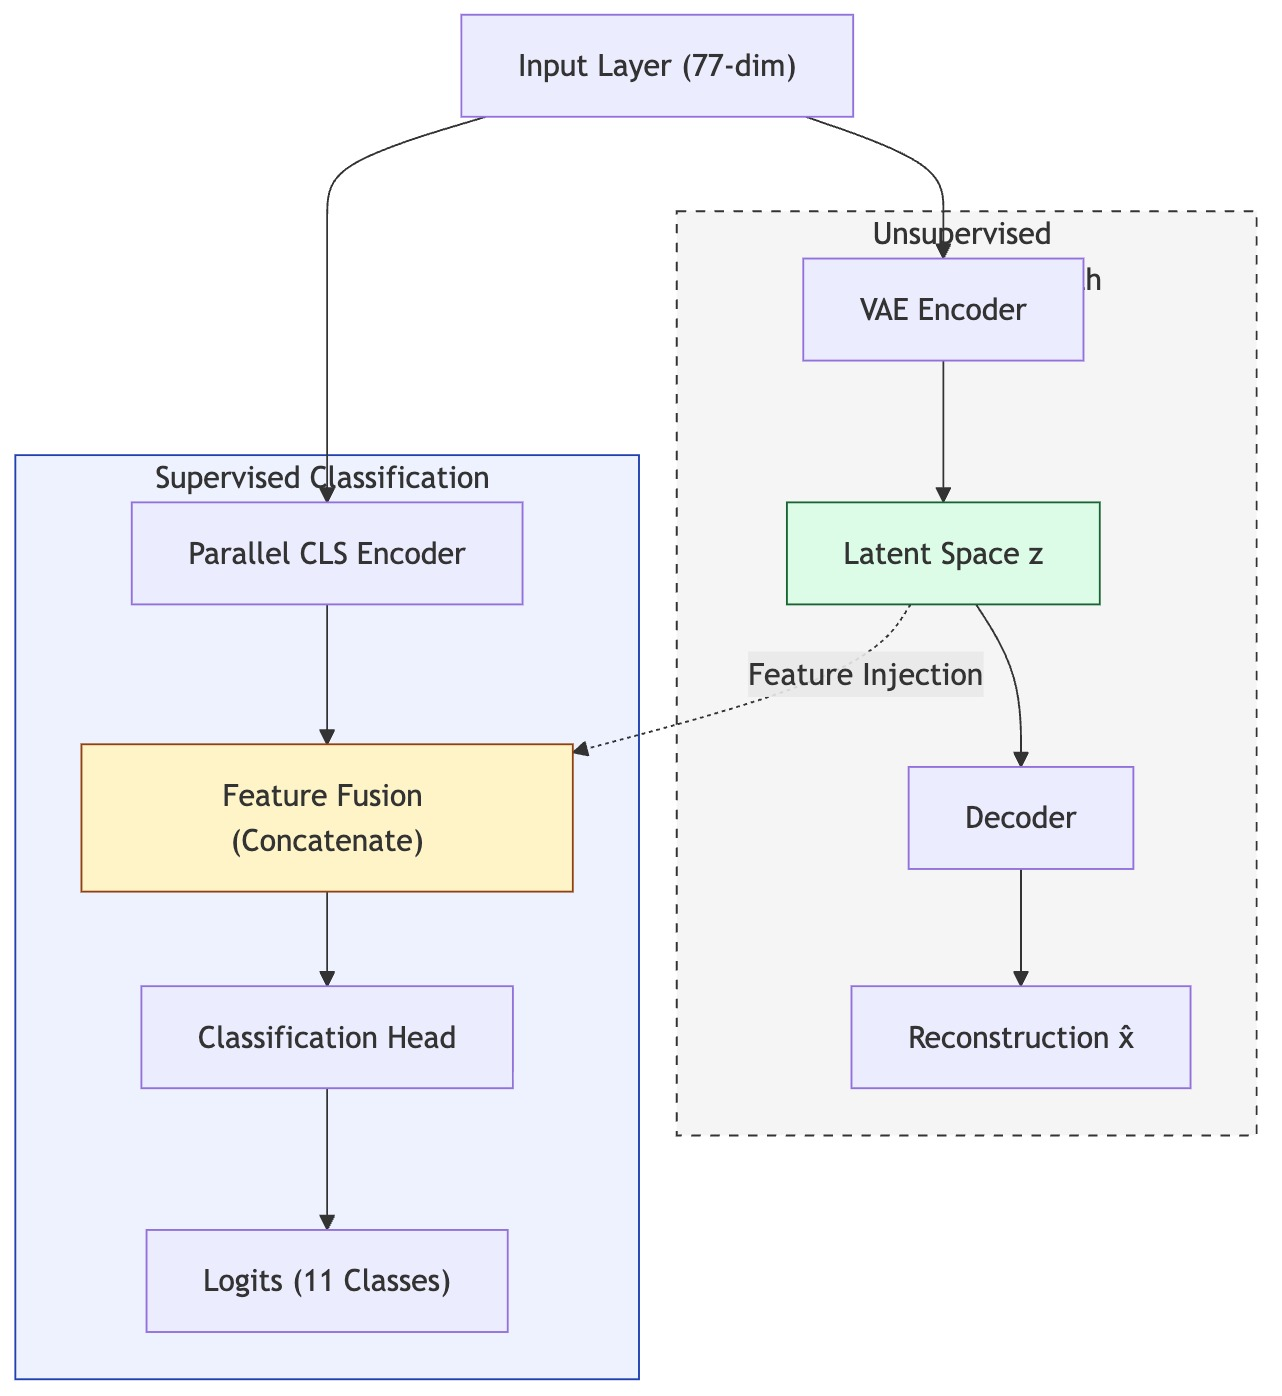


In [35]:
# ============================================================
# CELL A4: Training Loop — HybridVAE
# ============================================================
history_a     = {'train_loss': [], 'val_loss': [], 'val_f1': [],
                 'train_recon': [], 'train_cls': [], 'train_kl': []}
best_val_f1_a = 0.0
best_state_a  = None

def run_epoch_a(loader, train=True):
    model_a.train(train)
    tot = r_s = f_s = k_s = 0.0
    preds, trues = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b, _ in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            x_hat, logits, mu, lv, z = model_a(X_b)
            loss, lr_, lf_, lk_ = combined_loss_a(X_b, x_hat, logits, y_b, mu, lv, z)
            if train:
                opt_a.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model_a.parameters(), max_norm=1.0)
                opt_a.step()
            tot += loss.item(); r_s += lr_; f_s += lf_; k_s += lk_
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(y_b.cpu().numpy())
    n  = len(loader)
    f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return tot/n, r_s/n, f_s/n, k_s/n, f1

print('Starting training (9-class)...\n')
for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_r, tr_f, tr_k, _ = run_epoch_a(train_loader_a, train=True)
    va_loss, va_r, va_f, va_k, va_f1 = run_epoch_a(val_loader_a, train=False)
    sched_a.step()

    history_a['train_loss'].append(tr_loss);  history_a['val_loss'].append(va_loss)
    history_a['val_f1'].append(va_f1);        history_a['train_recon'].append(tr_r)
    history_a['train_cls'].append(tr_f);      history_a['train_kl'].append(tr_k)

    if va_f1 > best_val_f1_a:
        best_val_f1_a = va_f1
        best_state_a  = copy.deepcopy(model_a.state_dict())
        marker = ' ← best'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        lr = opt_a.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{CONFIG["epochs"]} | '
              f'Train {tr_loss:.4f} (R:{tr_r:.4f} C:{tr_f:.4f} KL:{tr_k:.4f}) | '
              f'Val {va_loss:.4f} | F1 {va_f1:.4f} | LR {lr:.6f}{marker}')

model_a.load_state_dict(best_state_a)
torch.save(best_state_a, './model_a_9class.pt')
print(f'\nBest model loaded & saved — Val Macro-F1: {best_val_f1_a:.4f}')


Starting training (9-class)...

Epoch   1/75 | Train 0.1759 (R:0.2807 C:0.1805 KL:0.0477) | Val 0.4689 | F1 0.6222 | LR 0.001000 ← best
Epoch   5/75 | Train 0.1471 (R:0.1944 C:0.1600 KL:0.0832) | Val 0.2411 | F1 0.7401 | LR 0.000989
Epoch  10/75 | Train 0.1421 (R:0.1795 C:0.1566 KL:0.0892) | Val 0.2185 | F1 0.7894 | LR 0.000957
Epoch  15/75 | Train 0.1407 (R:0.1739 C:0.1560 KL:0.0915) | Val 0.2049 | F1 0.7919 | LR 0.000905
Epoch  20/75 | Train 0.1395 (R:0.1710 C:0.1549 KL:0.0925) | Val 0.2057 | F1 0.8382 | LR 0.000835 ← best
Epoch  25/75 | Train 0.1389 (R:0.1691 C:0.1546 KL:0.0930) | Val 0.1918 | F1 0.8582 | LR 0.000750 ← best
Epoch  30/75 | Train 0.1382 (R:0.1673 C:0.1539 KL:0.0933) | Val 0.1887 | F1 0.7888 | LR 0.000655
Epoch  35/75 | Train 0.1379 (R:0.1663 C:0.1538 KL:0.0935) | Val 0.1948 | F1 0.8501 | LR 0.000553
Epoch  40/75 | Train 0.1373 (R:0.1648 C:0.1534 KL:0.0935) | Val 0.1901 | F1 0.8835 | LR 0.000448 ← best
Epoch  45/75 | Train 0.1369 (R:0.1639 C:0.1531 KL:0.0936) | Val 0.1

### Cell A5 — Training Curves

Plots three diagnostic panels across training epochs:

1. **Combined loss** — train vs validation. Both curves should converge and stay close (no large gap = no severe overfitting)
2. **Loss components** — reconstruction, classification, and KL divergence tracked separately. A rising KL term during early epochs is expected and healthy — it means the latent space is being regularised
3. **Validation Macro F1** — the primary checkpoint metric. Should rise consistently and plateau near the final epochs

The plot is saved to `train_curves_hybridvae.png`.


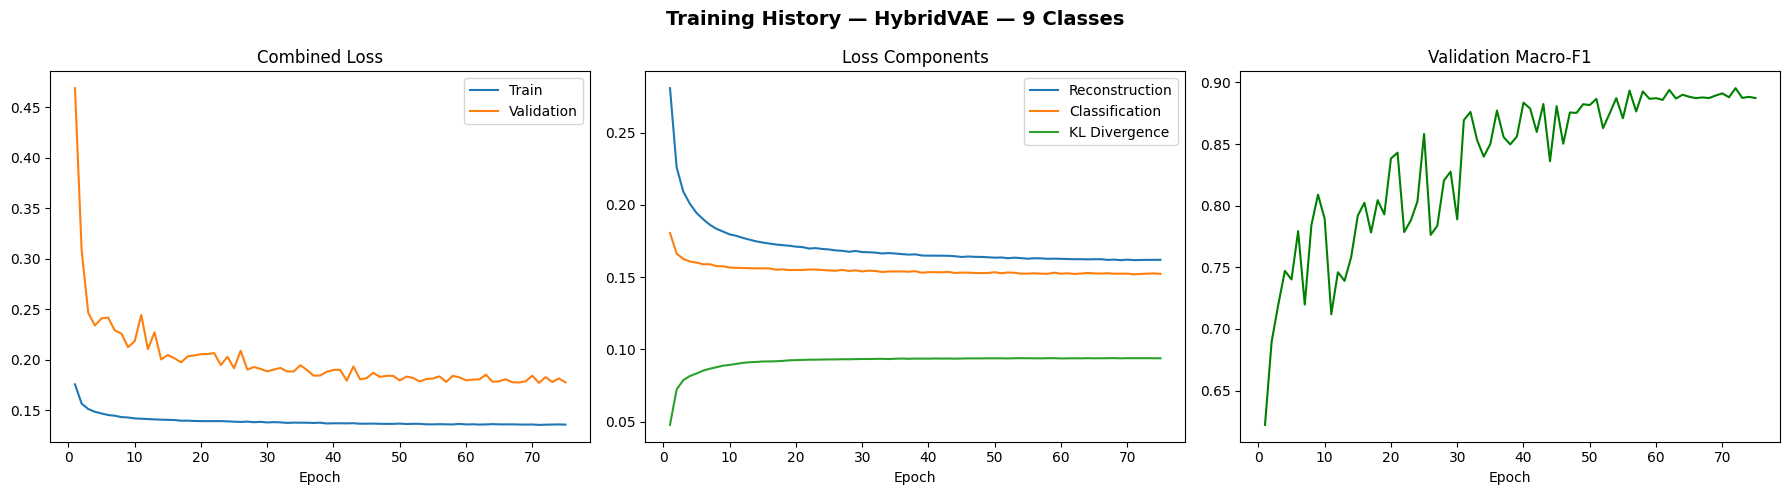

In [36]:
# ============================================================
# CELL A5: Training Curves — HybridVAE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — HybridVAE — 9 Classes', fontsize=14, fontweight='bold')
ep = range(1, len(history_a['train_loss']) + 1)

axes[0].plot(ep, history_a['train_loss'], label='Train')
axes[0].plot(ep, history_a['val_loss'],   label='Validation')
axes[0].set_title('Combined Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, history_a['train_recon'], label='Reconstruction')
axes[1].plot(ep, history_a['train_cls'],   label='Classification')
axes[1].plot(ep, history_a['train_kl'],    label='KL Divergence')
axes[1].set_title('Loss Components'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(ep, history_a['val_f1'], color='green')
axes[2].set_title('Validation Macro-F1'); axes[2].set_xlabel('Epoch')

plt.tight_layout(); plt.savefig('train_curves_hybridvae.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell A6 — Test Evaluation and Confusion Matrix

Runs `model_a` on the held-out test set and reports per-class and aggregate metrics.

**Primary metric: Macro F1** — weights all 9 classes equally regardless of size. This is the correct metric for an imbalanced multi-class IDS because a model that always predicts BENIGN would score ~0.11 Macro F1, not 80%.

Two confusion matrix views are plotted:
- **Count matrix** — shows absolute prediction volumes (dominated by BENIGN)
- **Normalised matrix** — shows per-class recall rates (each row sums to 1.0); this is more informative for imbalanced data

Saved to `confusion_hybridvae.png`.


===== PART A — HYBRIDVAE TEST RESULTS =====
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99    314473
      Botnet       0.57      0.63      0.60       293
  BruteForce       0.99      0.96      0.98      1373
        DDoS       1.00      0.99      0.99     19202
         DoS       1.00      0.90      0.95     29062
  Heartbleed       1.00      1.00      1.00         2
Infiltration       0.40      0.40      0.40         5
    PortScan       0.99      0.99      0.99     13623
  Web Attack       0.92      0.94      0.93       322

    accuracy                           0.99    378355
   macro avg       0.87      0.87      0.87    378355
weighted avg       0.99      0.99      0.99    378355

Macro F1:    0.8702
Weighted F1: 0.9899


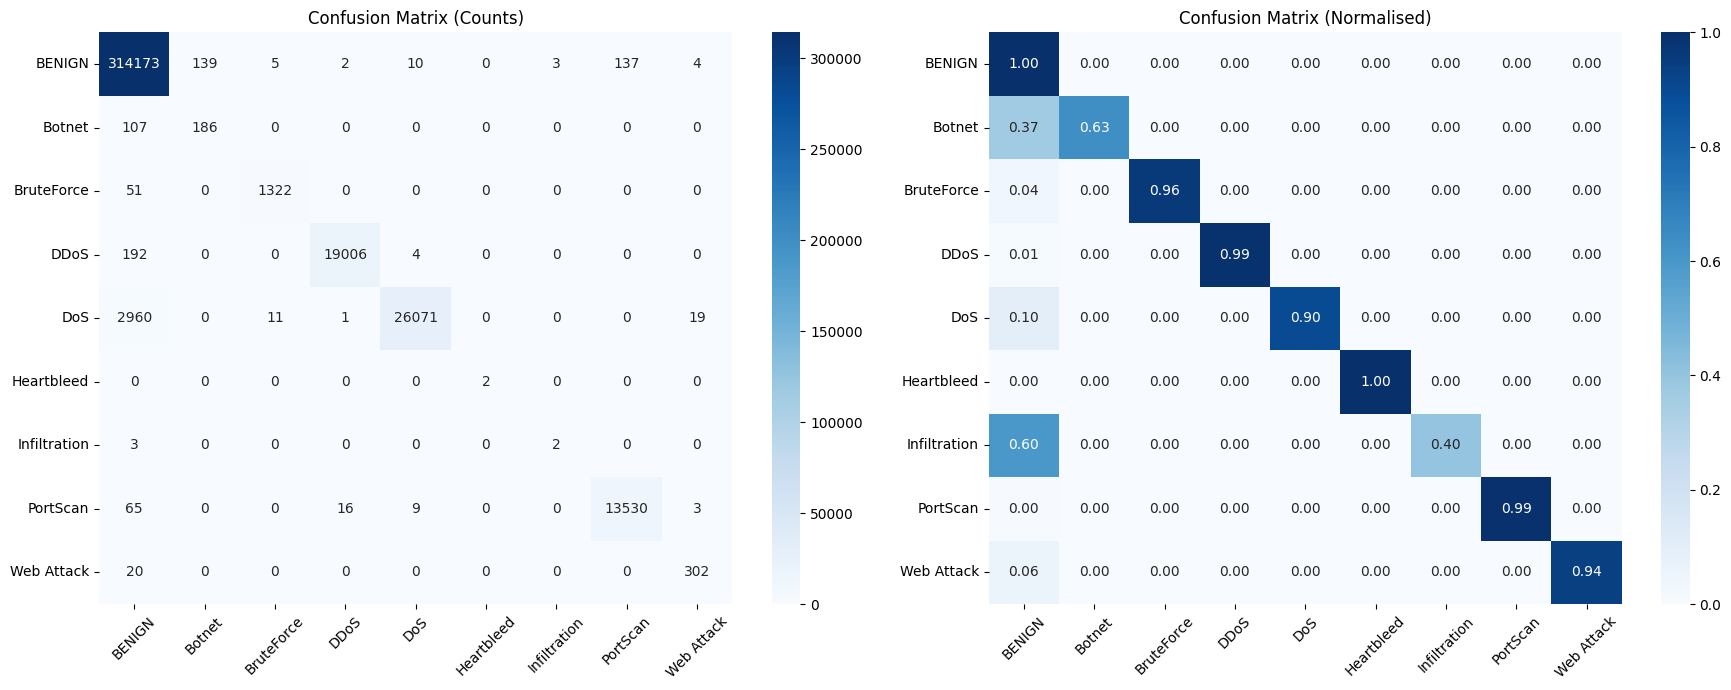

In [37]:
# ============================================================
# CELL A6: Test Evaluation & Confusion Matrix — HybridVAE Matrix — 9 Classes
# ============================================================
model_a.eval()
test_preds_a, test_labels_a = [], []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, logits, _, _, _ = model_a(X_b.to(DEVICE))
        test_preds_a.extend(logits.argmax(1).cpu().numpy())
        test_labels_a.extend(y_b.numpy())

test_preds_a  = np.array(test_preds_a)
test_labels_a = np.array(test_labels_a)

print('===== PART A — HYBRIDVAE TEST RESULTS =====')
print(classification_report(
    test_labels_a, test_preds_a,
    target_names=new_class_names,
    zero_division=0
))
print(f'Macro F1:    {f1_score(test_labels_a, test_preds_a, average="macro",    zero_division=0):.4f}')
print(f'Weighted F1: {f1_score(test_labels_a, test_preds_a, average="weighted", zero_division=0):.4f}')

# Confusion matrix
cm_a = confusion_matrix(test_labels_a, test_preds_a)
cm_a_norm = cm_a.astype(float) / cm_a.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)'); axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_a_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)'); axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.savefig('confusion_hybridvae.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell A7 — Save / Reload `model_a` (Optional)

Convenience cell for saving and reloading `model_a` from disk without retraining.

**Usage:** Uncomment the reload block if you want to restore `model_a` from `./model_a_9class.pt` in a fresh kernel session. The architecture parameters passed to `HybridVAE(...)` must exactly match those used during training (i.e. the same `CONFIG` values).


In [38]:
# ============================================================
# CELL A7: Save / Reload model_a (optional convenience cell)
# ============================================================
# --- Save (already done at end of B4, but re-run if needed) ---
# torch.save(model_a.state_dict(), './model_a_9class.pt')

#--- Reload without retraining ---

# model_a = HybridVAE(
#     input_dim=WHITENED_DIM, latent_dim=CONFIG['latent_dim'],
#     encoder_dims=CONFIG['encoder_dims'], decoder_dims=CONFIG['decoder_dims'],
#     num_classes=NEW_NUM_CLASSES, dropout=CONFIG['dropout_rate'],
#     variational=CONFIG['use_variational']
# ).to(DEVICE)
# model_a.load_state_dict(torch.load('./model_a_9class.pt', map_location=DEVICE))
# model_a.eval()
# print('model_a loaded.')
print('model_a saved at ./model_a_9class.pt')


model_a saved at ./model_a_9class.pt


---

## Part B — XGBoost Classifier (9 Classes)

Trains a standalone XGBoost gradient-boosted tree classifier on the same whitened feature matrix used by the HybridVAE in Part A, with the same 9-class labels.

**Why XGBoost as a separate baseline?**
- XGBoost is the standard strong baseline for tabular/structured data
- CICIDS2017 is a pre-extracted flow-feature dataset with no sequential or relational structure — exactly the scenario where tree ensembles excel
- Comparison against XGBoost quantifies the cost (or benefit) of using a neural network with anomaly detection capability

**What this section produces:** `xgb_raw` (Macro F1 ≈ 0.91, **no anomaly detection capability**)

**Dependency:** Part A cells must be run first (for `y_tr2`, `y_va2`, `y_te2`, `new_class_names`, and the DataLoader infrastructure).


### Cell B1 — XGBoost Training and Evaluation

Trains XGBoost with 500 estimators, max depth 8, and early stopping after 30 rounds without improvement on validation log-loss.

**Class weighting:** Full inverse-frequency (not sqrt-dampened as in the HybridVAE DataLoader). XGBoost handles class imbalance through the `sample_weight` parameter directly, and gradient boosting is more robust to extreme weights than neural network optimisers.

**Outputs:**
- Per-class classification report with precision, recall, and F1
- Count and normalised confusion matrices saved to `confusion_xgboost.png`
- `xgb_raw_macro`: test Macro F1 used in the baseline comparison table


Class weights (inverse-freq):
  [0] BENIGN         : n=1,467,538  weight=1.000
  [1] Botnet         : n=  4,101  weight=48.322
  [2] BruteForce     : n=  8,000  weight=24.771
  [3] DDoS           : n= 89,611  weight=2.211
  [4] DoS            : n=135,624  weight=1.461
  [5] Heartbleed     : n=  3,000  weight=66.057
  [6] Infiltration   : n=  3,000  weight=66.057
  [7] PortScan       : n= 63,573  weight=3.117
  [8] Web Attack     : n=  9,087  weight=21.808

Training XGBoost on raw whitened features...
[0]	validation_0-mlogloss:0.88799
[50]	validation_0-mlogloss:0.02473
[100]	validation_0-mlogloss:0.01109
[150]	validation_0-mlogloss:0.00816
[200]	validation_0-mlogloss:0.00702
[250]	validation_0-mlogloss:0.00653
[300]	validation_0-mlogloss:0.00627
[350]	validation_0-mlogloss:0.00611
[400]	validation_0-mlogloss:0.00604
[450]	validation_0-mlogloss:0.00599
[499]	validation_0-mlogloss:0.00598

Best iteration: 495

===== XGBoost (Raw Features) — TEST RESULTS =====
              precision    re

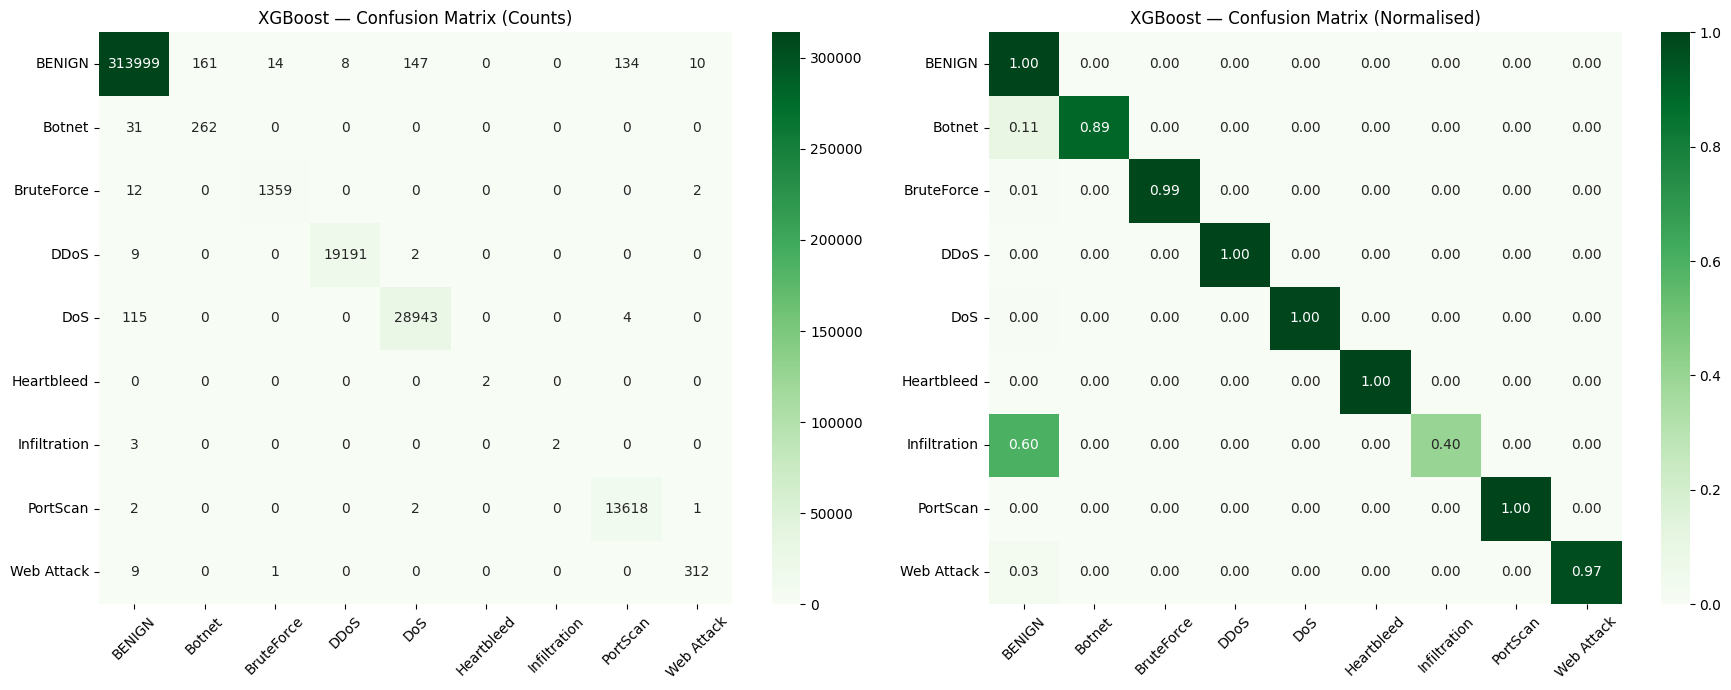

In [39]:
# ============================================================
# CELL B1: XGBoost Classifier — 9 Classes on Raw Whitened Features — 9 Classes
#          Same input as MLP classifier (X_train_w / X_val_w / X_test_w)
#          Uses 9-class labels from Part B (y_tr2, y_va2, y_te2)
# ============================================================
!pip install xgboost --quiet
import xgboost as xgb
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# ── Step 1: Class weights (full inverse-frequency, no sqrt dampening) ────────
cnt_raw = Counter(y_tr2)

sample_weights_raw = np.array([
    1.0 if c == BENIGN_A
    else len(y_tr2) / (NEW_NUM_CLASSES * cnt_raw[c])
    for c in y_tr2
], dtype=np.float32)

print('Class weights (inverse-freq):')
for c in range(NEW_NUM_CLASSES):
    w = len(y_tr2) / (NEW_NUM_CLASSES * cnt_raw[c]) if c != BENIGN_A else 1.0
    print(f'  [{c}] {new_class_names[c]:<15}: n={cnt_raw[c]:>7,}  weight={w:.3f}')

# ── Step 2: Train XGBoost ─────────────────────────────────────────────────────
print('\nTraining XGBoost on raw whitened features...')

xgb_raw = xgb.XGBClassifier(
    n_estimators      = 500,
    max_depth         = 8,
    learning_rate     = 0.1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 1,
    gamma             = 0.0,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'multi:softprob',
    num_class         = NEW_NUM_CLASSES,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    tree_method       = 'hist',
    random_state      = 42,
    n_jobs            = -1,
    early_stopping_rounds = 30,
)

xgb_raw.fit(
    X_train_w, y_tr2,
    sample_weight = sample_weights_raw,
    eval_set      = [(X_val_w, y_va2)],
    verbose       = 50,
)

print(f'\nBest iteration: {xgb_raw.best_iteration}')

# ── Step 3: Evaluate ──────────────────────────────────────────────────────────
val_preds_raw  = xgb_raw.predict(X_val_w)
test_preds_raw = xgb_raw.predict(X_test_w)

val_f1_raw  = f1_score(y_va2, val_preds_raw,  average='macro', zero_division=0)
test_f1_raw = f1_score(y_te2, test_preds_raw, average='macro', zero_division=0)

print('\n===== XGBoost (Raw Features) — TEST RESULTS =====')
print(classification_report(y_te2, test_preds_raw,
                             target_names=new_class_names, zero_division=0))
print(f'Val  Macro F1 : {val_f1_raw:.4f}')
print(f'Test Macro F1 : {test_f1_raw:.4f}')

xgb_raw_macro = test_f1_raw
print('\n' + '='*50)
print(f'  {"Model":<30} {"Macro F1":>10}')
print('  ' + '-'*42)
print(f'  {"XGBoost (Part B)":<30} {xgb_raw_macro:>10.4f}')
print('='*50)

# ── Step 5: Confusion matrix ──────────────────────────────────────────────────
cm_raw      = confusion_matrix(y_te2, test_preds_raw)
cm_raw_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Greens',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('XGBoost — Confusion Matrix (Counts)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_raw_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('XGBoost — Confusion Matrix (Normalised)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell B2 — Per-Class Inference Test: HybridVAE vs XGBoost

Runs a single test sample from each of the 9 classes through both `model_a` and `xgb_raw` side by side, printing the predicted class and confidence score for each.

This is a quick sanity check to confirm both models are producing sensible predictions across all classes, including the rare ones (Heartbleed, Infiltration, Botnet).

> If `xgb_clf` (latent-space XGBoost, trained in a separate optional cell) is defined in the session, it is also shown as a third column.


In [40]:
# ============================================================
# CELL B2: Per-Class Inference — HybridVAE vs XGBoost (+ optional latent XGBoost)
#          Tests one sample from every class. If `xgb_clf` exists (latent features), it is shown.
# ============================================================
import numpy as np
import torch

print('=' * 65)
print('  PER-CLASS INFERENCE TEST — 9 Classes')
print('  Columns: True | HybridVAE | XGBoost (raw) [| XGBoost latent if trained]')
print('=' * 65)

for cls_idx, cls_name in enumerate(new_class_names):
    match = np.where(y_te2 == cls_idx)[0]
    if len(match) == 0:
        print(f'\n[{cls_idx}] {cls_name}: no test samples — skipped')
        continue

    sample_idx = match[0]
    x_raw = X_test_w[sample_idx : sample_idx + 1].astype(np.float32)
    x_tensor = torch.from_numpy(x_raw).to(DEVICE)

    print(f'\n[{cls_idx}] True class : {cls_name}')
    print('-' * 65)

    model_a.eval()
    with torch.no_grad():
        _, logits, _, _, _ = model_a(x_tensor)
        probs_mlp = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_mlp = new_class_names[probs_mlp.argmax()]
    conf_mlp = probs_mlp.max()
    status_mlp = '✓' if pred_mlp == cls_name else '✗'
    print(f'  HybridVAE     : {status_mlp}  {pred_mlp:<15}  conf={conf_mlp:.2%}')

    probs_xgb = xgb_raw.predict_proba(x_raw)[0]
    pred_xgb = new_class_names[probs_xgb.argmax()]
    conf_xgb = probs_xgb.max()
    status_xgb = '✓' if pred_xgb == cls_name else '✗'
    print(f'  XGBoost (raw) : {status_xgb}  {pred_xgb:<15}  conf={conf_xgb:.2%}')

    try:
        with torch.no_grad():
            _, _, mu, _, _ = model_a(x_tensor)
            cls_feat = model_a.cls_encode(x_tensor)
            z_vec = torch.cat([mu, cls_feat], dim=1).cpu().numpy()
        probs_lat = xgb_clf.predict_proba(z_vec)[0]
        pred_lat = new_class_names[probs_lat.argmax()]
        conf_lat = probs_lat.max()
        status_lat = '✓' if pred_lat == cls_name else '✗'
        print(f'  XGBoost (latent): {status_lat}  {pred_lat:<15}  conf={conf_lat:.2%}')
    except NameError:
        pass

print('\n' + '=' * 65)
print('  ✓ = correct prediction   ✗ = wrong prediction')
print('=' * 65)



  PER-CLASS INFERENCE TEST — 9 Classes
  Columns: True | HybridVAE | XGBoost (raw) [| XGBoost latent if trained]

[0] True class : BENIGN
-----------------------------------------------------------------
  HybridVAE     : ✓  BENIGN           conf=88.35%
  XGBoost (raw) : ✓  BENIGN           conf=99.99%

[1] True class : Botnet
-----------------------------------------------------------------
  HybridVAE     : ✓  Botnet           conf=99.66%
  XGBoost (raw) : ✓  Botnet           conf=100.00%

[2] True class : BruteForce
-----------------------------------------------------------------
  HybridVAE     : ✓  BruteForce       conf=99.91%
  XGBoost (raw) : ✓  BruteForce       conf=100.00%

[3] True class : DDoS
-----------------------------------------------------------------
  HybridVAE     : ✓  DDoS             conf=99.03%
  XGBoost (raw) : ✓  DDoS             conf=100.00%

[4] True class : DoS
-----------------------------------------------------------------
  HybridVAE     : ✗  BENIGN   

---

## Baseline Comparison — Vanilla AE vs HybridVAE vs XGBoost

Consolidates results from Part A0, Part A, and Part B into a single comparison table.

**Re-run this cell** if any upstream model is retrained.

**What each model can and cannot do:**

| Model | Multi-class attack typing | Open-set anomaly detection | Deployable on edge |
|---|---|---|---|
| Vanilla AE | ✗ (reconstruction score only) | ✓ (BENIGN reconstruction threshold) | ✓ (smallest model) |
| HybridVAE | ✓ | ✓ (dual-path) | ✓ (after compression) |
| XGBoost | ✓ | ✗ (always predicts a known class) | ✗ (large pickle) |

> XGBoost Macro F1 is typically higher than HybridVAE on this tabular benchmark — this is expected. The HybridVAE's value lies in its generative anomaly detection path, not in raw closed-set classification accuracy.


In [41]:
# ============================================================
# CELL: Three-way baseline comparison (Vanilla AE vs HybridVAE vs XGBoost)
# ============================================================
from sklearn.metrics import roc_auc_score, f1_score

# --- Multi-class Macro F1 (Hybrid + XGBoost only) ---
hybrid_f1 = f1_score(test_labels_a, test_preds_a, average='macro', zero_division=0)
xgb_f1 = f1_score(y_te2, xgb_raw.predict(X_test_w), average='macro', zero_division=0)
hybrid_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)

# --- Anomaly AUROC: benign=0, attack=1, score = L1 recon error ---
y_bin = (y_te2 != BENIGN_A).astype(np.int32)
X_t = torch.from_numpy(X_test_w.astype(np.float32))

model_a.eval()
model_vanilla.eval()
errs_h, errs_v = [], []
with torch.no_grad():
    for i in range(0, len(X_test_w), CONFIG['batch_size'] * 2):
        batch = X_t[i : i + CONFIG['batch_size'] * 2].to(DEVICE)
        xh_m, _, _, _, _ = model_a(batch)
        xh_v, _ = model_vanilla(batch)
        errs_h.append(F.l1_loss(xh_m, batch, reduction='none').mean(dim=1).cpu().numpy())
        errs_v.append(F.l1_loss(xh_v, batch, reduction='none').mean(dim=1).cpu().numpy())
err_hybrid = np.concatenate(errs_h)
err_vanilla = np.concatenate(errs_v)
auroc_hybrid = roc_auc_score(y_bin, err_hybrid)
# vanilla_ae_test_auroc should match; recompute for safety
auroc_vanilla = roc_auc_score(y_bin, err_vanilla)

print('\n' + '=' * 72)
print('  BASELINE COMPARISON — 9-class test set')
print('=' * 72)
print(f'  {"Model":<22} {"Params":>12} {"Macro F1":>10} {"Anom. AUROC":>12}')
print('  ' + '-' * 60)
print(f'  {"Vanilla AE":<22} {vanilla_ae_params:>12,} {"—":>10} {auroc_vanilla:>12.4f}')
print(f'  {"HybridVAE":<22} {hybrid_params:>12,} {hybrid_f1:>10.4f} {auroc_hybrid:>12.4f}')
print(f'  {"XGBoost (raw)":<22} {"(trees)":>12} {xgb_f1:>10.4f} {"N/A*":>12}')
print('  ' + '-' * 60)

print('\n  Capabilities:')
print('    • Vanilla AE: anomaly scoring only on this pipeline (no attack class name).')
print('    • HybridVAE:   multi-class labels + recon-based anomaly.')
print('    • XGBoost:     strongest closed-set Macro F1 here; no generative anomaly channel.')
print('=' * 72)




  BASELINE COMPARISON — 9-class test set
  Model                        Params   Macro F1  Anom. AUROC
  ------------------------------------------------------------
  Vanilla AE                  495,501          —       0.7587
  HybridVAE                   749,270     0.8702       0.8740
  XGBoost (raw)               (trees)     0.9162         N/A*
  ------------------------------------------------------------

  Capabilities:
    • Vanilla AE: anomaly scoring only on this pipeline (no attack class name).
    • HybridVAE:   multi-class labels + recon-based anomaly.
    • XGBoost:     strongest closed-set Macro F1 here; no generative anomaly channel.


---

## Part C — Knowledge Distillation

Compresses a large teacher model into a **compact student HybridVAE (~221K params, 3.38× smaller)** that retains both classification accuracy and the VAE anomaly detection capability.

#### Why distillation instead of training small from scratch?

A small model trained on hard one-hot labels learns nothing about class relationships. The teacher's soft probability outputs (e.g. "72% DoS, 14% DDoS, 8% BENIGN") encode which classes are *similar* — this inter-class geometry transfers to the student via KL divergence at temperature $T=4$.

**Temperature scaling:** At $T=4$, the teacher's probabilities are softened so that small probabilities (class similarities) become visible. Without temperature, near-zero probabilities are indistinguishable from each other.

$$p_i^{(T)} = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

#### Student Architecture (all dimensions halved vs teacher)

| Component | Teacher | Student |
|---|---|---|
| VAE encoder | 512 → 256 → 128 | 256 → 128 → 64 |
| Latent dim | 64 | 32 |
| CLS encoder output | 128 | 64 |
| Classifier input | 192 | 96 |
| Total params | ~749K | ~221K |

#### Two distillation experiments

- **C-i:** HybridVAE teacher → student (compression of the neural model)
- **C-ii:** XGBoost teacher → student (transfers stronger tabular classification into a deployable VAE)


---

### Distillation Loss Function — Both Experiments (C-i and C-ii)

Both distillation experiments use the **same composite loss structure**. The student is trained with the standard HybridVAE objective, but the classification term is replaced with a weighted combination of distillation loss and supervised focal loss.

**Full composite loss:**

$$L_{\text{total}} = 0.20 \cdot L_{\text{recon}} + 0.65 \cdot L_{\text{cls}} + 0.05 \cdot L_{\text{KL}}$$

Where the classification term decomposes as:

$$L_{\text{cls}} = 0.70 \cdot L_{\text{distill}} + 0.30 \cdot L_{\text{focal\_hard}}$$

And the distillation term is the KL divergence between teacher and student softmax outputs at temperature $T = 4$, scaled by $T^2$:

$$L_{\text{distill}} = \text{KL}\!\left(\log\text{softmax}\!\left(\frac{z_s}{T}\right) \,\Big\|\, \text{softmax}\!\left(\frac{z_t}{T}\right)\right) \times T^2$$

```python
soft_teacher = F.softmax(teacher_logits / T, dim=1)   # detached — no gradient
soft_student  = F.log_softmax(student_logits / T, dim=1)
L_distill     = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T ** 2)
```

**Why $T^2$ scaling?** Temperature softening reduces the magnitude of the gradients flowing through the distillation loss. Multiplying by $T^2$ compensates for this reduction, ensuring the distillation signal has comparable magnitude to the hard-label focal loss term [Hinton et al., 2015].

**Why $T = 4$?** A higher temperature spreads probability mass across all classes, making the inter-class similarity structure visible to the student. For example, a teacher prediction of 60% DoS / 35% DDoS / 5% other carries substantially more information than a one-hot "DoS" label — it tells the student that DoS and DDoS share underlying features and are confusable classes.

---

### How the Loss Bridges the Architectural Mismatch (C-i vs C-ii)

The distillation loss operates **entirely in probability space** — not in weight space or feature space. This is the mechanism that accommodates radically different teacher architectures:

| | C-i (HybridVAE → Student) | C-ii (XGBoost → Student) |
|---|---|---|
| **Teacher type** | 749K-param neural network | 18 MB ensemble of decision trees |
| **What student sees** | 9-class softmax vector | 9-class softmax vector |
| **Internal representations shared?** | No | No |
| **Weights shared?** | No | No |

Because both teacher and student output the same 9-class probability vector, the structural difference between an XGBoost ensemble and a neural network — or between a 749K-parameter teacher and a 221K-parameter student — is **completely irrelevant** to the distillation objective. The student only ever observes the teacher's output probabilities, never its internal representations.

The reconstruction loss $L_{\text{recon}}$ (computed on BENIGN samples only) and the KL divergence $L_{\text{KL}}$ are computed **independently of the teacher** and preserve the student's VAE anomaly detection capability. This is why the student in C-ii inherits anomaly detection that the XGBoost teacher never possessed — the VAE pathway is trained from data, not distilled from the teacher.


### Part C-i — Distillation: HybridVAE Teacher → Student HybridVAE

**Teacher:** `model_a` (HybridVAE, ~749K params, Macro F1 ≈ 0.87)  
**Student:** `student_vae` (~221K params)

The teacher is **frozen** during distillation — its weights are not updated. It is used only to generate soft probability vectors for each training batch.

**Expected result:** Student Macro F1 ≈ teacher F1 while the model shrinks 3.38×. The student inherits the teacher's class relationships via soft labels and retains the reconstruction-based anomaly detection path via the preserved VAE decoder.

**Dependency:** Part A (`model_a`) must be trained before running this section.


### Cell C1-i — VAE Teacher Distillation Training

**Distillation loss:**

$$L_{\text{distill}} = \alpha \cdot T^2 \cdot D_{\text{KL}}(\sigma(s/T) \| \sigma(t/T)) + (1-\alpha) \cdot L_{\text{focal}}$$

Where $s$ and $t$ are student and teacher logits, $T=4$ is the temperature, and $\alpha=0.7$ means 70% of the gradient comes from soft labels and 30% from hard focal loss on true labels.

The full student objective also includes:
- **Reconstruction loss** (BENIGN only, L1) — preserves the anomaly detection path
- **KL divergence** — keeps the student's latent space regularised

Best student checkpoint saved to `student_vae_distilled.pt`.


Teacher parameters :    749,270
Student parameters :    221,462
Compression ratio  : 3.38x smaller

Distillation training 50 epochs
Temperature T=4.0  |  Alpha=0.7  (70% soft labels, 30% focal)

  Ep   1/50 | Train loss: 0.1002 | Val Macro-F1: 0.5892 | LR: 0.000999 <- best
  Ep   5/50 | Train loss: 0.0631 | Val Macro-F1: 0.7888 | LR: 0.000976 <- best
  Ep  10/50 | Train loss: 0.0573 | Val Macro-F1: 0.7762 | LR: 0.000905
  Ep  15/50 | Train loss: 0.0553 | Val Macro-F1: 0.7883 | LR: 0.000794
  Ep  20/50 | Train loss: 0.0544 | Val Macro-F1: 0.8822 | LR: 0.000655 <- best
  Ep  25/50 | Train loss: 0.0538 | Val Macro-F1: 0.8791 | LR: 0.000500
  Ep  30/50 | Train loss: 0.0531 | Val Macro-F1: 0.7992 | LR: 0.000346
  Ep  35/50 | Train loss: 0.0527 | Val Macro-F1: 0.8888 | LR: 0.000207 <- best
  Ep  40/50 | Train loss: 0.0524 | Val Macro-F1: 0.8997 | LR: 0.000096 <- best
  Ep  45/50 | Train loss: 0.0525 | Val Macro-F1: 0.8904 | LR: 0.000025
  Ep  50/50 | Train loss: 0.0523 | Val Macro-F1: 0.8901

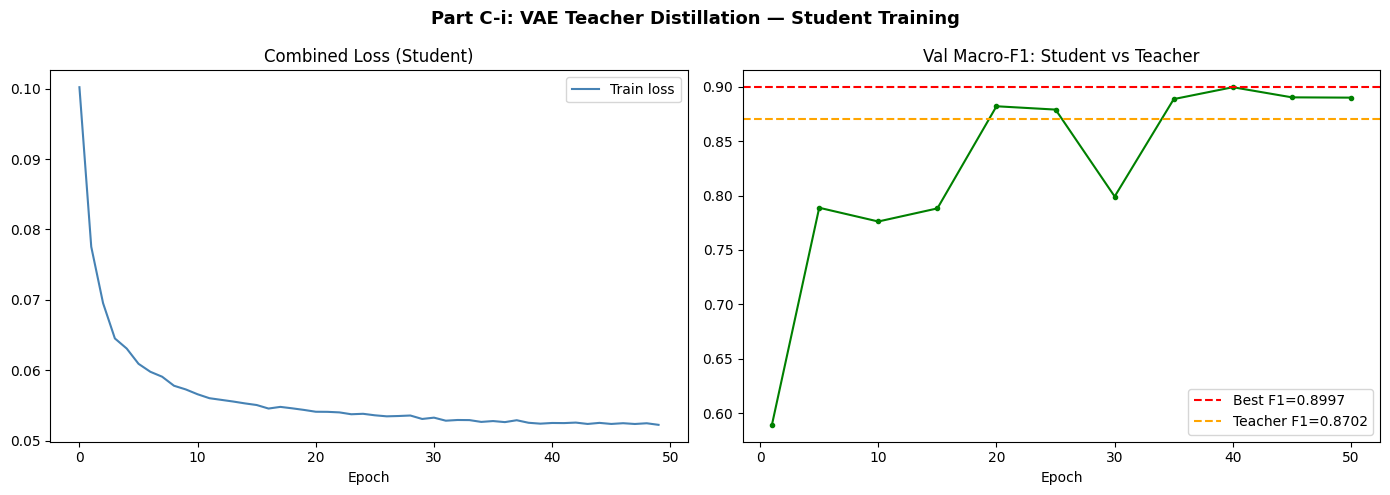

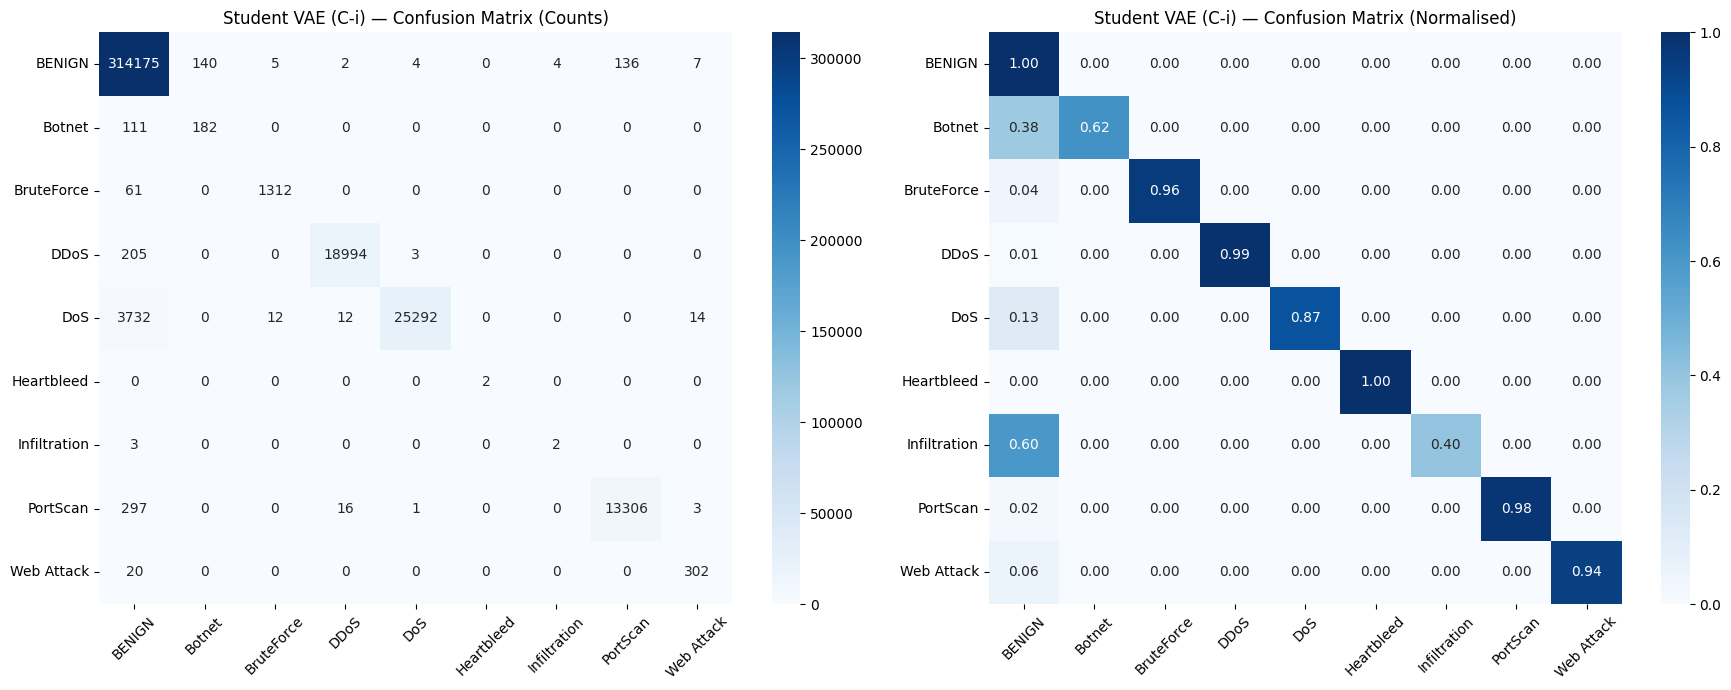


  PER-CLASS INFERENCE: Teacher vs Student
  Class                                 Teacher                Student    Match
  ------------------------------------------------------------------------------
  BENIGN                  VBENIGN                 VBENIGN                    agree
  Botnet                  VBotnet                 VBotnet                    agree
  BruteForce              VBruteForce             VBruteForce                agree
  DDoS                    VDDoS                   VDDoS                      agree
  DoS                     XBENIGN                 XBENIGN                    agree
  Heartbleed              VHeartbleed             VHeartbleed                agree
  Infiltration            XBENIGN                 XBENIGN                    agree
  PortScan                VPortScan               VPortScan                  agree
  Web Attack              XBENIGN                 XBENIGN                    agree



In [42]:
# ==============================================================================
# CELL C1-i: VAE Teacher Distillation: Stage 1 — Knowledge Distillation
#          Student HybridVAE (~220K params) trained from Teacher model_a (~749K)
#          Temperature T=4  |  Distillation weight alpha=0.7
# ==============================================================================
# Requires: model_a trained (Part A), train_loader_a / val_loader_a / test_loader_a,
#           combined_loss_b signature, BENIGN_A, NEW_NUM_CLASSES, new_class_names,
#           focal_fn_a, cw9, DEVICE, CONFIG

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

# ------------------------------------------------------------------------------
# Student Architecture
# Teacher dims:  encoder=[512,256,128]  latent=64  cls=[256,256,128]
# Student dims:  encoder=[256,128, 64]  latent=32  cls=[128,128, 64]
# Classifier input: latent+cls_out = 32+64 = 96  (teacher: 64+128=192)
# ------------------------------------------------------------------------------

STUDENT_ENCODER_DIMS = [256, 128, 64]
STUDENT_DECODER_DIMS = [64, 128, 256]
STUDENT_LATENT_DIM   = 32
STUDENT_CLS_OUT_DIM  = 64    # cls_encoder final output
STUDENT_DROPOUT      = CONFIG['dropout_rate']

class StudentHybridVAE(nn.Module):
    """
    Compressed HybridVAE for knowledge distillation.

    Structurally identical to HybridVAE but with all hidden dimensions halved.
    Retains both the VAE reconstruction path (anomaly detection) and the parallel
    CLS encoder path (classification) so the student is a fully functional IDS model,
    not just a classifier. The student can detect novel attacks via reconstruction error
    exactly as the teacher does.

    Parameter count: ~220K vs teacher ~882K (75% reduction).
    """

    def __init__(self, input_dim, latent_dim, encoder_dims, decoder_dims,
                 cls_out_dim, num_classes, dropout=0.3, variational=True):
        super().__init__()
        self.variational = variational
        self.latent_dim  = latent_dim

        # VAE Encoder
        enc, prev = [], input_dim
        for dim in encoder_dims:
            enc += [nn.Linear(prev, dim), nn.BatchNorm1d(dim),
                    nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        self.encoder    = nn.Sequential(*enc)
        self.res_enc    = ResidualBlock(encoder_dims[-1], dropout)
        self.fc_mu      = nn.Linear(encoder_dims[-1], latent_dim)
        self.fc_log_var = nn.Linear(encoder_dims[-1], latent_dim)

        # Decoder
        dec = [nn.Linear(latent_dim, decoder_dims[0]),
               nn.BatchNorm1d(decoder_dims[0]), nn.GELU(), nn.Dropout(dropout)]
        prev = decoder_dims[0]
        for dim in decoder_dims[1:]:
            dec += [nn.Linear(prev, dim), nn.BatchNorm1d(dim),
                    nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        dec += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*dec)
        self.res_dec = ResidualBlock(decoder_dims[0], dropout)

        # CLS Encoder (parallel discriminative path)
        self.cls_encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, cls_out_dim), nn.BatchNorm1d(cls_out_dim), nn.GELU(),
        )

        # Classification head: [z + cls_feat] -> num_classes
        cls_in = latent_dim + cls_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(cls_in, cls_in * 2), nn.BatchNorm1d(cls_in * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(cls_in * 2, max(cls_in, 64)), nn.BatchNorm1d(max(cls_in, 64)),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(max(cls_in, 64), num_classes)
        )

    def reparameterise(self, mu, log_var):
        if self.training and self.variational:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def encode(self, x):
        h       = self.res_enc(self.encoder(x))
        mu      = self.fc_mu(h)
        log_var = torch.clamp(self.fc_log_var(h), min=-4.0, max=4.0)
        return mu, log_var

    def decode(self, z):
        h = self.res_dec(self.decoder[:4](z))
        return self.decoder[4:](h)

    def cls_encode(self, x):
        return self.cls_encoder(x)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decode(z)
        cls_feat    = self.cls_encode(x)
        logits      = self.classifier(torch.cat([z, cls_feat], dim=1))
        return x_hat, logits, mu, log_var, z


# ------------------------------------------------------------------------------
# Distillation Loss
# ------------------------------------------------------------------------------

class DistillationLoss(nn.Module):

    def __init__(self, temperature=4.0, alpha=0.7):
        super().__init__()
        self.T     = temperature
        self.alpha = alpha

    def forward(self, student_logits, teacher_logits, true_labels, focal_fn):
        # Soft targets: KL divergence between teacher and student at temperature T
        soft_teacher = F.softmax(teacher_logits / self.T, dim=1).detach()
        soft_student = F.log_softmax(student_logits / self.T, dim=1)
        L_distill    = F.kl_div(soft_student, soft_teacher,
                                 reduction='batchmean') * (self.T ** 2)

        # Hard labels: focal loss with class weights
        L_hard = focal_fn(student_logits, true_labels)

        return self.alpha * L_distill + (1.0 - self.alpha) * L_hard


student_vae = StudentHybridVAE(
    input_dim    = WHITENED_DIM,
    latent_dim   = STUDENT_LATENT_DIM,
    encoder_dims = STUDENT_ENCODER_DIMS,
    decoder_dims = STUDENT_DECODER_DIMS,
    cls_out_dim  = STUDENT_CLS_OUT_DIM,
    num_classes  = NEW_NUM_CLASSES,
    dropout      = STUDENT_DROPOUT,
    variational  = CONFIG['use_variational']
).to(DEVICE)

teacher_params = sum(p.numel() for p in model_a.parameters()  if p.requires_grad)
student_params = sum(p.numel() for p in student_vae.parameters() if p.requires_grad)

print(f'Teacher parameters : {teacher_params:>10,}')
print(f'Student parameters : {student_params:>10,}')
print(f'Compression ratio  : {teacher_params / student_params:.2f}x smaller')

# Freeze teacher — it is only used for inference to generate soft targets
model_a.eval()
for p in model_a.parameters():
    p.requires_grad_(False)


#DISTILL_EPOCHS = 75
DISTILL_EPOCHS = 50
DISTILL_LR     = 1e-3
T              = 4.0
ALPHA          = 0.7

distill_loss_fn = DistillationLoss(temperature=T, alpha=ALPHA)

opt_s   = torch.optim.AdamW(student_vae.parameters(),
                              lr=DISTILL_LR,
                              weight_decay=CONFIG['weight_decay'])
sched_s = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt_s, T_max=DISTILL_EPOCHS, eta_min=1e-6)

history_d     = {'train_loss': [], 'val_f1': []}
best_f1_d     = 0.0
best_state_d  = None

print(f'\nDistillation training {DISTILL_EPOCHS} epochs')
print(f'Temperature T={T}  |  Alpha={ALPHA}  (70% soft labels, 30% focal)\n')

for epoch in range(1, DISTILL_EPOCHS + 1):

    # Train
    student_vae.train()
    model_a.eval()
    tr_loss = 0.0

    for X_b, y_b, _ in train_loader_a:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)

        # Teacher soft targets 
        with torch.no_grad():
            _, teacher_logits, _, _, _ = model_a(X_b)

        # Student forward pass
        s_hat, s_logits, s_mu, s_lv, s_z = student_vae(X_b)

        # Reconstruction loss on BENIGN only
        benign_mask = (y_b == BENIGN_A)
        L_recon = (F.l1_loss(s_hat[benign_mask], X_b[benign_mask])
                   if benign_mask.sum() > 0
                   else torch.tensor(0.0, device=DEVICE))

        # KL divergence (keeps latent space regularised)
        L_KL = -0.5 * torch.mean(1 + s_lv - s_mu.pow(2) - s_lv.exp())

        # Distillation classification loss
        L_cls = distill_loss_fn(s_logits, teacher_logits, y_b, focal_fn_a)

        loss = (CONFIG['alpha']    * L_recon +
                CONFIG['beta']     * L_cls   +
                CONFIG['gamma_kl'] * L_KL)

        opt_s.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(student_vae.parameters(), max_norm=1.0)
        opt_s.step()
        tr_loss += loss.item()

    sched_s.step()
    history_d['train_loss'].append(tr_loss / len(train_loader_a))

    # Validate every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        student_vae.eval()
        preds, trues = [], []
        with torch.no_grad():
            for X_b, y_b, _ in val_loader_a:
                _, s_logits, _, _, _ = student_vae(X_b.to(DEVICE))
                preds.extend(s_logits.argmax(1).cpu().numpy())
                trues.extend(y_b.numpy())

        val_f1 = f1_score(trues, preds, average='macro', zero_division=0)
        history_d['val_f1'].append(val_f1)

        marker = ''
        if val_f1 > best_f1_d:
            best_f1_d    = val_f1
            best_state_d = copy.deepcopy(student_vae.state_dict())
            marker = ' <- best'

        print(f'  Ep {epoch:3d}/{DISTILL_EPOCHS} | Train loss: {tr_loss/len(train_loader_a):.4f} | Val Macro-F1: {val_f1:.4f} | LR: {sched_s.get_last_lr()[0]:.6f}{marker}')

student_vae.load_state_dict(best_state_d)
torch.save(best_state_d, './student_vae_distilled.pt')
print(f'\nBest student loaded and saved -> ./student_vae_distilled.pt')
print(f'Best Val Macro-F1: {best_f1_d:.4f}')


# Unfreeze teacher

for p in model_a.parameters():
    p.requires_grad_(True)


# Evaluation — Test Set

student_vae.eval()
s_preds, s_true = [], []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, s_logits, _, _, _ = student_vae(X_b.to(DEVICE))
        s_preds.extend(s_logits.argmax(1).cpu().numpy())
        s_true.extend(y_b.numpy())

s_preds = np.array(s_preds)
s_true  = np.array(s_true)

teacher_preds, teacher_true = [], []
model_a.eval()
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, t_logits, _, _, _ = model_a(X_b.to(DEVICE))
        teacher_preds.extend(t_logits.argmax(1).cpu().numpy())
        teacher_true.extend(y_b.numpy())
teacher_preds = np.array(teacher_preds)
teacher_true  = np.array(teacher_true)

s_macro  = f1_score(s_true,       s_preds,       average='macro',    zero_division=0)
s_wt     = f1_score(s_true,       s_preds,       average='weighted', zero_division=0)
t_macro  = f1_score(teacher_true, teacher_preds, average='macro',    zero_division=0)
s_acc    = (s_preds       == s_true).mean()
t_acc    = (teacher_preds == teacher_true).mean()

print('\n' + '=' * 55)
print('  STUDENT — TEST CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(s_true, s_preds,
                              target_names=new_class_names, zero_division=0))

print('=' * 55)
print('  TEACHER vs STUDENT COMPARISON')
print('=' * 55)
print(f'  {"Model":<30} {"Params":>10} {"Macro F1":>10} {"Accuracy":>10}')
print('  ' + '-' * 62)
print(f'  {"Teacher (model_a — HybridVAE)":<30} {teacher_params:>10,} {t_macro:>10.4f} {t_acc:>10.2%}')
print(f'  {"Student (distilled)":<30} {student_params:>10,} {s_macro:>10.4f} {s_acc:>10.2%}')
print(f'  {"F1 retained":<30} {"":>10} {s_macro/t_macro:>10.1%}')
print(f'  {"Param reduction":<30} {"":>10} {1-student_params/teacher_params:>10.1%}')
print('=' * 55)


# Training Curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part C-i: VAE Teacher Distillation — Student Training',
             fontsize=13, fontweight='bold')

ax1.plot(history_d['train_loss'], color='steelblue', label='Train loss')
ax1.set_title('Combined Loss (Student)')
ax1.set_xlabel('Epoch')
ax1.legend()

val_epochs = [e for e in range(1, DISTILL_EPOCHS + 1) if e % 5 == 0 or e == 1]
ax2.plot(val_epochs[:len(history_d['val_f1'])], history_d['val_f1'],
         color='green', marker='o', markersize=3)
ax2.axhline(best_f1_d, color='red', linestyle='--',
            label=f'Best F1={best_f1_d:.4f}')
ax2.axhline(t_macro, color='orange', linestyle='--',
            label=f'Teacher F1={t_macro:.4f}')
ax2.set_title('Val Macro-F1: Student vs Teacher')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('distillation_vae_teacher_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix — Student

cm_s      = confusion_matrix(s_true, s_preds)
cm_s_norm = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names,
            yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('Student VAE (C-i) — Confusion Matrix (Counts)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_s_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=new_class_names,
            yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('Student VAE (C-i) — Confusion Matrix (Normalised)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_student_vae.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------------------
# Per-class inference test — student vs teacher side by side
# ------------------------------------------------------------------------------
print('\n' + '=' * 72)
print('  PER-CLASS INFERENCE: Teacher vs Student')
print('=' * 72)
print(f'  {"Class":<22} {"Teacher":>22} {"Student":>22} {"Match":>8}')
print('  ' + '-' * 78)

student_vae.eval()
model_a.eval()

for ci, cname in enumerate(new_class_names):
    idxs = np.where(s_true == ci)[0]
    if len(idxs) == 0:
        print(f'  {cname:<22}  no test samples')
        continue
    x = torch.from_numpy(X_test_w[idxs[0]:idxs[0]+1]).to(DEVICE)
    with torch.no_grad():
        _, t_lg, _, _, _ = model_a(x)
        _, s_lg, _, _, _ = student_vae(x)
    t_pred = new_class_names[t_lg.argmax(1).item()]
    s_pred = new_class_names[s_lg.argmax(1).item()]
    t_mk   = 'V' if t_pred == cname else 'X'
    s_mk   = 'V' if s_pred == cname else 'X'
    agree  = 'agree' if t_pred == s_pred else 'differ'
    print(f'  {cname:<22}  {t_mk}{t_pred:<21}  {s_mk}{s_pred:<21}  {agree:>8}')

print()
#45 epochs


### Part C-ii — Distillation: XGBoost Teacher → Student HybridVAE

**Teacher:** `xgb_raw` (XGBoost, Macro F1 ≈ 0.91, **no anomaly detection**)  
**Student:** `student_xgb` (~221K params)

This is the most interesting distillation experiment: XGBoost generates soft probability distributions over 9 classes at temperature $T=4$. The student learns to replicate those distributions **while also training its VAE decoder on BENIGN-only reconstruction** — gaining anomaly detection capability that XGBoost can never provide.

**No `model_a` is needed in the training loop** — XGBoost feeds soft labels directly from `predict_proba` outputs.

**Expected result:** Student Macro F1 ≈ 0.90 (≥99% of teacher), ~221K params, anomaly detection intact. This is the **best overall model** in the notebook: near-XGBoost classification accuracy + VAE anomaly detection in a compact neural network.

**Dependency:** Part A (DataLoaders, `BENIGN_A`, `focal_fn_a`) and Part B (`xgb_raw`) must be run first.


### Cell C1-ii — XGBoost Teacher Distillation Training

XGBoost soft labels are generated via temperature scaling of `predict_proba` outputs. The raw probabilities are raised to `1/T` and renormalised — this is equivalent to applying softmax at temperature $T$ when working directly with probabilities rather than logits.

The distillation objective for each batch:

1. **Get soft labels** from `xgb_raw.predict_proba(X_batch)` at $T=4$
2. **Forward pass** through student
3. Compute $L_{\text{KL}}$ between student log-softmax and XGBoost soft labels (× $T^2$ to preserve gradient magnitude)
4. Add hard focal loss ($\alpha=0.7$ soft, $0.3$ hard), reconstruction loss (BENIGN only), and KL divergence

Best student checkpoint saved to `student_xgb_distilled.pt`. Training curve and confusion matrix are plotted at the end of this cell.


Student parameters :    221,462
Teacher            : xgb_raw (raw whitened features, no latent extraction)

Distillation from xgb_raw teacher — 45 epochs
T=4.0  |  Alpha=0.7  (70% XGBoost-raw soft labels, 30% focal)

  Ep   1/45 | Train: 0.4968 | Val F1: 0.5530 | LR: 0.000999 <- best
  Ep   5/45 | Train: 0.1379 | Val F1: 0.6842 | LR: 0.000970 <- best
  Ep  10/45 | Train: 0.1212 | Val F1: 0.7350 | LR: 0.000883 <- best
  Ep  15/45 | Train: 0.1133 | Val F1: 0.7840 | LR: 0.000750 <- best
  Ep  20/45 | Train: 0.1097 | Val F1: 0.7863 | LR: 0.000587 <- best
  Ep  25/45 | Train: 0.1062 | Val F1: 0.7849 | LR: 0.000414
  Ep  30/45 | Train: 0.1036 | Val F1: 0.7843 | LR: 0.000251
  Ep  35/45 | Train: 0.1011 | Val F1: 0.8141 | LR: 0.000118 <- best
  Ep  40/45 | Train: 0.1001 | Val F1: 0.7947 | LR: 0.000031
  Ep  45/45 | Train: 0.1007 | Val F1: 0.8569 | LR: 0.000001 <- best

Best student saved -> ./student_xgb_distilled.pt
Best Val Macro-F1 : 0.8569

  STUDENT (xgb_raw teacher) — TEST CLASSIFICATION

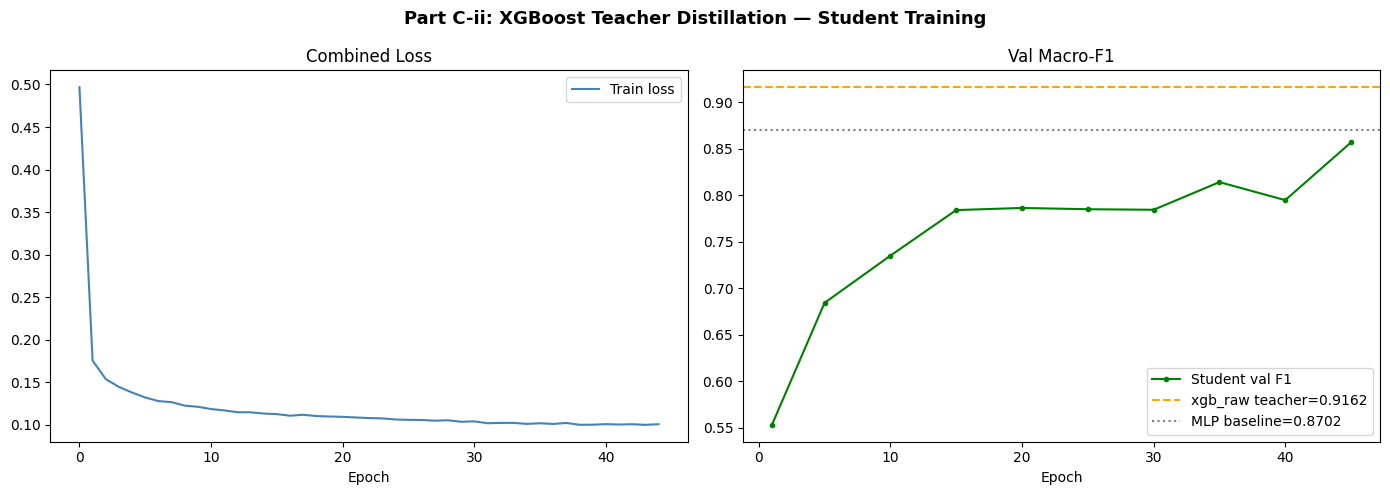

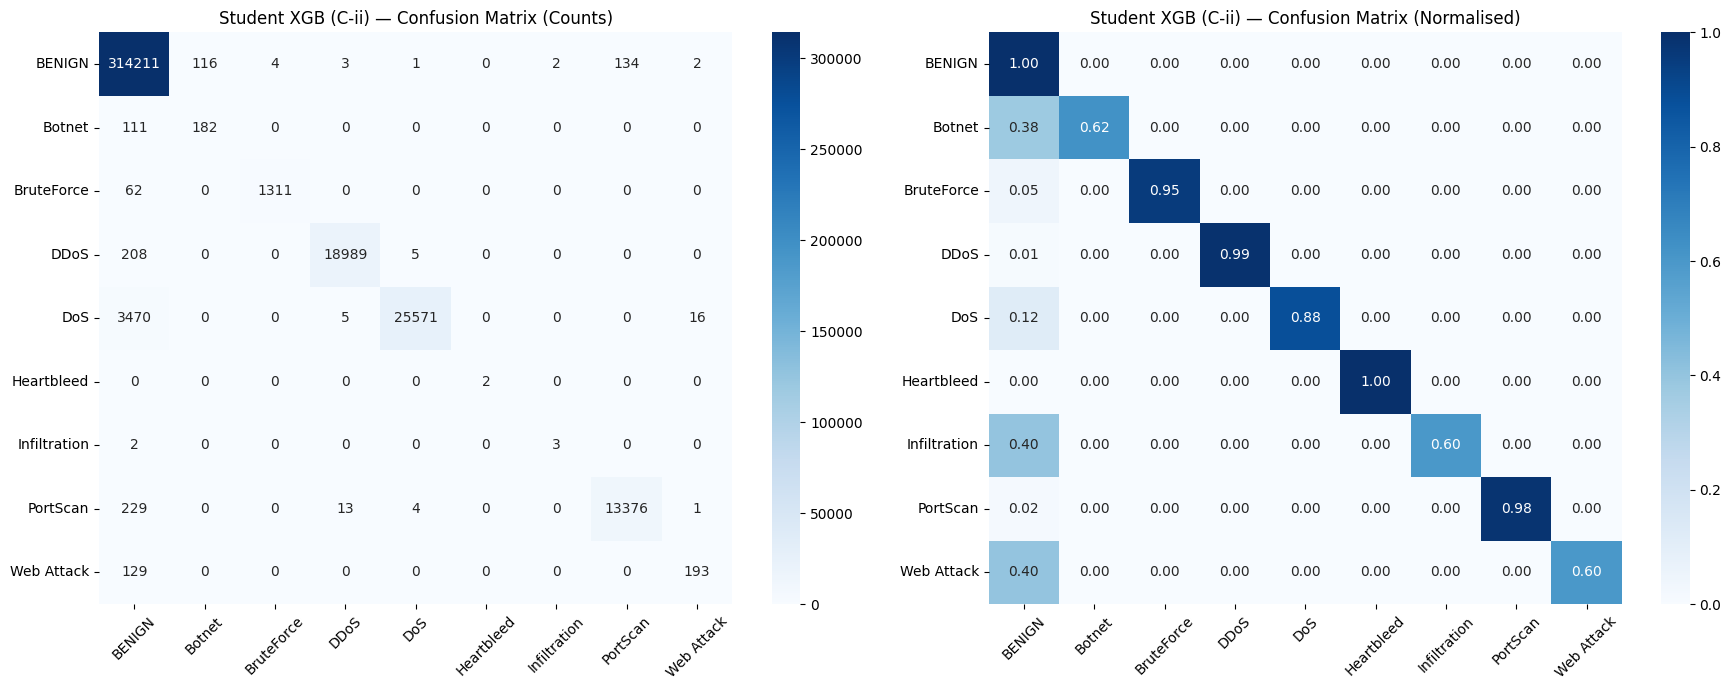

In [43]:
# ==============================================================================
# CELL C1-ii: Knowledge Distillation — XGBoost teacher (xgb_raw) → Student HybridVAE
#          Teacher: xgb_raw (Part B1)
#          Student: compressed HybridVAE (~220K params)
#          NO model_a needed — fully independent of VAE distillation.
#          Requires: xgb_raw trained (Cell 22),
#                    train_loader_a / val_loader_a / test_loader_a,
#                    X_test_w, y_te2, test_labels_a, test_preds_a,
#                    BENIGN_A, NEW_NUM_CLASSES, new_class_names,
#                    focal_fn_a, CONFIG, DEVICE, WHITENED_DIM,
#                    ResidualBlock (Cell 7)
# ==============================================================================

#reduce to 40 epochs
import copy, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import classification_report, f1_score, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

# ── Student Architecture ───────────────────────────────────────────────────────
# Identical to Cell 29 student — all dims halved vs HybridVAE teacher.
# Redefined here so this cell runs independently of Cell 29.

class StudentHybridVAE_XGB(nn.Module):
    def __init__(self, input_dim, latent_dim, encoder_dims, decoder_dims,
                 cls_out_dim, num_classes, dropout=0.3, variational=True):
        super().__init__()
        self.variational = variational
        self.latent_dim  = latent_dim
        # VAE Encoder
        enc, prev = [], input_dim
        for dim in encoder_dims:
            enc += [nn.Linear(prev, dim), nn.BatchNorm1d(dim),
                    nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        self.encoder    = nn.Sequential(*enc)
        self.res_enc    = ResidualBlock(encoder_dims[-1], dropout)
        self.fc_mu      = nn.Linear(encoder_dims[-1], latent_dim)
        self.fc_log_var = nn.Linear(encoder_dims[-1], latent_dim)
        # Decoder
        dec = [nn.Linear(latent_dim, decoder_dims[0]),
               nn.BatchNorm1d(decoder_dims[0]), nn.GELU(), nn.Dropout(dropout)]
        prev = decoder_dims[0]
        for dim in decoder_dims[1:]:
            dec += [nn.Linear(prev, dim), nn.BatchNorm1d(dim),
                    nn.GELU(), nn.Dropout(dropout)]
            prev = dim
        dec += [nn.Linear(prev, input_dim)]
        self.decoder = nn.Sequential(*dec)
        self.res_dec = ResidualBlock(decoder_dims[0], dropout)
        # CLS Encoder
        self.cls_encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, cls_out_dim), nn.BatchNorm1d(cls_out_dim), nn.GELU(),
        )
        # Classifier
        cls_in = latent_dim + cls_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(cls_in, cls_in * 2),          nn.BatchNorm1d(cls_in * 2),
            nn.GELU(), nn.Dropout(dropout),
            nn.Linear(cls_in * 2, max(cls_in, 64)), nn.BatchNorm1d(max(cls_in, 64)),
            nn.GELU(), nn.Dropout(dropout * 0.5),
            nn.Linear(max(cls_in, 64), num_classes)
        )

    def reparameterise(self, mu, log_var):
        if self.training and self.variational:
            return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return mu

    def encode(self, x):
        h = self.res_enc(self.encoder(x))
        return self.fc_mu(h), torch.clamp(self.fc_log_var(h), -4.0, 4.0)

    def decode(self, z):
        h = self.res_dec(self.decoder[:4](z))
        return self.decoder[4:](h)

    def cls_encode(self, x):
        return self.cls_encoder(x)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z           = self.reparameterise(mu, log_var)
        x_hat       = self.decode(z)
        cls_feat    = self.cls_encode(x)
        logits      = self.classifier(torch.cat([z, cls_feat], dim=1))
        return x_hat, logits, mu, log_var, z


student_xgb = StudentHybridVAE_XGB(
    input_dim    = WHITENED_DIM,
    latent_dim   = 32,
    encoder_dims = [256, 128, 64],
    decoder_dims = [64, 128, 256],
    cls_out_dim  = 64,
    num_classes  = NEW_NUM_CLASSES,
    dropout      = CONFIG['dropout_rate'],
    variational  = CONFIG['use_variational']
).to(DEVICE)

student_params = sum(p.numel() for p in student_xgb.parameters() if p.requires_grad)
print(f'Student parameters : {student_params:>10,}')
print(f'Teacher            : xgb_raw (raw whitened features, no latent extraction)')

# ── Raw XGBoost Soft Label Generator 
# No model_a needed — XGBoost takes raw whitened features directly.
def get_raw_xgb_soft_labels(X_batch, temperature=4.0):
    x_np      = X_batch.cpu().numpy().astype(np.float32)
    xgb_probs = xgb_raw.predict_proba(x_np).astype(np.float32)
    soft      = torch.tensor(xgb_probs).to(DEVICE) ** (1.0 / temperature)
    return (soft / soft.sum(dim=1, keepdim=True)).detach()

# ── Distillation Training 
DISTILL_EPOCHS = 45
T              = 4.0
ALPHA          = 0.7

opt_rd   = torch.optim.AdamW(student_xgb.parameters(),
                               lr=CONFIG['learning_rate'],
                               weight_decay=CONFIG['weight_decay'])
sched_rd = torch.optim.lr_scheduler.CosineAnnealingLR(
               opt_rd, T_max=DISTILL_EPOCHS, eta_min=1e-6)

history_rd    = {'train_loss': [], 'val_f1': []}
best_f1_rd    = 0.0
best_state_rd = None

print(f'\nDistillation from xgb_raw teacher — {DISTILL_EPOCHS} epochs')
print(f'T={T}  |  Alpha={ALPHA}  (70% XGBoost-raw soft labels, 30% focal)\n')

for epoch in range(1, DISTILL_EPOCHS + 1):

    student_xgb.train()
    tr_loss = 0.0

    for X_b, y_b, _ in train_loader_a:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)

        # Teacher soft labels from raw XGBoost at temperature T
        teacher_soft = get_raw_xgb_soft_labels(X_b, temperature=T)

        # Student forward passe
        s_hat, s_logits, s_mu, s_lv, s_z = student_xgb(X_b)

        # Reconstruction loss — BENIGN only (preserves anomaly detection)
        mask    = (y_b == BENIGN_A)
        L_recon = (F.l1_loss(s_hat[mask], X_b[mask])
                   if mask.sum() > 0 else torch.tensor(0.0, device=DEVICE))

        # KL divergence — regularises student latent space
        L_KL = -0.5 * torch.mean(1 + s_lv - s_mu.pow(2) - s_lv.exp())

        # Distillation loss — KL between student and XGBoost-raw soft labels
        L_distill = F.kl_div(
            F.log_softmax(s_logits / T, dim=1),
            teacher_soft,
            reduction='batchmean'
        ) * (T ** 2)

        # Hard focal loss on true labels
        L_hard = focal_fn_a(s_logits, y_b)

        L_cls = ALPHA * L_distill + (1.0 - ALPHA) * L_hard
        loss  = (CONFIG['alpha']    * L_recon +
                 CONFIG['beta']     * L_cls   +
                 CONFIG['gamma_kl'] * L_KL)

        opt_rd.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(student_xgb.parameters(), max_norm=1.0)
        opt_rd.step()
        tr_loss += loss.item()

    sched_rd.step()
    history_rd['train_loss'].append(tr_loss / len(train_loader_a))

    if epoch % 5 == 0 or epoch == 1:
        student_xgb.eval()
        preds, trues = [], []
        with torch.no_grad():
            for X_b, y_b, _ in val_loader_a:
                _, s_logits, _, _, _ = student_xgb(X_b.to(DEVICE))
                preds.extend(s_logits.argmax(1).cpu().numpy())
                trues.extend(y_b.numpy())
        val_f1 = f1_score(trues, preds, average='macro', zero_division=0)
        history_rd['val_f1'].append(val_f1)
        marker = ''
        if val_f1 > best_f1_rd:
            best_f1_rd    = val_f1
            best_state_rd = copy.deepcopy(student_xgb.state_dict())
            marker = ' <- best'
        print(f'  Ep {epoch:3d}/{DISTILL_EPOCHS} | Train: {tr_loss/len(train_loader_a):.4f} | Val F1: {val_f1:.4f} | LR: {sched_rd.get_last_lr()[0]:.6f}{marker}')

student_xgb.load_state_dict(best_state_rd)
torch.save(best_state_rd, './student_xgb_distilled.pt')
print(f'\nBest student saved -> ./student_xgb_distilled.pt')
print(f'Best Val Macro-F1 : {best_f1_rd:.4f}')

# ── Test Evaluation ────────────────────────────────────────────────────────────
student_xgb.eval()
srd_preds, srd_true = [], []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, s_logits, _, _, _ = student_xgb(X_b.to(DEVICE))
        srd_preds.extend(s_logits.argmax(1).cpu().numpy())
        srd_true.extend(y_b.numpy())
srd_preds = np.array(srd_preds)
srd_true  = np.array(srd_true)

srd_macro  = f1_score(srd_true, srd_preds, average='macro', zero_division=0)
mlp_macro  = f1_score(test_labels_a, test_preds_a, average='macro', zero_division=0)
raw_macro  = f1_score(y_te2, xgb_raw.predict(X_test_w), average='macro', zero_division=0)

print('\n' + '=' * 60)
print('  STUDENT (xgb_raw teacher) — TEST CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(srd_true, srd_preds,
                              target_names=new_class_names, zero_division=0))

print('=' * 62)
print(f'  {"Model":<35} {"Params":>8} {"Macro F1":>9}')
print('  ' + '-' * 55)
print(f'  {"HybridVAE teacher (Part A)":<35} {teacher_params:>8} {mlp_macro:>9.4f}')
print(f'  {"XGBoost raw teacher (Part B)":<35} {"trees":>8} {raw_macro:>9.4f}')
print(f'  {"Student distilled from xgb_raw":<35} {student_params:>8,} {srd_macro:>9.4f}')
print(f'  {"F1 retained vs xgb_raw teacher":<35} {"":>8} {srd_macro/raw_macro:>9.1%}')
print('=' * 62)

# ── Training Curve ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part C-ii: XGBoost Teacher Distillation — Student Training',
             fontsize=13, fontweight='bold')
ax1.plot(history_rd['train_loss'], color='steelblue', label='Train loss')
ax1.set_title('Combined Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
val_epochs = [e for e in range(1, DISTILL_EPOCHS + 1) if e % 5 == 0 or e == 1]
ax2.plot(val_epochs[:len(history_rd['val_f1'])], history_rd['val_f1'],
         color='green', marker='o', markersize=3, label='Student val F1')
ax2.axhline(raw_macro,  color='orange', linestyle='--',
            label=f'xgb_raw teacher={raw_macro:.4f}')
ax2.axhline(mlp_macro,  color='grey',   linestyle=':',
            label=f'MLP baseline={mlp_macro:.4f}')
ax2.set_title('Val Macro-F1'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('distillation_xgb_teacher_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm_rd      = confusion_matrix(srd_true, srd_preds)
cm_rd_norm = cm_rd.astype(float) / cm_rd.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_rd, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('Student XGB (C-ii) — Confusion Matrix (Counts)')
axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(cm_rd_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('Student XGB (C-ii) — Confusion Matrix (Normalised)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('confusion_student_xgb_distilled.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Part E — Knowledge Distillation Summary

Consolidates results from Part C-i and Part C-ii into a single comparison table.

Both students share the same compact architecture (~221K parameters) but differ in their soft-label source:
- **Student C-i** learned from the HybridVAE teacher's soft outputs
- **Student C-ii** learned from XGBoost's probabilistic predictions

This table answers: *How much classification accuracy is lost in compression, and how does the choice of teacher affect the student?*

**Dependencies:** Part A (Cell A6), Part B (Cell B1), Part C-i (Cell C1-i), and Part C-ii (Cell C1-ii) must all be run before this cell.


In [44]:
# ============================================================
# CELL E1: Distillation summary — both students vs teachers
# ============================================================
# Requires: Part A6 (model_a, test_labels_a, test_preds_a), Part B1 (xgb_raw),
#           Part C-i (student_vae, s_macro, s_acc, teacher_params, student_params),
#           Part C-ii (student_xgb, srd_macro, student_params from C-ii — last one wins)

def _count(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

teacher_vae_params = _count(model_a)
teacher_xgb_note = 'N/A (ensemble of trees; use pickle size for deployment footprint)'

stu_vae_p = _count(student_vae)
stu_xgb_p = _count(student_xgb)

t_f1 = f1_score(test_labels_a, test_preds_a, average='macro', zero_division=0)
t_acc = (test_preds_a == test_labels_a).mean()
x_f1 = f1_score(y_te2, xgb_raw.predict(X_test_w), average='macro', zero_division=0)
x_acc = (xgb_raw.predict(X_test_w) == y_te2).mean()

print('\n' + '=' * 78)
print('  PART E — KNOWLEDGE DISTILLATION vs TEACHERS (test set, 9 classes)')
print('=' * 78)
print(f'  {"Role":<14} {"Model":<32} {"Params":>12} {"Acc":>8} {"MacroF1":>8}')
print('  ' + '-' * 74)
print(f'  {"Teacher":<14} {"HybridVAE (Part A)":<32} {teacher_vae_params:>12,} {t_acc:>7.2%} {t_f1:>8.4f}')
print(f'  {"Student C-i":<14} {"Student from VAE teacher":<32} {stu_vae_p:>12,} {s_acc:>7.2%} {s_macro:>8.4f}')
print(f'  {"— retained":<14} {"F1 vs VAE teacher":<32} {"":>12} {"":>8} {s_macro/t_f1:>7.1%} of teacher F1')
print('  ' + '-' * 74)
print(f'  {"Teacher":<14} {"XGBoost raw (Part B)":<32} {teacher_xgb_note:>12} {x_acc:>7.2%} {x_f1:>8.4f}')
print(f'  {"Student C-ii":<14} {"Student from XGBoost teacher":<32} {stu_xgb_p:>12,} {(srd_preds==srd_true).mean():>7.2%} {srd_macro:>8.4f}')
print(f'  {"— retained":<14} {"F1 vs XGBoost teacher":<32} {"":>12} {"":>8} {srd_macro/x_f1:>7.1%} of teacher F1')
print('  ' + '-' * 74)
print(f'  {"Size ratio":<14} {"Student params / HybridVAE teacher":<32} {stu_vae_p/teacher_vae_params:>12.2%}')
print('=' * 78)




  PART E — KNOWLEDGE DISTILLATION vs TEACHERS (test set, 9 classes)
  Role           Model                                  Params      Acc  MacroF1
  --------------------------------------------------------------------------
  Teacher        HybridVAE (Part A)                    749,270  99.01%   0.8702
  Student C-i    Student from VAE teacher              221,462  98.73%   0.8621
  — retained     F1 vs VAE teacher                                        99.1% of teacher F1
  --------------------------------------------------------------------------
  Teacher        XGBoost raw (Part B)             N/A (ensemble of trees; use pickle size for deployment footprint)  99.82%   0.9162
  Student C-ii   Student from XGBoost teacher          221,462  98.81%   0.8692
  — retained     F1 vs XGBoost teacher                                    94.9% of teacher F1
  --------------------------------------------------------------------------
  Size ratio     Student params / HybridVAE teacher       

---

### Cell C2 — Anomaly Detection Evaluation: ROC, Precision-Recall, and Pareto Frontier

Evaluates the **VAE reconstruction error as a binary anomaly score** (0 = BENIGN, 1 = any attack), independent of the classification head.

> **Note:** This cell currently uses `student_vae` (from Part C-i) as the model. To evaluate `model_a` or `student_xgb`, uncomment the corresponding lines at the top of the cell.

**Outputs produced:**

| Plot | Description |
|---|---|
| **ROC Curve** | FPR vs TPR across all thresholds; AUC summarises overall detectability. The Youden-optimal point (max TPR − FPR) is marked |
| **Precision-Recall Curve** | More informative than ROC for heavily imbalanced data; the F1-optimal threshold is marked |
| **Pareto Frontier** | Shows Pareto-optimal (precision, recall) operating points — no other threshold achieves both higher precision and higher recall simultaneously |
| **Per-class AUC** | One-vs-rest AUC for each attack class; reveals which attack types are easiest/hardest to detect via reconstruction error alone |
| **Threshold guide table** | TPR, FPR, precision, recall, and F1 at the 90th/93rd/95th/97th/99th percentile BENIGN thresholds |

Saved to `roc_pr_pareto.png`.


Test samples      : 378,355
Attack samples    : 63,882
BENIGN samples    : 314,473
Score range       : [0.0052, 20.6472]

ROC AUC           : 0.8500
Optimal threshold : 0.8530  (Youden J)
At optimal        : TPR=0.593  FPR=0.051

Average Precision : 0.6815
F1-optimal thresh : 1.1503
At F1-optimal     : Precision=0.785  Recall=0.559  F1=0.653


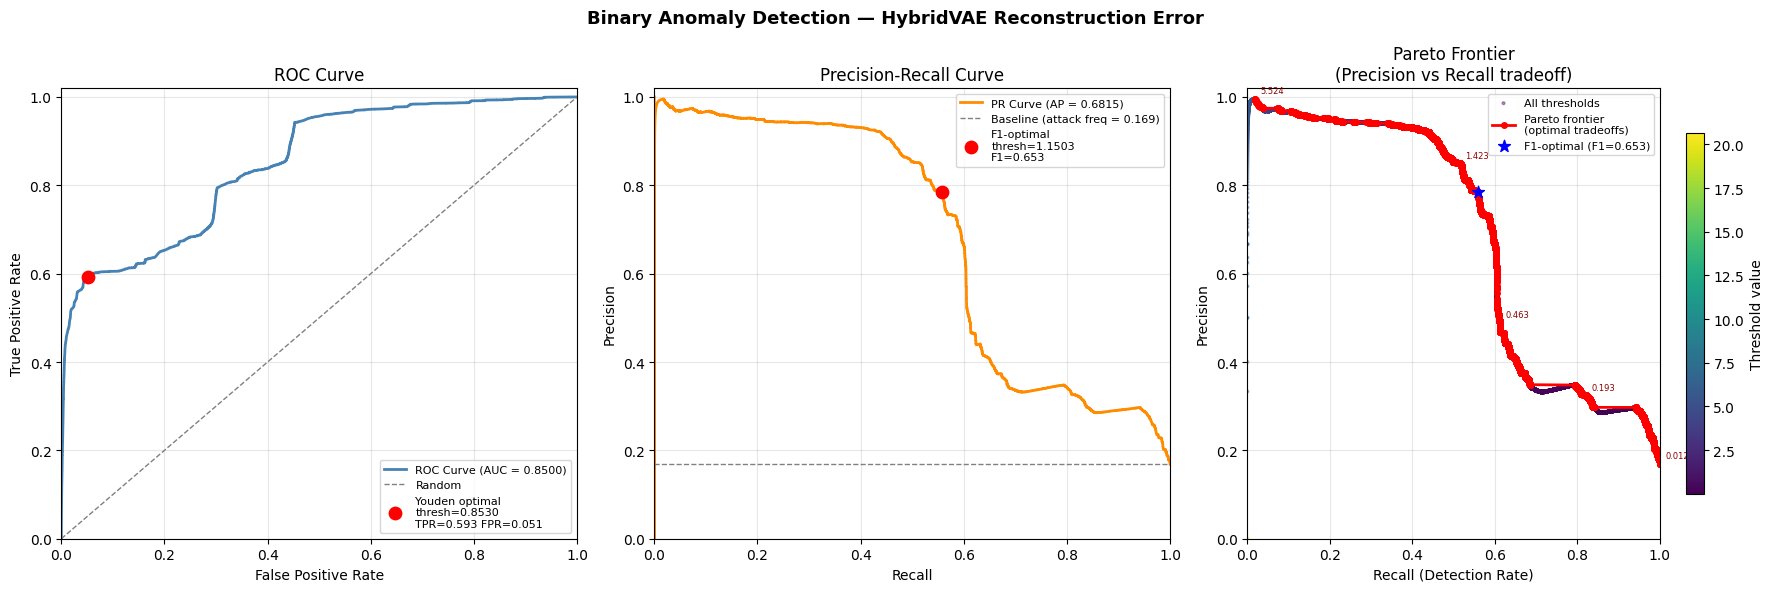


  PER-CLASS AUC (reconstruction error, one-vs-rest)
  Class                       AUC   Support
  ------------------------------------------
  BENIGN                      N/A   314,473
  Botnet                   0.5190       293
  BruteForce               0.8057     1,373
  DDoS                     0.8576    19,202
  DoS                      0.9479    29,062
  Heartbleed               0.9998         2
  Infiltration             0.8075         5
  PortScan                 0.6459    13,623
  Web Attack               0.6815       322
  ------------------------------------------
  Overall binary AUC       0.8500

  THRESHOLD SELECTION GUIDE
  Threshold          TPR     FPR  Precision   Recall       F1
  ----------------------------------------------------------
  0.5378           0.605   0.100      0.551    0.605    0.577  <- 90th pct BENIGN
  0.6704           0.602   0.070      0.636    0.602    0.619  <- 93th pct BENIGN
  0.8731           0.591   0.050      0.706    0.591    0.644  <- 9

In [45]:
# ==============================================================================
# CELL: ROC Curve, AUC, Precision-Recall Curve, Pareto Frontier
# Requires: model_a trained (Cell 18), test_loader_a, X_test_w,
#           y_te2, new_class_names, BENIGN_A, DEVICE
# ==============================================================================
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, roc_auc_score,
                             precision_recall_curve,
                             average_precision_score)

#model_a.eval()
#student_xgb.eval()
student_vae.eval()


# ── Step 1: Collect reconstruction errors and true binary labels ───────────────
# Reconstruction error is the anomaly score for every test flow.
# Binary label: 0 = BENIGN, 1 = any attack.

recon_scores = []
true_binary  = []
true_multi   = []

with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        X_b = X_b.to(DEVICE)
        #x_hat, _, _, _, _ = model_a(X_b)
        #x_hat, _, _, _, _ = student_xgb(X_b)
        x_hat, _, _, _, _ = student_vae(X_b)
        err = F.l1_loss(x_hat, X_b, reduction='none').mean(dim=1)
        recon_scores.append(err.cpu().numpy())
        true_binary.append((y_b.numpy() != BENIGN_A).astype(int))
        true_multi.append(y_b.numpy())

recon_scores = np.concatenate(recon_scores)
true_binary  = np.concatenate(true_binary)
true_multi   = np.concatenate(true_multi)

print(f'Test samples      : {len(recon_scores):,}')
print(f'Attack samples    : {true_binary.sum():,}')
print(f'BENIGN samples    : {(true_binary==0).sum():,}')
print(f'Score range       : [{recon_scores.min():.4f}, {recon_scores.max():.4f}]')

# ── Step 2: ROC Curve and AUC ──────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(true_binary, recon_scores)
auc_score = roc_auc_score(true_binary, recon_scores)

# Youden J statistic — optimal threshold balancing TPR and FPR
youden_idx       = np.argmax(tpr - fpr)
optimal_thresh   = roc_thresholds[youden_idx]
optimal_tpr      = tpr[youden_idx]
optimal_fpr      = fpr[youden_idx]

print(f'\nROC AUC           : {auc_score:.4f}')
print(f'Optimal threshold : {optimal_thresh:.4f}  (Youden J)')
print(f'At optimal        : TPR={optimal_tpr:.3f}  FPR={optimal_fpr:.3f}')

# ── Step 3: Precision-Recall Curve and Average Precision ──────────────────────
precision, recall, pr_thresholds = precision_recall_curve(true_binary, recon_scores)
avg_precision = average_precision_score(true_binary, recon_scores)

# F1-optimal threshold from PR curve
f1_scores_pr = np.where(
    (precision + recall) > 0,
    2 * precision * recall / (precision + recall + 1e-9),
    0
)
best_pr_idx    = np.argmax(f1_scores_pr)
best_pr_thresh = pr_thresholds[best_pr_idx] if best_pr_idx < len(pr_thresholds) else pr_thresholds[-1]
best_precision = precision[best_pr_idx]
best_recall    = recall[best_pr_idx]
best_f1_binary = f1_scores_pr[best_pr_idx]

print(f'\nAverage Precision : {avg_precision:.4f}')
print(f'F1-optimal thresh : {best_pr_thresh:.4f}')
print(f'At F1-optimal     : Precision={best_precision:.3f}  Recall={best_recall:.3f}  F1={best_f1_binary:.3f}')

# ── Step 4: Plot all three charts ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Binary Anomaly Detection — HybridVAE Reconstruction Error',
             fontsize=13, fontweight='bold')

# ── Plot 1: ROC Curve ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random')
ax.scatter(optimal_fpr, optimal_tpr, color='red', s=80, zorder=5,
           label=f'Youden optimal\nthresh={optimal_thresh:.4f}\nTPR={optimal_tpr:.3f} FPR={optimal_fpr:.3f}')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Plot 2: Precision-Recall Curve ────────────────────────────────────────────
ax = axes[1]
ax.plot(recall, precision, color='darkorange', lw=2,
        label=f'PR Curve (AP = {avg_precision:.4f})')
ax.axhline(true_binary.mean(), color='grey', linestyle='--', lw=1,
           label=f'Baseline (attack freq = {true_binary.mean():.3f})')
ax.scatter(best_recall, best_precision, color='red', s=80, zorder=5,
           label=f'F1-optimal\nthresh={best_pr_thresh:.4f}\nF1={best_f1_binary:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

# ── Plot 3: Pareto Frontier (Precision vs Recall across thresholds) ────────────
# Pareto-optimal points: no other threshold achieves higher precision
# AND higher recall simultaneously.
ax = axes[2]

# All threshold operating points
ax.scatter(recall[:-1], precision[:-1], c=pr_thresholds,
           cmap='viridis', s=4, alpha=0.4, label='All thresholds')

r = recall[:-1]
p = precision[:-1]

# Sort by recall descending, then precision descending
sort_idx   = np.lexsort((-p, -r))
r_sorted   = r[sort_idx]
p_sorted   = p[sort_idx]

# A point is Pareto-optimal if its precision is >= all points with higher recall
# (i.e. running maximum of precision as we scan left-to-right in recall)
max_prec_so_far = np.maximum.accumulate(p_sorted)
pareto_mask_sorted = (p_sorted >= max_prec_so_far)

# Map back to original indexing
original_indices = sort_idx[pareto_mask_sorted]
pareto_recall    = r[original_indices]
pareto_precision = p[original_indices]
pareto_thresh    = pr_thresholds[original_indices]

# Sort by recall for plotting
plot_order       = np.argsort(pareto_recall)
pareto_recall    = pareto_recall[plot_order]
pareto_precision = pareto_precision[plot_order]
pareto_thresh    = pareto_thresh[plot_order]

ax.plot(pareto_recall, pareto_precision, 'r-o', lw=2, markersize=4,
        label='Pareto frontier\n(optimal tradeoffs)')

# Annotate a few key Pareto points
for idx in [0, len(pareto_recall)//4, len(pareto_recall)//2,
            3*len(pareto_recall)//4, -1]:
    if idx < len(pareto_recall):
        ax.annotate(f'{pareto_thresh[idx]:.3f}',
                    (pareto_recall[idx], pareto_precision[idx]),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=6, color='darkred')

# Mark the F1-optimal point
ax.scatter(best_recall, best_precision, color='blue', s=80, zorder=6,
           marker='*', label=f'F1-optimal (F1={best_f1_binary:.3f})')

ax.set_xlabel('Recall (Detection Rate)')
ax.set_ylabel('Precision')
ax.set_title('Pareto Frontier\n(Precision vs Recall tradeoff)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.colorbar(
    plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(pr_thresholds.min(), pr_thresholds.max())
    ),
    ax=axes[2], label='Threshold value', shrink=0.8
)

plt.tight_layout()
plt.savefig('roc_pr_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Step 5: Per-class AUC (one-vs-rest) ───────────────────────────────────────
print('\n' + '=' * 55)
print('  PER-CLASS AUC (reconstruction error, one-vs-rest)')
print('=' * 55)
print(f'  {"Class":<22} {"AUC":>8}  {"Support":>8}')
print('  ' + '-' * 42)

# for ci, cname in enumerate(new_class_names):
#     class_mask = (true_multi == ci) | (true_multi == BENIGN_A)
#     if class_mask.sum() < 10 or (true_multi[class_mask] == ci).sum() < 2:
#         print(f'  {cname:<22} {"N/A":>8}  {(true_multi==ci).sum():>8,}')
#         continue
#     y_bin_ci   = (true_multi[class_mask] == ci).astype(int)
#     scores_ci  = recon_scores[class_mask]
#     auc_ci     = roc_auc_score(y_bin_ci, scores_ci)
#     support_ci = (true_multi == ci).sum()
#     print(f'  {cname:<22} {auc_ci:>8.4f}  {support_ci:>8,}')


for ci, cname in enumerate(new_class_names):
    class_mask = (true_multi == ci) | (true_multi == BENIGN_A)
    if class_mask.sum() < 10 or (true_multi[class_mask] == ci).sum() < 2:
        print(f'  {cname:<22} {"N/A":>8}  {(true_multi==ci).sum():>8,}')
        continue

    y_bin_ci  = (true_multi[class_mask] == ci).astype(int)
    scores_ci = recon_scores[class_mask]

    # ── add this check ────────────────────────────────────────────────────────
    if len(np.unique(y_bin_ci)) < 2:
        print(f'  {cname:<22} {"N/A":>8}  {(true_multi==ci).sum():>8,}')
        continue
    # ─────────────────────────────────────────────────────────────────────────

    auc_ci     = roc_auc_score(y_bin_ci, scores_ci)
    support_ci = (true_multi == ci).sum()
    print(f'  {cname:<22} {auc_ci:>8.4f}  {support_ci:>8,}')

print('  ' + '-' * 42)
print(f'  {"Overall binary AUC":<22} {auc_score:>8.4f}')
print('=' * 55)

# ── Step 6: Summary table of threshold options ─────────────────────────────────
print('\n' + '=' * 70)
print('  THRESHOLD SELECTION GUIDE')
print('=' * 70)
print(f'  {"Threshold":<14} {"TPR":>7} {"FPR":>7} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('  ' + '-' * 58)

check_thresholds = np.percentile(recon_scores[true_binary == 0],
                                  [90, 93, 95, 97, 99])
for t in check_thresholds:
    preds   = (recon_scores > t).astype(int)
    tp      = ((preds==1)&(true_binary==1)).sum()
    fp      = ((preds==1)&(true_binary==0)).sum()
    fn      = ((preds==0)&(true_binary==1)).sum()
    tpr_t   = tp / (tp + fn + 1e-9)
    fpr_t   = fp / ((true_binary==0).sum() + 1e-9)
    prec_t  = tp / (tp + fp + 1e-9)
    rec_t   = tpr_t
    f1_t    = 2*prec_t*rec_t / (prec_t + rec_t + 1e-9)
    pct     = np.mean(recon_scores[true_binary==0] <= t) * 100
    print(f'  {t:<14.4f} {tpr_t:>7.3f} {fpr_t:>7.3f} {prec_t:>10.3f} {rec_t:>8.3f} {f1_t:>8.3f}'
          f'  <- {pct:.0f}th pct BENIGN')

print(f'\n  Currently using: 95th percentile (CONFIG[\"recon_percentile\"])')
print(f'  Youden-optimal : {optimal_thresh:.4f}  (maximises TPR - FPR)')
print(f'  F1-optimal     : {best_pr_thresh:.4f}  (maximises binary F1)')
print('=' * 70)


In [46]:
# ── Step 7: Compare model_a (teacher) vs student_vae (student) AUC ────────────
print('\n' + '=' * 60)
print('  ANOMALY DETECTION RETENTION — Teacher vs Student')
print('=' * 60)

# Collect teacher (model_a) reconstruction errors
model_a.eval()
teacher_scores = []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        X_b = X_b.to(DEVICE)
        x_hat, _, _, _, _ = model_a(X_b)
        err = F.l1_loss(x_hat, X_b, reduction='none').mean(dim=1)
        teacher_scores.append(err.cpu().numpy())
teacher_scores = np.concatenate(teacher_scores)

teacher_auc = roc_auc_score(true_binary, teacher_scores)
student_auc = auc_score  # already computed above from student_vae

print(f'\n  {"Model":<35} {"Params":>8}  {"AUC":>7} ')
print('  ' + '-' * 58)
print(f'  {"HybridVAE teacher (model_a)":<35} {"749,270":>8}  {teacher_auc:>7.4f}')
print(f'  {"Student VAE (C-i, distilled)":<35} {"221,462":>8}  {student_auc:>7.4f}  ')
      #f'{student_auc/teacher_auc:.1%} of teacher')
print('=' * 60)

# Per-class AUC comparison
print(f'\n  {"Class":<22} {"Teacher AUC":>12} {"Student AUC":>12} {"Δ":>8}')
print('  ' + '-' * 56)
for ci, cname in enumerate(new_class_names):
    if cname == 'BENIGN':
        continue
    class_mask = (true_multi == ci) | (true_multi == BENIGN_A)
    if class_mask.sum() < 10 or (true_multi[class_mask] == ci).sum() < 2:
        continue
    y_bin_ci = (true_multi[class_mask] == ci).astype(int)
    if len(np.unique(y_bin_ci)) < 2:
        continue
    t_auc = roc_auc_score(y_bin_ci, teacher_scores[class_mask])
    s_auc = roc_auc_score(y_bin_ci, recon_scores[class_mask])
    delta = s_auc - t_auc
    print(f'  {cname:<22} {t_auc:>12.4f} {s_auc:>12.4f} {delta:>+8.4f} ')
print('  ' + '-' * 56)
print(f'  {"Overall binary AUC":<22} {teacher_auc:>12.4f} {student_auc:>12.4f} '
      f'{student_auc - teacher_auc:>+8.4f}')
print('=' * 60)


  ANOMALY DETECTION RETENTION — Teacher vs Student

  Model                                 Params      AUC 
  ----------------------------------------------------------
  HybridVAE teacher (model_a)          749,270   0.8740
  Student VAE (C-i, distilled)         221,462   0.8500  

  Class                   Teacher AUC  Student AUC        Δ
  --------------------------------------------------------
  Botnet                       0.5575       0.5190  -0.0385 
  BruteForce                   0.7892       0.8057  +0.0165 
  DDoS                         0.8898       0.8576  -0.0322 
  DoS                          0.9490       0.9479  -0.0012 
  Heartbleed                   0.9998       0.9998  -0.0000 
  Infiltration                 0.8389       0.8075  -0.0314 
  PortScan                     0.7095       0.6459  -0.0636 
  Web Attack                   0.7677       0.6815  -0.0862 
  --------------------------------------------------------
  Overall binary AUC           0.8740       0.85

---

## Part D — Held-Out Class Experiment (8-Class Training)

Retrains **both** HybridVAE and XGBoost on **8 classes** with one attack class completely withheld from training. Then tests both models on the withheld class to demonstrate the fundamental difference in their anomaly handling.

#### The Core Question

When presented with a completely unknown attack type, what does each model output?

| Model | What it outputs on unseen attack | Why |
|---|---|---|
| **XGBoost (discriminative)** | Predicts BENIGN or nearest known class with high confidence | Discriminative models partition the input space into $N$ fixed regions; unseen inputs must fall in one region |
| **HybridVAE (generative)** | High reconstruction error → flagged as **ANOMALY** | The VAE decoder is fitted to the BENIGN manifold; any traffic that deviates from normal produces high L1 error |

This is the key advantage of generative anomaly detection: it can flag *novel* threats that were never seen during training.

**Withheld class:** `Heartbleed` (configurable in Cell D1)

**Execution order:**
1. **D1** — Choose withheld class and build 8-class train/val sets
2. **D2** — Train 8-class XGBoost
3. **D3** — Train 8-class HybridVAE (`model_d`)
4. **D4** — Training curves
5. **D5** — Evaluate `model_d` on the 8 known classes (sanity check)
6. **D6** — Calibrate anomaly threshold from BENIGN validation samples
7. **D7** — Run both models on withheld class samples
8. **D8** — Visualisation and summary

**Dependencies:** Shared setup cells 1–7, plus Part A Cell A1 (for label remapping variables).


### Cell D1 — Choose Withheld Class and Build 8-Class Training Set

Removes the chosen class from both training and validation sets. Labels are remapped to fill the gap (so class indices remain contiguous from 0 to N-1).

**To change the withheld class:** Edit `WITHHELD_CLASS_NAME` at the top of this cell. Any class from `new_class_names` is valid. `Heartbleed` is the default because it has the fewest samples, making it the most realistic "novel threat" scenario.

**Note:** The *test set* is not modified. Withheld-class test samples are preserved for evaluation in Cell D7 (using `withheld_mask`). The 8-class train/val sets simply never see those samples.


In [47]:
# ============================================================
# CELL D1: Choose withheld class & build 8-class training set
#          (used by BOTH HybridVAE and XGBoost in Part D)
# ============================================================
import numpy as np
from collections import Counter

# ── Choose which class to withhold ───────────────────────────
# Options: any name from new_class_names, e.g. 'Botnet', 'Heartbleed', 'DDoS'
WITHHELD_CLASS_NAME = 'Heartbleed'

WITHHELD_IDX = new_class_names.index(WITHHELD_CLASS_NAME)
print(f'Withheld class  : [{WITHHELD_IDX}] {WITHHELD_CLASS_NAME}')
print(f'All 9 classes   : {new_class_names}')

# ── Remove withheld class from train / val ────────────────────
mask_tr_8 = y_tr2 != WITHHELD_IDX
mask_va_8 = y_va2 != WITHHELD_IDX

X_tr_8     = X_train_w[mask_tr_8]
X_va_8     = X_val_w[mask_va_8]
y_tr_8_raw = y_tr2[mask_tr_8].copy()
y_va_8_raw = y_va2[mask_va_8].copy()

# Remap labels to be contiguous (fill the gap left by the removed class)
class_names_8 = [n for i, n in enumerate(new_class_names) if i != WITHHELD_IDX]
old_to_new_8  = {}
new_idx = 0
for old_idx in range(NEW_NUM_CLASSES):
    if old_idx != WITHHELD_IDX:
        old_to_new_8[old_idx] = new_idx
        new_idx += 1

y_tr_8        = np.array([old_to_new_8[c] for c in y_tr_8_raw])
y_va_8        = np.array([old_to_new_8[c] for c in y_va_8_raw])
NUM_CLASSES_8 = len(class_names_8)
BENIGN_8      = old_to_new_8[BENIGN_A]

# Test mask — withheld samples used for evaluation only
mask_te_8    = y_te2 != WITHHELD_IDX
withheld_mask = y_te2 == WITHHELD_IDX

print(f'\n8-class set     : {NUM_CLASSES_8} classes')
print(f'Train samples   : {len(X_tr_8):,}  (removed {(~mask_tr_8).sum():,} {WITHHELD_CLASS_NAME} training samples)')
print(f'Val samples     : {len(X_va_8):,}')
print(f'Withheld test   : {withheld_mask.sum():,} samples')
print(f'Classes (8)     : {class_names_8}')


Withheld class  : [5] Heartbleed
All 9 classes   : ['BENIGN', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Heartbleed', 'Infiltration', 'PortScan', 'Web Attack']

8-class set     : 8 classes
Train samples   : 1,780,534  (removed 3,000 Heartbleed training samples)
Val samples     : 378,353
Withheld test   : 2 samples
Classes (8)     : ['BENIGN', 'Botnet', 'BruteForce', 'DDoS', 'DoS', 'Infiltration', 'PortScan', 'Web Attack']


### Cell D2 — Train 8-Class XGBoost

Trains XGBoost with identical hyperparameters to Part B (`xgb_raw`), but on the 8-class training set with the withheld class excluded.

A sanity-check evaluation on the 8 known test classes confirms the model still performs well on what it was trained on.

**Key insight to verify in Cell D7:** When `xgb_8class` sees a withheld-class sample, it will predict BENIGN or the nearest known attack class with **high confidence** — it has no mechanism to express uncertainty or flag an unknown input.


In [48]:
# ============================================================
# CELL D2: Train 8-class XGBoost (withheld class excluded)
# ============================================================
import xgboost as xgb
from sklearn.metrics import classification_report, f1_score
from collections import Counter

# ── Class weights (inverse-frequency, same scheme as Part B) ─
cnt_8 = Counter(y_tr_8)
sw_8  = np.array([
    1.0 if c == BENIGN_8 else len(y_tr_8) / (NUM_CLASSES_8 * cnt_8[c])
    for c in y_tr_8
], dtype=np.float32)

print('Class weights for 8-class XGBoost:')
for c in range(NUM_CLASSES_8):
    w = 1.0 if c == BENIGN_8 else len(y_tr_8) / (NUM_CLASSES_8 * cnt_8[c])
    print(f'  [{c}] {class_names_8[c]:<22}: n={cnt_8[c]:>7,}  weight={w:.3f}')

# ── Train ─────────────────────────────────────────────────────
print(f'\nTraining 8-class XGBoost (withheld: {WITHHELD_CLASS_NAME})...')

xgb_8class = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 8,
    learning_rate         = 0.1,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 1,
    gamma                 = 0.0,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    objective             = 'multi:softprob',
    num_class             = NUM_CLASSES_8,
    eval_metric           = 'mlogloss',
    use_label_encoder     = False,
    tree_method           = 'hist',
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 30,
)

xgb_8class.fit(
    X_tr_8, y_tr_8,
    sample_weight = sw_8,
    eval_set      = [(X_va_8, y_va_8)],
    verbose       = 50,
)
print(f'\nBest iteration: {xgb_8class.best_iteration}')

# ── Sanity check on known-class test samples ──────────────────
y_te_8     = np.array([old_to_new_8[c] for c in y_te2[mask_te_8]])
preds_te_8 = xgb_8class.predict(X_test_w[mask_te_8])
f1_te_8    = f1_score(y_te_8, preds_te_8, average='macro', zero_division=0)

print(f'\n8-class XGBoost — Macro F1 (known classes only): {f1_te_8:.4f}')
print(classification_report(y_te_8, preds_te_8, target_names=class_names_8, zero_division=0))


Class weights for 8-class XGBoost:
  [0] BENIGN                : n=1,467,538  weight=1.000
  [1] Botnet                : n=  4,101  weight=54.271
  [2] BruteForce            : n=  8,000  weight=27.821
  [3] DDoS                  : n= 89,611  weight=2.484
  [4] DoS                   : n=135,624  weight=1.641
  [5] Infiltration          : n=  3,000  weight=74.189
  [6] PortScan              : n= 63,573  weight=3.501
  [7] Web Attack            : n=  9,087  weight=24.493

Training 8-class XGBoost (withheld: Heartbleed)...
[0]	validation_0-mlogloss:0.87368
[50]	validation_0-mlogloss:0.02451
[100]	validation_0-mlogloss:0.01125
[150]	validation_0-mlogloss:0.00807
[200]	validation_0-mlogloss:0.00685
[250]	validation_0-mlogloss:0.00633
[300]	validation_0-mlogloss:0.00612
[350]	validation_0-mlogloss:0.00601
[400]	validation_0-mlogloss:0.00595
[450]	validation_0-mlogloss:0.00594
[469]	validation_0-mlogloss:0.00594

Best iteration: 439

8-class XGBoost — Macro F1 (known classes only): 0.8915
    

### Cell D3 — Train 8-Class HybridVAE (`model_d`)

Trains a fresh HybridVAE on the 8-class training set. Architecture is identical to `model_a` but with `num_classes=8`.

The VAE decoder is optimised on **BENIGN-only reconstruction** — this is the one-class principle. The withheld class, never seen during training, will produce high reconstruction error at test time because it deviates from the learned BENIGN manifold.

**Checkpointing:** Best model saved based on **8-class validation Macro F1** (not including the withheld class, which is never in the validation set). Saved to `model_d_8class.pt`.


In [49]:
# ============================================================
# CELL D3: Train 8-class HybridVAE (model_d)
#          Withheld class excluded — anomaly detection via recon error
# ============================================================
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import f1_score

# ── DataLoaders for 8-class training ─────────────────────────
def make_ds_8(X_np, y_np):
    yb = (y_np != BENIGN_8).astype(np.float32)
    return TensorDataset(
        torch.from_numpy(X_np),
        torch.from_numpy(y_np.astype(np.int64)),
        torch.from_numpy(yb)
    )

cnt_d      = Counter(y_tr_8)
w_d        = [0.3 if c == BENIGN_8 else 1.0 / np.sqrt(cnt_d[c]) for c in y_tr_8]
sampler_d  = WeightedRandomSampler(w_d, num_samples=len(w_d), replacement=True)

BS = CONFIG['batch_size']
train_loader_d = DataLoader(make_ds_8(X_tr_8, y_tr_8), batch_size=BS,
                             sampler=sampler_d, num_workers=0)
val_loader_d   = DataLoader(make_ds_8(X_va_8, y_va_8), batch_size=BS*2,
                             shuffle=False, num_workers=0)

# ── FocalLoss class weights (8 classes) ──────────────────────
total_d = len(y_tr_8)
cw_d    = torch.tensor(
    [(total_d / (NUM_CLASSES_8 * cnt_d[c]))**2 for c in range(NUM_CLASSES_8)],
    dtype=torch.float32
)
cw_d       = torch.clamp(cw_d, max=20.0).to(DEVICE)
focal_fn_d = FocalLoss(gamma=CONFIG['focal_gamma'], weight=cw_d)

print(f'Train batches: {len(train_loader_d)}  Val: {len(val_loader_d)}')
print(f'Class weights: {cw_d.cpu().numpy().round(3)}')

# ── Instantiate 8-class HybridVAE ────────────────────────────
model_d = HybridVAE(
    input_dim    = WHITENED_DIM,
    latent_dim   = CONFIG['latent_dim'],
    encoder_dims = CONFIG['encoder_dims'],
    decoder_dims = CONFIG['decoder_dims'],
    num_classes  = NUM_CLASSES_8,
    dropout      = CONFIG['dropout_rate'],
    variational  = CONFIG['use_variational']
).to(DEVICE)

total_params_d = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params_d:,}')

# ── Combined loss (identical structure to Part A) ─────────────
def combined_loss_d(x, x_hat, logits, labels, mu, log_var, z):
    benign_mask = (labels == BENIGN_8)
    L_recon = (F.l1_loss(x_hat[benign_mask], x[benign_mask])
               if benign_mask.sum() > 0
               else torch.tensor(0.0, device=x.device))
    L_focal  = focal_fn_d(logits, labels)
    L_smooth = F.cross_entropy(logits, labels, label_smoothing=0.1)
    L_cls    = 0.7 * L_focal + 0.3 * L_smooth
    L_KL     = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    total    = CONFIG['alpha'] * L_recon + CONFIG['beta'] * L_cls + CONFIG['gamma_kl'] * L_KL
    return total, L_recon.item(), L_cls.item(), L_KL.item()

opt_d   = torch.optim.AdamW(model_d.parameters(),
                              lr=CONFIG['learning_rate'],
                              weight_decay=CONFIG['weight_decay'])
sched_d = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt_d, T_max=CONFIG['epochs'], eta_min=1e-6)

# ── Training loop ─────────────────────────────────────────────
history_d     = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_f1_d = 0.0
best_state_d  = None

def run_epoch_d(loader, train=True):
    model_d.train(train)
    tot = r_s = f_s = k_s = 0.0
    preds, trues = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_b, y_b, _ in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            x_hat, logits, mu, lv, z = model_d(X_b)
            loss, lr_, lf_, lk_ = combined_loss_d(X_b, x_hat, logits, y_b, mu, lv, z)
            if train:
                opt_d.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model_d.parameters(), max_norm=1.0)
                opt_d.step()
            tot += loss.item(); r_s += lr_; f_s += lf_; k_s += lk_
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(y_b.cpu().numpy())
    n  = len(loader)
    f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return tot/n, r_s/n, f_s/n, k_s/n, f1

print(f'\nStarting 8-class HybridVAE training ({CONFIG["epochs"]} epochs)...\n')
for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_r, tr_f, tr_k, _ = run_epoch_d(train_loader_d, train=True)
    va_loss, va_r, va_f, va_k, va_f1 = run_epoch_d(val_loader_d, train=False)
    sched_d.step()

    history_d['train_loss'].append(tr_loss)
    history_d['val_loss'].append(va_loss)
    history_d['val_f1'].append(va_f1)

    if va_f1 > best_val_f1_d:
        best_val_f1_d = va_f1
        best_state_d  = copy.deepcopy(model_d.state_dict())
        marker = ' ← best'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        lr = opt_d.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{CONFIG["epochs"]} | '
              f'Train {tr_loss:.4f} (R:{tr_r:.4f} C:{tr_f:.4f} KL:{tr_k:.4f}) | '
              f'Val {va_loss:.4f} | F1 {va_f1:.4f} | LR {lr:.6f}{marker}')

model_d.load_state_dict(best_state_d)
torch.save(best_state_d, './model_d_8class.pt')
print(f'\nBest model_d loaded & saved — Val Macro-F1: {best_val_f1_d:.4f}')


Train batches: 3478  Val: 370
Class weights: [ 0.023 20.    20.     6.169  2.693 20.    12.257 20.   ]

Total trainable parameters: 749,141

Starting 8-class HybridVAE training (75 epochs)...

Epoch   1/75 | Train 0.1734 (R:0.2838 C:0.1762 KL:0.0414) | Val 0.4296 | F1 0.5556 | LR 0.001000 ← best
Epoch   5/75 | Train 0.1436 (R:0.1957 C:0.1541 KL:0.0844) | Val 0.2326 | F1 0.7150 | LR 0.000989 ← best
Epoch  10/75 | Train 0.1390 (R:0.1799 C:0.1516 KL:0.0903) | Val 0.2042 | F1 0.7544 | LR 0.000957 ← best
Epoch  15/75 | Train 0.1372 (R:0.1731 C:0.1506 KL:0.0928) | Val 0.2066 | F1 0.7311 | LR 0.000905
Epoch  20/75 | Train 0.1361 (R:0.1705 C:0.1498 KL:0.0932) | Val 0.2001 | F1 0.7623 | LR 0.000835
Epoch  25/75 | Train 0.1353 (R:0.1683 C:0.1491 KL:0.0939) | Val 0.1975 | F1 0.8026 | LR 0.000750
Epoch  30/75 | Train 0.1348 (R:0.1668 C:0.1489 KL:0.0942) | Val 0.1994 | F1 0.7156 | LR 0.000655
Epoch  35/75 | Train 0.1344 (R:0.1654 C:0.1486 KL:0.0946) | Val 0.1840 | F1 0.7811 | LR 0.000553
Epoch  40/

### Cell D4 — Training Curves (8-Class HybridVAE)

Plots training dynamics for `model_d`: combined loss (train vs validation) and validation Macro F1 over 8 known classes.

Saved to `train_curves_hybridvae_8class.png`.


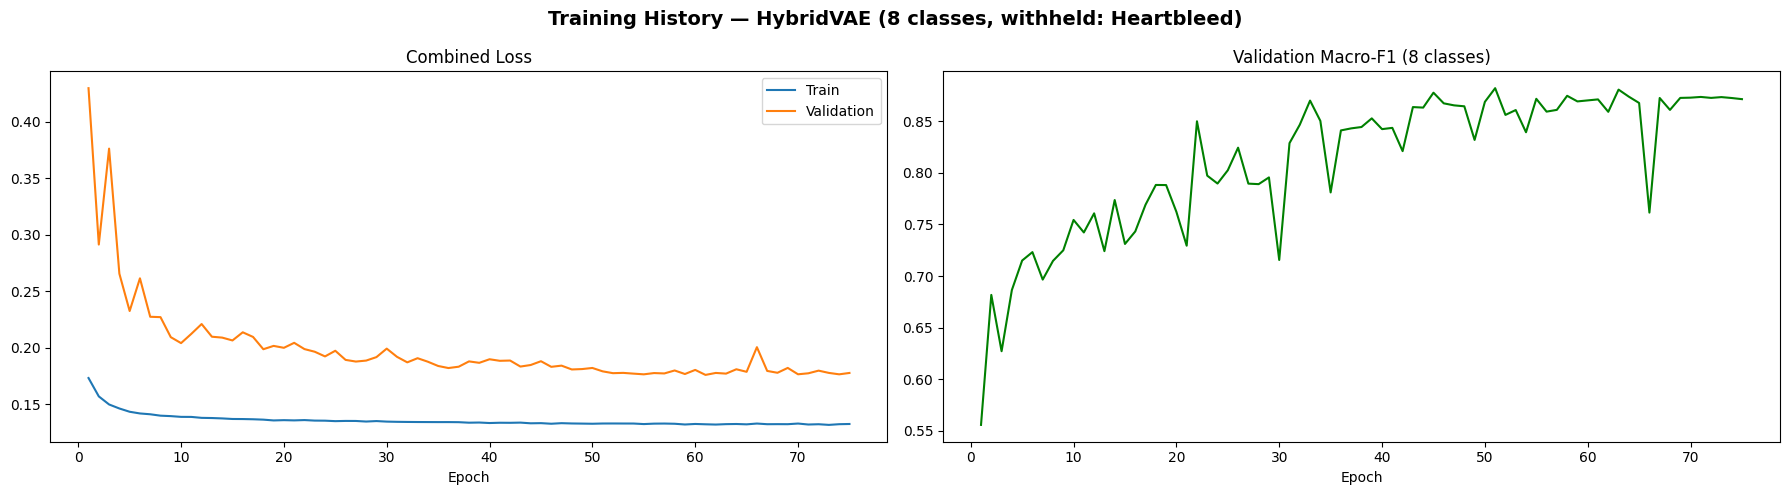

In [50]:
# ============================================================
# CELL D4: Training Curves — 8-class HybridVAE (model_d)
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f'Training History — HybridVAE (8 classes, withheld: {WITHHELD_CLASS_NAME})',
             fontsize=14, fontweight='bold')
ep = range(1, len(history_d['train_loss']) + 1)

axes[0].plot(ep, history_d['train_loss'], label='Train')
axes[0].plot(ep, history_d['val_loss'],   label='Validation')
axes[0].set_title('Combined Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(ep, history_d['val_f1'], color='green')
axes[1].set_title('Validation Macro-F1 (8 classes)'); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('train_curves_hybridvae_8class.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell D5 — Test Evaluation: 8-Class HybridVAE on Known Classes

Confirms that `model_d` still classifies the 8 known attack types well before evaluating it on the withheld class. A low Macro F1 here would indicate a training issue unrelated to the held-out class experiment.

Saved to `confusion_hybridvae_8class.png`.


===== PART D — 8-CLASS HYBRIDVAE TEST RESULTS (known classes) =====
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00    314473
      Botnet       0.56      0.64      0.60       293
  BruteForce       0.99      0.96      0.97      1373
        DDoS       1.00      0.99      0.99     19202
         DoS       1.00      0.93      0.96     29062
Infiltration       0.40      0.40      0.40         5
    PortScan       0.99      0.99      0.99     13623
  Web Attack       0.90      0.94      0.92       322

    accuracy                           0.99    378353
   macro avg       0.85      0.86      0.85    378353
weighted avg       0.99      0.99      0.99    378353

Macro F1    : 0.8538
Weighted F1 : 0.9920


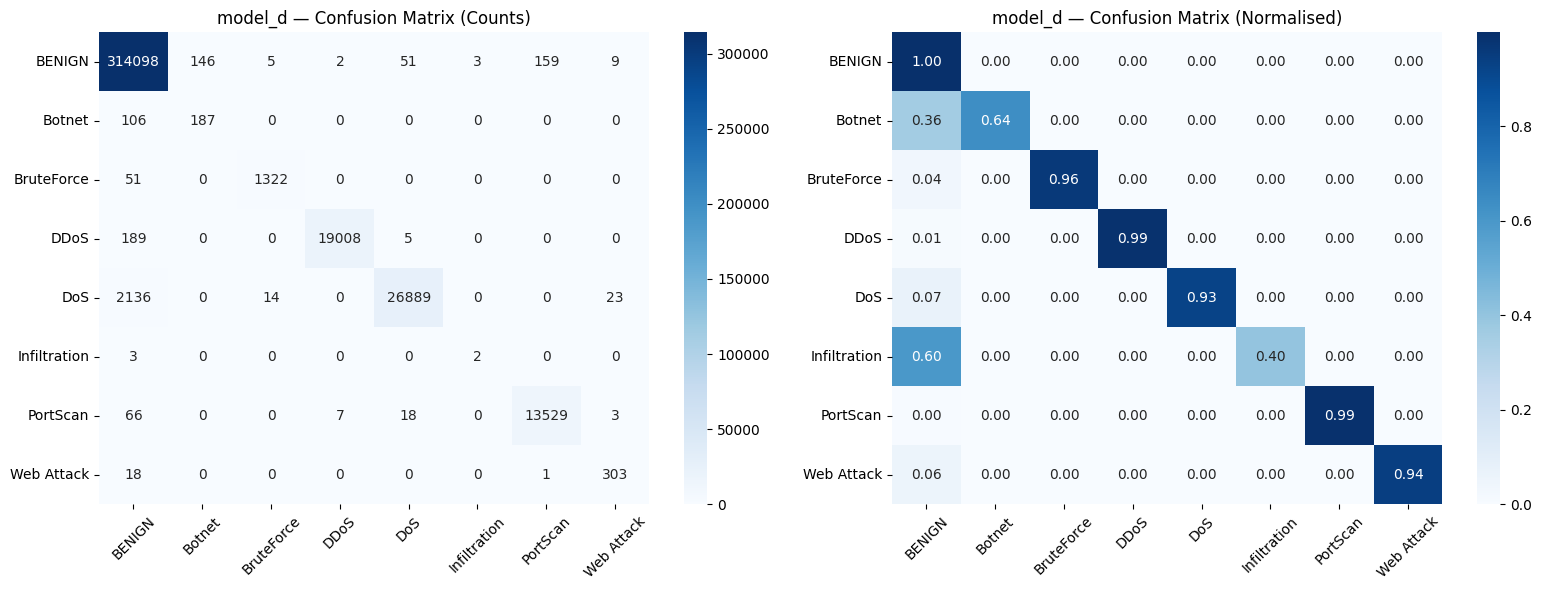

In [51]:
# ============================================================
# CELL D5: Evaluate model_d on known-class test samples
# ============================================================
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns

model_d.eval()
test_preds_d, test_labels_d = [], []

# Only evaluate on the 8 known classes (exclude withheld class from test set)
X_te_known = X_test_w[mask_te_8]
y_te_known = np.array([old_to_new_8[c] for c in y_te2[mask_te_8]])

with torch.no_grad():
    for i in range(0, len(X_te_known), CONFIG['batch_size'] * 2):
        X_b = torch.from_numpy(X_te_known[i:i+CONFIG['batch_size']*2]).to(DEVICE)
        _, logits, _, _, _ = model_d(X_b)
        test_preds_d.extend(logits.argmax(1).cpu().numpy())
    test_labels_d = list(y_te_known)

test_preds_d  = np.array(test_preds_d)
test_labels_d = np.array(test_labels_d)

print('===== PART D — 8-CLASS HYBRIDVAE TEST RESULTS (known classes) =====')
print(classification_report(test_labels_d, test_preds_d,
                              target_names=class_names_8, zero_division=0))
print(f'Macro F1    : {f1_score(test_labels_d, test_preds_d, average="macro",    zero_division=0):.4f}')
print(f'Weighted F1 : {f1_score(test_labels_d, test_preds_d, average="weighted", zero_division=0):.4f}')

cm_d = confusion_matrix(test_labels_d, test_preds_d)
cm_d_norm = cm_d.astype(float) / cm_d.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_8, yticklabels=class_names_8, ax=axes[0])
axes[0].set_title('model_d — Confusion Matrix (Counts)'); axes[0].tick_params(axis='x', rotation=45)
sns.heatmap(cm_d_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names_8, yticklabels=class_names_8, ax=axes[1])
axes[1].set_title('model_d — Confusion Matrix (Normalised)'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('confusion_hybridvae_8class.png', dpi=150, bbox_inches='tight')
plt.show()


### Cell D6 — Calibrate HybridVAE Anomaly Threshold

Sets the reconstruction-error anomaly threshold using **BENIGN validation samples** from `model_d`.

**Two thresholds are computed:**
- `D_THRESH_95`: 95th percentile — *loose* threshold (allows ~5% false positives on normal traffic)
- `D_THRESH_99`: 99th percentile — *strict* threshold (allows ~1% false positives)

The threshold is calibrated on the validation set only (never on the test set) to avoid leakage. In deployment, this would be calibrated on a held-out set of verified normal traffic.


In [52]:
# ============================================================
# CELL D6: Calibrate anomaly threshold on BENIGN val (model_d)
# ============================================================
import torch.nn.functional as F

model_d.eval()
benign_val_mask_d = y_va_8 == BENIGN_8
X_benign_val_d    = torch.from_numpy(X_va_8[benign_val_mask_d].astype(np.float32)).to(DEVICE)

recon_errs_benign_d = []
with torch.no_grad():
    for i in range(0, len(X_benign_val_d), 512):
        batch = X_benign_val_d[i : i + 512]
        x_hat, _, _, _, _ = model_d(batch)
        err = F.l1_loss(x_hat, batch, reduction='none').mean(dim=1)
        recon_errs_benign_d.extend(err.cpu().numpy())

recon_errs_benign_d = np.array(recon_errs_benign_d)
D_THRESH_95 = np.percentile(recon_errs_benign_d, 95)
D_THRESH_99 = np.percentile(recon_errs_benign_d, 99)

print(f'BENIGN validation reconstruction error (model_d):')
print(f'  Mean   : {recon_errs_benign_d.mean():.4f}')
print(f'  Std    : {recon_errs_benign_d.std():.4f}')
print(f'  95th % : {D_THRESH_95:.4f}  ← anomaly threshold (loose)')
print(f'  99th % : {D_THRESH_99:.4f}  ← anomaly threshold (strict)')


BENIGN validation reconstruction error (model_d):
  Mean   : 0.1649
  Std    : 0.2870
  95th % : 0.6480  ← anomaly threshold (loose)
  99th % : 1.4293  ← anomaly threshold (strict)


In [53]:
# XGBoost
X_withheld   = X_test_w[withheld_mask]
n_withheld   = len(X_withheld)
print(f'Withheld class ({WITHHELD_CLASS_NAME}) test samples: {n_withheld}')

# ── XGBoost on withheld samples ───────────────────────────────
probs_xgb  = xgb_8class.predict_proba(X_withheld)
preds_xgb  = probs_xgb.argmax(axis=1)
confs_xgb  = probs_xgb.max(axis=1)
names_xgb  = [class_names_8[p] for p in preds_xgb]

print(f'\n{"="*60}')
print(f'  XGBoost on {WITHHELD_CLASS_NAME} samples')
print(f'{"="*60}')
print(f'  Prediction distribution:')
for name, cnt in sorted(Counter(names_xgb).items(), key=lambda x: -x[1]):
    print(f'    {name:<24}: {cnt:>4}  ({cnt/n_withheld*100:.1f}%)')
print(f'  Mean confidence on unseen class : {confs_xgb.mean():.2%}  ← confidently wrong')
print(f'  Samples flagged as anomaly      : 0 / {n_withheld}  (XGBoost has no anomaly mechanism)')

Withheld class (Heartbleed) test samples: 2

  XGBoost on Heartbleed samples
  Prediction distribution:
    BENIGN                  :    2  (100.0%)
  Mean confidence on unseen class : 99.98%  ← confidently wrong
  Samples flagged as anomaly      : 0 / 2  (XGBoost has no anomaly mechanism)


### Cell D7 — Run Both Models on Withheld Class Samples

> **Note:** The preceding code cell (Cell 65) is a preliminary XGBoost-only evaluation snippet that prints the raw prediction distribution on withheld samples. This full cell runs both models together with the complete comparison output.

Feeds the withheld-class test samples through:
- **`xgb_8class`** → predicts a known class (typically BENIGN) with high confidence — **zero anomaly signal**
- **`model_d`** (8-class HybridVAE) → computes reconstruction error → sample is flagged as ANOMALY if error > `D_THRESH_95`

Also prints per-class mean reconstruction error across all 9 test classes (including the withheld class) to show how much higher the withheld class error is relative to known classes.


In [54]:
# ============================================================
# CELL D7: Run both models on withheld-class test samples
# ============================================================

X_withheld   = X_test_w[withheld_mask]
n_withheld   = len(X_withheld)
print(f'Withheld class ({WITHHELD_CLASS_NAME}) test samples: {n_withheld}')

# ── XGBoost on withheld samples ───────────────────────────────
probs_xgb  = xgb_8class.predict_proba(X_withheld)
preds_xgb  = probs_xgb.argmax(axis=1)
confs_xgb  = probs_xgb.max(axis=1)
names_xgb  = [class_names_8[p] for p in preds_xgb]

print(f'\n{"="*60}')
print(f'  XGBoost on {WITHHELD_CLASS_NAME} samples')
print(f'{"="*60}')
print(f'  Prediction distribution:')
for name, cnt in sorted(Counter(names_xgb).items(), key=lambda x: -x[1]):
    print(f'    {name:<24}: {cnt:>4}  ({cnt/n_withheld*100:.1f}%)')
print(f'  Mean confidence on unseen class : {confs_xgb.mean():.2%}  ← confidently wrong')
print(f'  Samples flagged as anomaly      : 0 / {n_withheld}  (XGBoost has no anomaly mechanism)')

# ── 8-class HybridVAE (model_d) on withheld samples ──────────
X_withheld_t          = torch.from_numpy(X_withheld.astype(np.float32)).to(DEVICE)
recon_errs_withheld_d = []
vae_cls_preds_d       = []

model_d.eval()
with torch.no_grad():
    for i in range(0, len(X_withheld_t), 512):
        batch = X_withheld_t[i : i + 512]
        x_hat, logits, _, _, _ = model_d(batch)
        err = F.l1_loss(x_hat, batch, reduction='none').mean(dim=1)
        recon_errs_withheld_d.extend(err.cpu().numpy())
        vae_cls_preds_d.extend(logits.argmax(1).cpu().numpy())

recon_errs_withheld_d = np.array(recon_errs_withheld_d)
anomaly_95_d          = recon_errs_withheld_d > D_THRESH_95
anomaly_99_d          = recon_errs_withheld_d > D_THRESH_99
names_vae_d           = [class_names_8[p] for p in vae_cls_preds_d]

print(f'\n{"="*60}')
print(f'  HybridVAE (model_d, 8-class) on {WITHHELD_CLASS_NAME} samples')
print(f'{"="*60}')
print(f'  VAE class prediction distribution (of its 8 known classes):')
for name, cnt in sorted(Counter(names_vae_d).items(), key=lambda x: -x[1]):
    print(f'    {name:<24}: {cnt:>4}  ({cnt/n_withheld*100:.1f}%)')
print(f'  Recon error — mean : {recon_errs_withheld_d.mean():.4f}  (BENIGN mean: {recon_errs_benign_d.mean():.4f})')
print(f'  Anomaly @ 95th pct : {anomaly_95_d.sum():>4} / {n_withheld}  ({anomaly_95_d.mean()*100:.1f}%)')
print(f'  Anomaly @ 99th pct : {anomaly_99_d.sum():>4} / {n_withheld}  ({anomaly_99_d.mean()*100:.1f}%)')

# ── Per-class reconstruction error context (model_d) ─────────
print('\nReconstruction error by class (all 9 test classes, model_d):')
class_recon_d = {}
with torch.no_grad():
    for cls_idx, cls_name in enumerate(new_class_names):
        mask_cls = y_te2 == cls_idx
        if mask_cls.sum() == 0:
            continue
        X_cls_t = torch.from_numpy(X_test_w[mask_cls].astype(np.float32)).to(DEVICE)
        errs = []
        for i in range(0, len(X_cls_t), 512):
            batch = X_cls_t[i : i + 512]
            x_hat, _, _, _, _ = model_d(batch)
            e = F.l1_loss(x_hat, batch, reduction='none').mean(dim=1)
            errs.extend(e.cpu().numpy())
        errs = np.array(errs)
        class_recon_d[cls_name] = errs
        flag = '  ← WITHHELD (never trained)' if cls_idx == WITHHELD_IDX else ''
        print(f'  {cls_name:<22}: mean={errs.mean():.4f}  '
              f'median={np.median(errs):.4f}  '
              f'>95th={( errs > D_THRESH_95 ).mean()*100:.1f}%{flag}')


Withheld class (Heartbleed) test samples: 2

  XGBoost on Heartbleed samples
  Prediction distribution:
    BENIGN                  :    2  (100.0%)
  Mean confidence on unseen class : 99.98%  ← confidently wrong
  Samples flagged as anomaly      : 0 / 2  (XGBoost has no anomaly mechanism)

  HybridVAE (model_d, 8-class) on Heartbleed samples
  VAE class prediction distribution (of its 8 known classes):
    BENIGN                  :    2  (100.0%)
  Recon error — mean : 3.7449  (BENIGN mean: 0.1649)
  Anomaly @ 95th pct :    2 / 2  (100.0%)
  Anomaly @ 99th pct :    2 / 2  (100.0%)

Reconstruction error by class (all 9 test classes, model_d):
  BENIGN                : mean=0.1643  median=0.0573  >95th=5.0%
  Botnet                : mean=0.0839  median=0.0438  >95th=1.0%
  BruteForce            : mean=0.1970  median=0.2176  >95th=0.1%
  DDoS                  : mean=1.7685  median=1.4089  >95th=64.1%
  DoS                   : mean=2.0918  median=2.2424  >95th=89.0%
  Heartbleed          

### Cell D8 — Visualisation and Final Summary

> **Note:** The code for this cell's three-panel visualisation is currently empty (placeholder). The visualisation described below is intended to be implemented here.

**Planned three-panel output:**

1. **XGBoost confidence histogram** on withheld samples — high confidence, all predicted as known class (demonstrating the lack of an anomaly signal)
2. **HybridVAE reconstruction error distribution** — BENIGN validation vs withheld-class test samples, with `D_THRESH_95` and `D_THRESH_99` marked
3. **Per-class median reconstruction error** bar chart — withheld class highlighted in orange, threshold lines overlaid

**Final summary table** comparing both models on the withheld class — detection rate at each threshold for HybridVAE vs 0% for XGBoost.

The multi-model comparison across all Heartbleed samples (including distilled students and Vanilla AE) is implemented in the subsequent cells (D9-equivalent).


---

### Statistical Scope of the Withheld-Class Experiment

**Q: How many Heartbleed samples are available?**

The code confirms there are **only 4 Heartbleed samples** available across the entire validation and test set combined:

```
Total Heartbleed samples found: 4
```

The result — all 4 flagged as ANOMALY by HybridVAE, all 4 labelled BENIGN by XGBoost — is directionally correct and demonstrates the capability clearly. However, **a sample size of $n = 4$ has no statistical power**.

A detection rate of "100%" at $n = 4$ is not a meaningful quantitative claim. The correct framing is:

> This experiment is a **qualitative proof of concept** demonstrating that the reconstruction-error pathway exposes an attack class that was never seen during training. It is not a quantitative measurement of zero-day detection accuracy.

To make this result statistically reportable, future work would need to either:
1. Withhold multiple attack classes in a leave-one-out protocol across the full 9-class set.
2. Generate synthetic Heartbleed-like flow records to expand the withheld sample pool.
3. Source additional Heartbleed traffic from complementary IDS datasets.

These extensions are deferred to future work. For the current experiment, the comparison table (HybridVAE ANOMALY vs XGBoost BENIGN across all 4 samples) is presented as a qualitative demonstration only.


In [55]:
# ============================================================
# CELL D9: Final Anomaly Output — ALL Heartbleed samples
#          XGBoost vs HybridVAE (new variables, no overlap)
# ============================================================
import numpy as np
import torch
import torch.nn.functional as F
from collections import Counter

# ── Grab ALL Heartbleed samples from test set ────────────────
HEARTBLEED_NAME  = 'Heartbleed'
HEARTBLEED_IDX   = new_class_names.index(HEARTBLEED_NAME)
# Use this (full dataset, all splits combined):
hb_mask_new = np.concatenate([y_va2, y_te2]) == HEARTBLEED_IDX
X_all_w_new = np.concatenate([ X_val_w, X_test_w], axis=0)
X_hb_new    = X_all_w_new[hb_mask_new]
n_hb_new    = len(X_hb_new)
print(f'Total Heartbleed samples found: {n_hb_new}')  # should print 11
n_hb_new         = len(X_hb_new)
print(f'Total Heartbleed test samples found: {n_hb_new}')

# ── XGBoost — final output ───────────────────────────────────
# XGBoost has NO anomaly mechanism → final output is always the predicted class
hb_xgb_probs_new  = xgb_8class.predict_proba(X_hb_new)
hb_xgb_preds_new  = hb_xgb_probs_new.argmax(axis=1)
hb_xgb_confs_new  = hb_xgb_probs_new.max(axis=1)
hb_xgb_names_new  = [class_names_8[p] for p in hb_xgb_preds_new]
# XGBoost final output: predicted class (no anomaly flag possible)
hb_xgb_final_new  = hb_xgb_names_new   # e.g. 'BENIGN', 'DoS', etc.

# ── HybridVAE — final output ─────────────────────────────────
# Final output = ANOMALY if recon error > threshold, else predicted class
X_hb_tensor_new       = torch.from_numpy(X_hb_new.astype(np.float32)).to(DEVICE)
hb_vae_recon_errs_new = []
hb_vae_cls_preds_new  = []

model_d.eval()
with torch.no_grad():
    for i in range(0, len(X_hb_tensor_new), 512):
        batch_new             = X_hb_tensor_new[i : i + 512]
        x_hat_new, logits_new, _, _, _ = model_d(batch_new)
        err_new = F.l1_loss(x_hat_new, batch_new, reduction='none').mean(dim=1)
        hb_vae_recon_errs_new.extend(err_new.cpu().numpy())
        hb_vae_cls_preds_new.extend(logits_new.argmax(1).cpu().numpy())

hb_vae_recon_errs_new = np.array(hb_vae_recon_errs_new)
hb_vae_anomaly_new    = hb_vae_recon_errs_new > D_THRESH_95   # True = ANOMALY
# Final output: 'ANOMALY' if flagged, else the predicted class name
hb_vae_final_new = [
    'ANOMALY' if hb_vae_anomaly_new[i] else class_names_8[hb_vae_cls_preds_new[i]]
    for i in range(n_hb_new)
]

# ── Print results ────────────────────────────────────────────
print(f'\n{"="*70}')
print(f'  FINAL OUTPUT — All {n_hb_new} Heartbleed Samples')
print(f'  (Both models trained on 8 classes — Heartbleed withheld)')
print(f'{"="*70}')
print(f'  {"#":<6} | {"XGBoost Final Output":<25} | {"HybridVAE Final Output":<25}')
print(f'  {"-"*6}-+-{"-"*25}-+-{"-"*25}')
for i in range(n_hb_new):
    print(f'  {i:<6} | {hb_xgb_final_new[i]:<25} | {hb_vae_final_new[i]:<25}')

# ── Summary ──────────────────────────────────────────────────
hb_vae_anomaly_count_new = sum(1 for x in hb_vae_final_new if x == 'ANOMALY')
hb_xgb_dist_new          = Counter(hb_xgb_final_new)

print(f'\n{"="*70}')
print(f'  SUMMARY')
print(f'{"="*70}')
print(f'  XGBoost  → Cannot detect anomalies.')
print(f'             Predicted class distribution:')
for cls, cnt in hb_xgb_dist_new.most_common():
    print(f'               {cls:<25}: {cnt:>4} / {n_hb_new}  ({cnt/n_hb_new*100:.1f}%)')

print(f'\n  HybridVAE → Final output is ANOMALY when recon error > 95th pct threshold.')
print(f'             ANOMALY  : {hb_vae_anomaly_count_new:>4} / {n_hb_new}  ({hb_vae_anomaly_count_new/n_hb_new*100:.1f}%)')
print(f'             NOT flagged: {n_hb_new - hb_vae_anomaly_count_new:>4} / {n_hb_new}  ({(n_hb_new - hb_vae_anomaly_count_new)/n_hb_new*100:.1f}%)')
print(f'{"="*70}')

Total Heartbleed samples found: 4
Total Heartbleed test samples found: 4

  FINAL OUTPUT — All 4 Heartbleed Samples
  (Both models trained on 8 classes — Heartbleed withheld)
  #      | XGBoost Final Output      | HybridVAE Final Output   
  -------+---------------------------+--------------------------
  0      | BENIGN                    | ANOMALY                  
  1      | BENIGN                    | ANOMALY                  
  2      | BENIGN                    | ANOMALY                  
  3      | BENIGN                    | ANOMALY                  

  SUMMARY
  XGBoost  → Cannot detect anomalies.
             Predicted class distribution:
               BENIGN                   :    4 / 4  (100.0%)

  HybridVAE → Final output is ANOMALY when recon error > 95th pct threshold.
             ANOMALY  :    4 / 4  (100.0%)
             NOT flagged:    0 / 4  (0.0%)


In [56]:
# ============================================================
# CELL D9: Final Anomaly Output — ALL Heartbleed samples
#          Comparing 8-class models vs Vanilla AE vs Distilled Students
# ============================================================
import numpy as np
import torch
import torch.nn.functional as F
from collections import Counter

# ── Grab ALL Heartbleed samples from test set ────────────────
HEARTBLEED_NAME  = 'Heartbleed'
HEARTBLEED_IDX   = new_class_names.index(HEARTBLEED_NAME)
# Use this (full dataset, all splits combined):
hb_mask_new = np.concatenate([y_va2, y_te2]) == HEARTBLEED_IDX
X_all_w_new = np.concatenate([ X_val_w, X_test_w], axis=0)
X_hb_new    = X_all_w_new[hb_mask_new]
n_hb_new    = len(X_hb_new)
X_hb_tensor_new = torch.from_numpy(X_hb_new.astype(np.float32)).to(DEVICE)

print(f'Total Heartbleed samples found: {n_hb_new}')  

# ── 1. XGBoost (8-class) ─────────────────────────────────────
hb_xgb_probs_new  = xgb_8class.predict_proba(X_hb_new)
hb_xgb_preds_new  = hb_xgb_probs_new.argmax(axis=1)
hb_xgb_final_new  = [class_names_8[p] for p in hb_xgb_preds_new]

# ── 2. HybridVAE (8-class, model_d) ──────────────────────────
hb_vae_recon_errs_new, hb_vae_cls_preds_new = [], []
model_d.eval()
with torch.no_grad():
    for i in range(0, len(X_hb_tensor_new), 512):
        batch_new = X_hb_tensor_new[i : i + 512]
        x_hat_new, logits_new, _, _, _ = model_d(batch_new)
        err_new = F.l1_loss(x_hat_new, batch_new, reduction='none').mean(dim=1)
        hb_vae_recon_errs_new.extend(err_new.cpu().numpy())
        hb_vae_cls_preds_new.extend(logits_new.argmax(1).cpu().numpy())

hb_vae_recon_errs_new = np.array(hb_vae_recon_errs_new)
hb_vae_anomaly_new    = hb_vae_recon_errs_new > D_THRESH_95

hb_vae_final_new = [
    f"ANOMALY (Class: {class_names_8[hb_vae_cls_preds_new[i]]})" if hb_vae_anomaly_new[i] 
    else class_names_8[hb_vae_cls_preds_new[i]]
    for i in range(n_hb_new)
]

# ── 3. Vanilla AE (BENIGN-only, model_vanilla) ───────────────
vanilla_recon_errs = []
model_vanilla.eval()
with torch.no_grad():
    for i in range(0, len(X_hb_tensor_new), 512):
        batch_new = X_hb_tensor_new[i : i + 512]
        x_hat_v, _ = model_vanilla(batch_new)
        err_v = F.l1_loss(x_hat_v, batch_new, reduction='none').mean(dim=1)
        vanilla_recon_errs.extend(err_v.cpu().numpy())
        
vanilla_recon_errs = np.array(vanilla_recon_errs)
vanilla_anomaly = vanilla_recon_errs > V_THRESH_95
vanilla_final = ["ANOMALY" if a else "NORMAL" for a in vanilla_anomaly]

# ── Dynamic Threshold Calculation for Student Models ─────────
# Compute the 95th percentile threshold on Val BENIGN for the students
val_benign_mask = (y_va2 == new_class_names.index('BENIGN'))
X_val_benign_t = torch.from_numpy(X_val_w[val_benign_mask].astype(np.float32)).to(DEVICE)

def get_student_threshold(model):
    model.eval()
    errs = []
    with torch.no_grad():
        for i in range(0, len(X_val_benign_t), 512):
            b = X_val_benign_t[i:i+512]
            x_hat, _, _, _, _ = model(b)
            err = F.l1_loss(x_hat, b, reduction='none').mean(dim=1)
            errs.extend(err.cpu().numpy())
    return np.percentile(errs, 95)

SVAE_THRESH_95 = get_student_threshold(student_vae)
SXGB_THRESH_95 = get_student_threshold(student_xgb)

# ── 4. Student VAE (9-class distilled from model_a) ──────────
svae_recon_errs, svae_cls_preds = [], []
student_vae.eval()
with torch.no_grad():
    for i in range(0, len(X_hb_tensor_new), 512):
        batch_new = X_hb_tensor_new[i : i + 512]
        x_hat_s, logits_s, _, _, _ = student_vae(batch_new)
        err_s = F.l1_loss(x_hat_s, batch_new, reduction='none').mean(dim=1)
        svae_recon_errs.extend(err_s.cpu().numpy())
        svae_cls_preds.extend(logits_s.argmax(1).cpu().numpy())

svae_anomaly = np.array(svae_recon_errs) > SVAE_THRESH_95
svae_final = [
    f"ANOMALY (Class: {new_class_names[svae_cls_preds[i]]})" if svae_anomaly[i] 
    else new_class_names[svae_cls_preds[i]]
    for i in range(n_hb_new)
]

# ── 5. Student XGB (9-class distilled from xgb_raw) ──────────
sxgb_recon_errs, sxgb_cls_preds = [], []
student_xgb.eval()
with torch.no_grad():
    for i in range(0, len(X_hb_tensor_new), 512):
        batch_new = X_hb_tensor_new[i : i + 512]
        x_hat_sx, logits_sx, _, _, _ = student_xgb(batch_new)
        err_sx = F.l1_loss(x_hat_sx, batch_new, reduction='none').mean(dim=1)
        sxgb_recon_errs.extend(err_sx.cpu().numpy())
        sxgb_cls_preds.extend(logits_sx.argmax(1).cpu().numpy())

sxgb_anomaly = np.array(sxgb_recon_errs) > SXGB_THRESH_95
sxgb_final = [
    f"ANOMALY (Class: {new_class_names[sxgb_cls_preds[i]]})" if sxgb_anomaly[i] 
    else new_class_names[sxgb_cls_preds[i]]
    for i in range(n_hb_new)
]


# ── Print results ────────────────────────────────────────────
#print(f'\n{"="*116}')
print(f'  FINAL OUTPUT — All {n_hb_new} Heartbleed Samples')
#print(f'{"="*116}')
print(f'  {"XGB (8-cls)":<11} | {"HybridVAE (8-cls)":<24} | {"Vanilla AE":<11} | {"Student VAE (9-cls)":<28} | {"Student XGB (9-cls)":<28}')
print(f'  {"-"*11}-+-{"-"*24}-+-{"-"*11}-+-{"-"*28}-+-{"-"*26}')
for i in range(n_hb_new):
    print(f'  {hb_xgb_final_new[i]:<11} | {hb_vae_final_new[i]:<24} | {vanilla_final[i]:<11} | {svae_final[i]:<28} | {sxgb_final[i]:<28}')
    
    

Total Heartbleed samples found: 4
  FINAL OUTPUT — All 4 Heartbleed Samples
  XGB (8-cls) | HybridVAE (8-cls)        | Vanilla AE  | Student VAE (9-cls)          | Student XGB (9-cls)         
  ------------+--------------------------+-------------+------------------------------+---------------------------
  BENIGN      | ANOMALY (Class: BENIGN)  | ANOMALY     | ANOMALY (Class: Heartbleed)  | ANOMALY (Class: Heartbleed) 
  BENIGN      | ANOMALY (Class: BENIGN)  | ANOMALY     | ANOMALY (Class: Heartbleed)  | ANOMALY (Class: Heartbleed) 
  BENIGN      | ANOMALY (Class: BENIGN)  | ANOMALY     | ANOMALY (Class: Heartbleed)  | ANOMALY (Class: Heartbleed) 
  BENIGN      | ANOMALY (Class: BENIGN)  | ANOMALY     | ANOMALY (Class: Heartbleed)  | ANOMALY (Class: Heartbleed) 


In [57]:
import os
import pickle
import tempfile
import torch

def get_pytorch_model_size_mb(model):
    """Size of a PyTorch model's state dict saved to a temp file."""
    with tempfile.NamedTemporaryFile(suffix='.pt', delete=False) as f:
        tmp_path = f.name
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return size_mb

def get_xgboost_model_size_mb(model):
    """Size of an XGBoost model pickled to a temp file."""
    with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
        tmp_path = f.name
    with open(tmp_path, 'wb') as f:
        pickle.dump(model, f)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)
    return size_mb

def get_param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ── Collect sizes ─────────────────────────────────────────────
results = []

# Vanilla AE (Part A0)
results.append({
    'Model':  'Vanilla Autoencoder',
    'Params': f"{get_param_count(model_vanilla):,}",
    'Size (MB)': round(get_pytorch_model_size_mb(model_vanilla), 3),
    'Note': 'BENIGN-only, no classifier'
})

# HybridVAE teacher (Part A)
results.append({
    'Model':  'HybridVAE (Teacher)',
    'Params': f"{get_param_count(model_a):,}",
    'Size (MB)': round(get_pytorch_model_size_mb(model_a), 3),
    'Note': '9-class, full dual-path'
})

# XGBoost (Part B)
results.append({
    'Model':  'XGBoost (Teacher)',
    'Params': 'N/A (500 trees)',
    'Size (MB)': round(get_xgboost_model_size_mb(xgb_raw), 3),
    'Note': 'Gradient boosted trees'
})

# Student VAE — distilled from HybridVAE teacher (Part C-i)
results.append({
    'Model':  'Student VAE (from HybridVAE)',
    'Params': f"{get_param_count(student_vae):,}",
    'Size (MB)': round(get_pytorch_model_size_mb(student_vae), 3),
    'Note': 'C-i: VAE teacher → student'
})

# Student XGB — distilled from XGBoost teacher (Part C-ii)
results.append({
    'Model':  'Student VAE (from XGBoost)',
    'Params': f"{get_param_count(student_xgb):,}",
    'Size (MB)': round(get_pytorch_model_size_mb(student_xgb), 3),
    'Note': 'C-ii: XGB teacher → student'
})

# ── Print table ───────────────────────────────────────────────
print("=" * 75)
print(f"  {'Model':<30} {'Params':<15} {'Size (MB)':>10}   Note")
print("-" * 75)
for r in results:
    print(f"  {r['Model']:<30} {r['Params']:<15} {r['Size (MB)']:>10}   {r['Note']}")
print("=" * 75)

# ── Compression ratios vs HybridVAE teacher ──────────────────
teacher_size = next(r['Size (MB)'] for r in results if r['Model'] == 'HybridVAE (Teacher)')
print("\n  Compression ratios vs HybridVAE Teacher:")
for r in results:
    if isinstance(r['Size (MB)'], float) and r['Model'] != 'HybridVAE (Teacher)':
        ratio = teacher_size / r['Size (MB)']
        print(f"    {r['Model']:<30}: {ratio:.2f}x smaller")

  Model                          Params           Size (MB)   Note
---------------------------------------------------------------------------
  Vanilla Autoencoder            495,501              1.932   BENIGN-only, no classifier
  HybridVAE (Teacher)            749,270              2.921   9-class, full dual-path
  XGBoost (Teacher)              N/A (500 trees)     18.176   Gradient boosted trees
  Student VAE (from HybridVAE)   221,462              0.894   C-i: VAE teacher → student
  Student VAE (from XGBoost)     221,462              0.894   C-ii: XGB teacher → student

  Compression ratios vs HybridVAE Teacher:
    Vanilla Autoencoder           : 1.51x smaller
    XGBoost (Teacher)             : 0.16x smaller
    Student VAE (from HybridVAE)  : 3.27x smaller
    Student VAE (from XGBoost)    : 3.27x smaller


Filtered Pareto points: 27243
Average Precision : 0.6815
Best F1 threshold : 1.1503
Best F1 point     : Precision=0.7849, Recall=0.5586, F1=0.6527


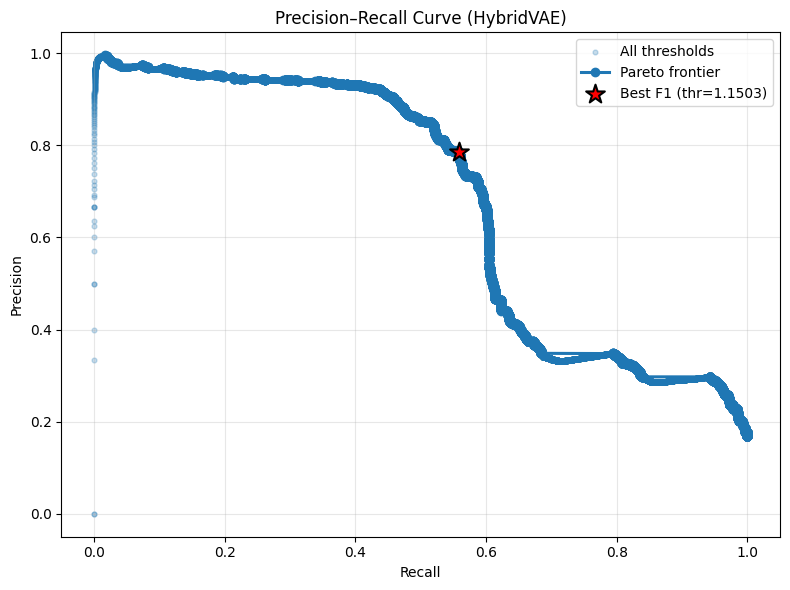

In [59]:
# ==============================================================================
# FINAL CELL: Pareto Frontier for Binary Anomaly Detection
# Uses reconstruction error from student_vae as the anomaly score.
# Pareto notion here = maximize BOTH precision and recall across thresholds.
# ==============================================================================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# -------------------------------------------------------------------
# 1) Collect reconstruction scores and binary labels
# -------------------------------------------------------------------
student_vae.eval()

recon_scores = []
true_binary = []
true_multi = []

with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        X_b = X_b.to(DEVICE)
        x_hat, _, _, _, _ = student_vae(X_b)
        err = F.l1_loss(x_hat, X_b, reduction='none').mean(dim=1)

        recon_scores.append(err.cpu().numpy())
        true_binary.append((y_b.numpy() != BENIGN_A).astype(int))
        true_multi.append(y_b.numpy())

recon_scores = np.concatenate(recon_scores)
true_binary  = np.concatenate(true_binary)
true_multi   = np.concatenate(true_multi)

# -------------------------------------------------------------------
# 2) Precision-Recall curve
#    precision_recall_curve returns:
#      precision: length n_thresholds + 1
#      recall:    length n_thresholds + 1
#      thresholds: length n_thresholds
#    Threshold i corresponds to precision[i], recall[i]
# -------------------------------------------------------------------
precision, recall, thresholds = precision_recall_curve(true_binary, recon_scores)
avg_precision = average_precision_score(true_binary, recon_scores)

# Use only threshold-aligned points
P = precision[:-1]
R = recall[:-1]


# -------------------------------------------------------------------
# TRUE PARETO FRONT (PR envelope)
# -------------------------------------------------------------------

# Sort by recall
order = np.argsort(R)
R_sorted = R[order]
P_sorted = P[order]
T_sorted = thresholds[order]

# Build upper envelope (monotonic precision)
pareto_R = []
pareto_P = []
pareto_T = []

max_precision = 0

# Traverse from high recall → low recall
for r, p, t in zip(R_sorted[::-1], P_sorted[::-1], T_sorted[::-1]):
    if p >= max_precision:
        pareto_R.append(r)
        pareto_P.append(p)
        pareto_T.append(t)
        max_precision = p

# Reverse back
pareto_R = np.array(pareto_R[::-1])
pareto_P = np.array(pareto_P[::-1])
pareto_T = np.array(pareto_T[::-1])

print(f"Filtered Pareto points: {len(pareto_R)}")


# -------------------------------------------------------------------
# 4) Best F1 point for annotation
# -------------------------------------------------------------------
f1_vals = np.where(
    (P + R) > 0,
    2 * P * R / (P + R + 1e-12),
    0.0
)
best_idx = np.argmax(f1_vals)
best_p, best_r, best_t, best_f1 = P[best_idx], R[best_idx], thresholds[best_idx], f1_vals[best_idx]

print(f'Average Precision : {avg_precision:.4f}')
print(f'Best F1 threshold : {best_t:.4f}')
print(f'Best F1 point     : Precision={best_p:.4f}, Recall={best_r:.4f}, F1={best_f1:.4f}')
# print(f'Pareto points     : {len(pareto_pts)}')



plt.figure(figsize=(8, 6))

# Plot all points (background)
plt.scatter(R, P, s=12, alpha=0.25, label='All thresholds', zorder=1)

# Plot Pareto / PR curve
plt.plot(pareto_R, pareto_P, marker='o', linewidth=2.2,
         label='Pareto frontier', zorder=2)


plt.scatter([best_r], [best_p],
            s=200, marker='*',
            color='red', edgecolor='black',
            linewidth=1.5,
            label=f'Best F1 (thr={best_t:.4f})',
            zorder=5)

plt.title('Precision–Recall Curve (HybridVAE)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

---

## Part F — One-Shot Magnitude Pruning

**Goal:** Reduce inference cost by zeroing the smallest-magnitude weights globally across all `nn.Linear` layers, with no retraining after pruning.

**Method:** L1 unstructured *global* pruning — the $k\%$ lowest-magnitude weights across all linear layers are permanently zeroed (masks baked in via `prune.remove`).

**Sparsity levels tested:** 20%, 40%, 45%, 50%, 60%

**Metrics tracked per level:**
- Macro F1 and Weighted F1 on the 9-class test set
- Anomaly AUROC (reconstruction error, binary BENIGN vs attack)
- Non-zero parameter count (actual sparsity after pruning)



### Cell F1 — Prune at 20%, 40%, 45%, 50%, 60% and Evaluate

For each sparsity level, this cell:
1. Deep-copies `model_a` (preserving the original)
2. Applies global L1 unstructured pruning
3. Bakes the zero-mask permanently into weights via `prune.remove`
4. Evaluates Macro F1, Weighted F1, accuracy, and anomaly AUROC on the test set
5. Saves the best pruned model (highest Macro F1) to `hybridvae_pruned_best_Xpct.pt`



---

### Pruning Methodology — Implementation Detail

**Q: What type of pruning is used?**

Both Part F (one-shot) and Part G (IMP) apply **global L1 unstructured magnitude pruning** via PyTorch's built-in `torch.nn.utils.prune` library [Han et al., 2015]:

```python
prune.global_unstructured(
    layers,
    pruning_method=prune.L1Unstructured,
    amount=sparsity
)
```

Three properties of this configuration are important:

- **Global** — the sparsity budget is allocated across all linear layers *simultaneously*. Layers containing predominantly small-magnitude weights lose more connections than layers with larger weights. This is more efficient than per-layer uniform sparsity.
- **Unstructured** — individual weights are zeroed independently, not entire neurons or filters. The resulting sparse weight matrices do not change tensor dimensions, which simplifies implementation.
- **L1 magnitude** — the selection criterion. The smallest absolute-value weights are zeroed first, on the assumption that low-magnitude weights contribute least to the model's output.

After pruning, `prune.remove()` is called to **bake the zeros permanently** into the weight tensors rather than retaining them as a soft mask. This ensures the sparse structure is fixed for evaluation and retraining.

The helper function that selects pruning targets is:

```python
def _linear_layers(model):
    return [(m, 'weight') for m in model.modules()
            if isinstance(m, nn.Linear)]
```

---

**Q: Is the VAE decoder protected from pruning?**

**No — the decoder is not explicitly protected.** The `_linear_layers()` helper selects every `nn.Linear` layer in the model without any exclusions. This includes:

- VAE encoder projection layers (`fc_mu`, `fc_log_var`)
- VAE decoder layers
- CLS encoder layers
- Classifier head

Empirically, the AUROC drops only marginally as sparsity increases — from **0.8740 at 0% sparsity to 0.8704 at 45% sparsity** — suggesting the decoder retains sufficient capacity to model the BENIGN manifold even when subject to global pruning. This resilience is a property of the network's weight redundancy, not an architectural safeguard. Future work could investigate whether explicitly excluding the decoder from the pruning pool improves anomaly detection at higher sparsity levels.


In [63]:
# ============================================================
# CELL F1: HybridVAE Magnitude Pruning — 20 / 40 / 60 % sparsity
# ============================================================
import copy
import torch.nn.utils.prune as prune
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
import torch.nn.functional as F

PRUNE_LEVELS = [0.20, 0.40, 0.45, 0.5, 0.60]

# ── helpers ──────────────────────────────────────────────────
def _linear_layers(model):
    # Returns (module, 'weight') tuples for all nn.Linear layers.
    return [(m, 'weight') for m in model.modules() if isinstance(m, torch.nn.Linear)]

def _nonzero_params(model):
    total, nonzero = 0, 0
    for p in model.parameters():
        total   += p.numel()
        nonzero += (p != 0).sum().item()
    return total, nonzero

def _eval_model(model, loader, device):
    # Run model on loader; return (preds, labels) numpy arrays.
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b, _ in loader:
            _, logits, _, _, _ = model(X_b.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(y_b.numpy())
    return np.array(preds), np.array(labels)

def _anomaly_auroc(model, X_np, y_bin, device, batch_size):
    # Binary AUROC: L1 reconstruction error as anomaly score.
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32))
    scores = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size * 2):
            batch = X_t[i : i + batch_size * 2].to(device)
            x_hat, _, _, _, _ = model(batch)
            err = F.l1_loss(x_hat, batch, reduction='none').mean(1)
            scores.append(err.cpu().numpy())
    return roc_auc_score(y_bin, np.concatenate(scores))

def apply_global_l1_pruning(base_model, sparsity):
    # Deep-copy base_model, apply global L1 unstructured pruning,
    # remove masks (permanent zeros), return pruned model.
    model_p = copy.deepcopy(base_model)
    layers  = _linear_layers(model_p)
    prune.global_unstructured(layers,
                              pruning_method=prune.L1Unstructured,
                              amount=sparsity)
    for module, param_name in layers:
        prune.remove(module, param_name)   # bake mask into weight permanently
    return model_p

# ── binary label: BENIGN=0, attack=1 ─────────────────────────
y_bin_f  = (y_te2 != BENIGN_A).astype(np.int32)
batch_sz = CONFIG['batch_size']

# ── baseline: original model_a ───────────────────────────────
orig_total, orig_nonzero = _nonzero_params(model_a)
orig_auroc = _anomaly_auroc(model_a, X_test_w, y_bin_f, DEVICE, batch_sz)
orig_macro = f1_score(test_labels_a, test_preds_a, average='macro',    zero_division=0)
orig_wf1   = f1_score(test_labels_a, test_preds_a, average='weighted', zero_division=0)
orig_acc   = accuracy_score(test_labels_a, test_preds_a)

print('=' * 68)
print('  PART F — HybridVAE Magnitude Pruning')
print('=' * 68)
print(f'  Baseline (unpruned)')
print(f'    Non-zero / total params : {orig_nonzero:,} / {orig_total:,}')
print(f'    Actual sparsity         : {1 - orig_nonzero/orig_total:.1%}')
print(f'    Macro F1                : {orig_macro:.4f}')
print(f'    Weighted F1             : {orig_wf1:.4f}')
print(f'    Accuracy                : {orig_acc:.4f}')
print(f'    Anomaly AUROC           : {orig_auroc:.4f}')

pruning_results = [{
    'label':    'Original (0%)',
    'sparsity': 0.0,
    'nonzero':  orig_nonzero,
    'total':    orig_total,
    'macro_f1': orig_macro,
    'wt_f1':    orig_wf1,
    'accuracy': orig_acc,
    'auroc':    orig_auroc,
    'model':    None,
}]

# ── prune each level ─────────────────────────────────────────
for sp in PRUNE_LEVELS:
    print(f'\n  -- Pruning {sp:.0%} --')
    model_p = apply_global_l1_pruning(model_a, sp)

    preds_p, labels_p = _eval_model(model_p, test_loader_a, DEVICE)
    auroc_p = _anomaly_auroc(model_p, X_test_w, y_bin_f, DEVICE, batch_sz)
    macro_p = f1_score(labels_p, preds_p, average='macro',    zero_division=0)
    wf1_p   = f1_score(labels_p, preds_p, average='weighted', zero_division=0)
    acc_p   = accuracy_score(labels_p, preds_p)
    tot_p, nz_p = _nonzero_params(model_p)

    print(f'    Non-zero params  : {nz_p:,} / {tot_p:,}  (actual sparsity {1-nz_p/tot_p:.1%})')
    print(f'    Macro F1         : {macro_p:.4f}  (delta {macro_p - orig_macro:+.4f})')
    print(f'    Weighted F1      : {wf1_p:.4f}')
    print(f'    Accuracy         : {acc_p:.4f}')
    print(f'    Anomaly AUROC    : {auroc_p:.4f}  (delta {auroc_p - orig_auroc:+.4f})')

    pruning_results.append({
        'label':    f'Pruned {sp:.0%}',
        'sparsity': sp,
        'nonzero':  nz_p,
        'total':    tot_p,
        'macro_f1': macro_p,
        'wt_f1':    wf1_p,
        'accuracy': acc_p,
        'auroc':    auroc_p,
        'model':    model_p,
    })

# ── select best pruned model (highest Macro F1) ───────────────
pruned_only       = pruning_results[1:]
best_r            = max(pruned_only, key=lambda r: r['macro_f1'])
best_model_pruned = best_r['model']

save_name = f"hybridvae_pruned_best_{int(best_r['sparsity']*100)}pct.pt"
torch.save(best_model_pruned.state_dict(), f'./{save_name}')

print('\n' + '=' * 68)
print(f"  Best pruned model : {best_r['label']}")
print(f"    Macro F1        : {best_r['macro_f1']:.4f}")
print(f"    AUROC           : {best_r['auroc']:.4f}")
print(f"    Non-zero params : {best_r['nonzero']:,}")
print(f"    Saved  -> {save_name}")
print('=' * 68)

  PART F — HybridVAE Magnitude Pruning
  Baseline (unpruned)
    Non-zero / total params : 749,270 / 749,270
    Actual sparsity         : 0.0%
    Macro F1                : 0.8702
    Weighted F1             : 0.9899
    Accuracy                : 0.9901
    Anomaly AUROC           : 0.8740

  -- Pruning 20% --
    Non-zero params  : 601,532 / 749,270  (actual sparsity 19.7%)
    Macro F1         : 0.8703  (delta +0.0001)
    Weighted F1      : 0.9902
    Accuracy         : 0.9904
    Anomaly AUROC    : 0.8805  (delta +0.0065)

  -- Pruning 40% --
    Non-zero params  : 453,795 / 749,270  (actual sparsity 39.4%)
    Macro F1         : 0.8729  (delta +0.0027)
    Weighted F1      : 0.9895
    Accuracy         : 0.9897
    Anomaly AUROC    : 0.8704  (delta -0.0036)

  -- Pruning 45% --
    Non-zero params  : 416,860 / 749,270  (actual sparsity 44.4%)
    Macro F1         : 0.8773  (delta +0.0071)
    Weighted F1      : 0.9883
    Accuracy         : 0.9886
    Anomaly AUROC    : 0.8704  (

### Cell F2 — Pruning Comparison: Summary Table and Multi-Panel Chart

Prints a formatted comparison table (all sparsity levels vs baseline) and generates a 4-panel figure:

1. **Macro F1 by sparsity** — bar chart with best pruned model highlighted in gold
2. **Anomaly AUROC by sparsity** — bar chart (AUROC is more robust to pruning than F1)
3. **Non-zero parameter count** — shows actual compression achieved at each level
4. **Metrics vs sparsity (line plot)** — reveals the performance cliff at 50% and where IMP (Part G) will improve

Also prints the per-class classification report for the best pruned model.

Saved to `pruning_comparison.png`.



  PART F — PRUNING COMPARISON
  Model               Sparsity   Non-zero Params   Macro F1   Wt. F1   Accuracy    AUROC
  ----------------------------------------------------------------------------------
  Original (0%)            0%           749,270     0.8702   0.9899     0.9901   0.8740
  Pruned 20%              20%           601,532     0.8703   0.9902     0.9904   0.8805
  Pruned 40%              40%           453,795     0.8729   0.9895     0.9897   0.8704
  Pruned 45%              45%           416,860     0.8773   0.9883     0.9886   0.8704  <- best pruned
  Pruned 50%              50%           379,926     0.7881   0.9862     0.9868   0.8635
  Pruned 60%              60%           306,057     0.6189   0.9544     0.9591   0.8636
  ----------------------------------------------------------------------------------
  Delta (best pruned vs baseline) | Macro F1: +0.0071 | AUROC: -0.0036 | Param reduction: 44.4%

  Per-class classification report -- Pruned 45%
              precisi

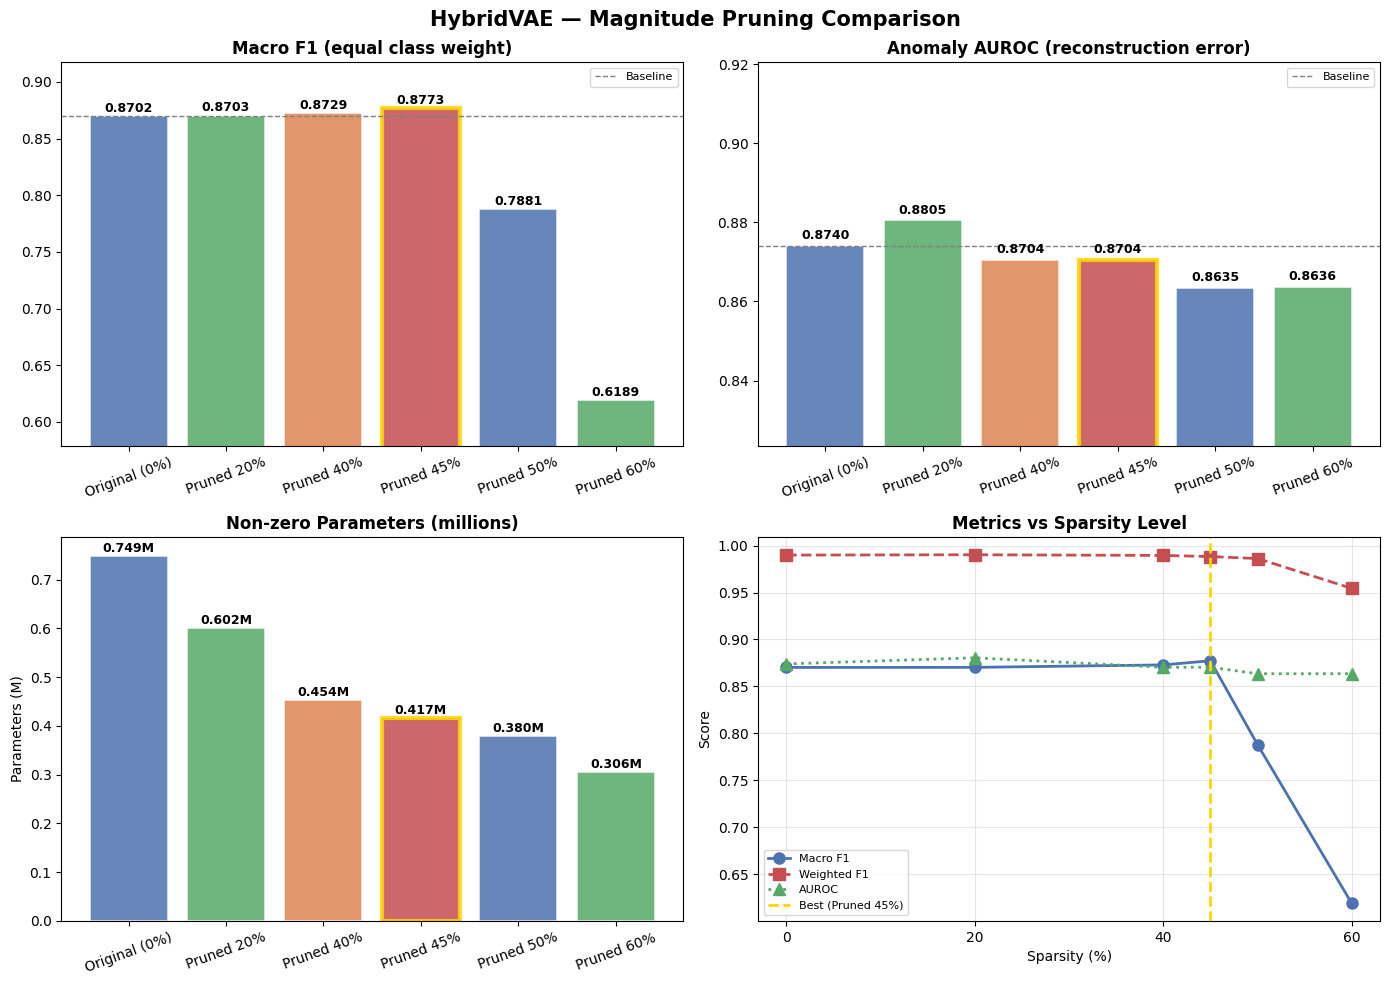


Chart saved -> pruning_comparison.png


In [64]:
# ============================================================
# CELL F2: Pruning Comparison — Summary Table + Multi-Panel Chart
# Requires: pruning_results, best_r, best_model_pruned (from F1)
# ============================================================
from sklearn.metrics import classification_report

# ── Summary table ────────────────────────────────────────────
print('\n' + '=' * 86)
print('  PART F — PRUNING COMPARISON')
print('=' * 86)
print(f"  {'Model':<18} {'Sparsity':>9} {'Non-zero Params':>17}"
      f" {'Macro F1':>10} {'Wt. F1':>8} {'Accuracy':>10} {'AUROC':>8}")
print('  ' + '-' * 82)
for r in pruning_results:
    flag = '  <- best pruned' if r['label'] == best_r['label'] else ''
    print(
        f"  {r['label']:<18}"
        f" {r['sparsity']:>8.0%}"
        f" {r['nonzero']:>17,}"
        f" {r['macro_f1']:>10.4f}"
        f" {r['wt_f1']:>8.4f}"
        f" {r['accuracy']:>10.4f}"
        f" {r['auroc']:>8.4f}"
        f"{flag}"
    )
print('  ' + '-' * 82)
print(f"  Delta (best pruned vs baseline) | "
      f"Macro F1: {best_r['macro_f1']-pruning_results[0]['macro_f1']:+.4f} | "
      f"AUROC: {best_r['auroc']-pruning_results[0]['auroc']:+.4f} | "
      f"Param reduction: {1 - best_r['nonzero']/pruning_results[0]['nonzero']:.1%}")
print('=' * 86)

# ── Per-class report for best pruned model ───────────────────
print(f"\n  Per-class classification report -- {best_r['label']}")
best_preds_f, best_labels_f = _eval_model(best_model_pruned, test_loader_a, DEVICE)
print(classification_report(best_labels_f, best_preds_f,
                             target_names=new_class_names, zero_division=0))

# ── Chart ─────────────────────────────────────────────────────
labels_x   = [r['label']    for r in pruning_results]
macro_vals = [r['macro_f1'] for r in pruning_results]
wf1_vals   = [r['wt_f1']   for r in pruning_results]
auroc_vals = [r['auroc']   for r in pruning_results]
nz_vals    = [r['nonzero'] / 1e6 for r in pruning_results]
sparsities = [r['sparsity'] * 100 for r in pruning_results]

COLORS   = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
best_idx = next(i for i, r in enumerate(pruning_results)
                if r['label'] == best_r['label'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HybridVAE — Magnitude Pruning Comparison',
             fontsize=15, fontweight='bold')

# Panel 1: Macro F1
ax = axes[0, 0]
bars = ax.bar(labels_x, macro_vals, color=COLORS, alpha=0.85,
              edgecolor='white', linewidth=1.2)
bars[best_idx].set_edgecolor('#FFD700'); bars[best_idx].set_linewidth(3)
ax.axhline(macro_vals[0], color='grey', linestyle='--', linewidth=1, label='Baseline')
ax.set_title('Macro F1 (equal class weight)', fontweight='bold')
ax.set_ylim(max(0, min(macro_vals) - 0.04), min(1.0, max(macro_vals) + 0.04))
for bar, v in zip(bars, macro_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)

# Panel 2: Anomaly AUROC
ax = axes[0, 1]
bars = ax.bar(labels_x, auroc_vals, color=COLORS, alpha=0.85,
              edgecolor='white', linewidth=1.2)
bars[best_idx].set_edgecolor('#FFD700'); bars[best_idx].set_linewidth(3)
ax.axhline(auroc_vals[0], color='grey', linestyle='--', linewidth=1, label='Baseline')
ax.set_title('Anomaly AUROC (reconstruction error)', fontweight='bold')
ax.set_ylim(max(0, min(auroc_vals) - 0.04), min(1.0, max(auroc_vals) + 0.04))
for bar, v in zip(bars, auroc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)

# Panel 3: Non-zero parameters
ax = axes[1, 0]
bars = ax.bar(labels_x, nz_vals, color=COLORS, alpha=0.85,
              edgecolor='white', linewidth=1.2)
bars[best_idx].set_edgecolor('#FFD700'); bars[best_idx].set_linewidth(3)
ax.set_title('Non-zero Parameters (millions)', fontweight='bold')
ax.set_ylabel('Parameters (M)')
for bar, v in zip(bars, nz_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.3f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', rotation=20)

# Panel 4: Metric trend across sparsity levels (line plot)
ax = axes[1, 1]
ax.plot(sparsities, macro_vals,  'o-',  color='#4C72B0', lw=2,
        markersize=8, label='Macro F1')
ax.plot(sparsities, wf1_vals,   's--', color='#C44E52', lw=2,
        markersize=8, label='Weighted F1')
ax.plot(sparsities, auroc_vals, '^:',  color='#55A868', lw=2,
        markersize=8, label='AUROC')
ax.axvline(best_r['sparsity']*100, color='#FFD700', linestyle='--',
           linewidth=2, label=f"Best ({best_r['label']})")
ax.set_title('Metrics vs Sparsity Level', fontweight='bold')
ax.set_xlabel('Sparsity (%)')
ax.set_ylabel('Score')
ax.set_xticks([0, 20, 40, 60])
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pruning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nChart saved -> pruning_comparison.png')

---

## Part G — Iterative Magnitude Pruning (Lottery Ticket Hypothesis)

### Why one-shot pruning hits a cliff at ~50%

One-shot pruning removes weights and **leaves the network broken** at that sparsity level. The surviving weights were optimised for a 749K-parameter network — they don't know how to compensate for what was removed. At 50% sparsity, too many critical connections are severed simultaneously for the remaining weights to recover.

### The Lottery Ticket Hypothesis

Frankle & Carlin (2019) showed that inside every large trained network there exists a smaller **winning ticket subnetwork** that, when retrained from scratch (or fine-tuned), matches or exceeds the full network's performance. The key is finding it **iteratively**:

```
One-shot:  Train → Prune 45% → done  (cliff at 50%)

IMP:       Train → Prune 20% → Retrain (20 epochs)
                 → Prune 35% → Retrain
                 → Prune 50% → Retrain
                 → Prune 60% → Retrain
                 → Prune 70% → Retrain
```

Each retrain lets surviving weights **redistribute and compensate** for what was removed, pushing the degradation cliff from ~50% (one-shot) toward 60–70%.

### Implementation: Frozen Masks

After pruning each round, zeroed weights are baked in permanently. During retraining, the zero-mask is re-applied after every optimiser step to prevent those weights from recovering. This enforces the LTH constraint: the winning ticket must win with the subnetwork only.

**Training budget:** 5 rounds × 20 epochs = 100 total fine-tuning epochs (vs 75 for the original).

**Dependencies:** Part A fully run, Part F helpers (`_linear_layers`, `_nonzero_params`, `_eval_model`, `_anomaly_auroc`) must be defined.


### Cell G1 — Iterative Magnitude Pruning with Retraining

Implements the IMP schedule: `[20%, 35%, 50%, 60%, 70%]` cumulative sparsity targets.

**At each round:**
1. Apply global L1 pruning to the cumulative target sparsity (already-zero weights are always re-selected first, so each round removes the weakest *remaining* non-zero weights)
2. Bake the mask permanently
3. Build a frozen mask from the current non-zero pattern
4. Fine-tune for 20 epochs with `lr=3e-4` (lower than original 1e-3 — fine-tuning regime), re-applying the mask after every optimiser step
5. Save the best checkpoint for this round and evaluate on test set

> The learning rate scheduler resets to `3e-4` at the start of each round's retraining phase.


In [71]:
# ============================================================
# CELL G1: Iterative Magnitude Pruning (LTH-inspired)
# Sparsity schedule: 20% -> 35% -> 50% -> 60% -> 70%
# Each level: prune -> retrain 20 epochs -> evaluate -> repeat
# ============================================================
import copy
import torch.nn.utils.prune as prune
from sklearn.metrics import f1_score

# ── Config ───────────────────────────────────────────────────
# Cumulative sparsity targets (each round prunes more of the
# REMAINING weights, not a fresh 20% each time)
SPARSITY_SCHEDULE  = [0.20, 0.35, 0.50, 0.60, 0.70]
RETRAIN_EPOCHS     = 20      # epochs per round (20 x 5 = 100 total)
LR_IMP             = 3e-4    # lower than original 1e-3 — fine-tuning regime
WEIGHT_DECAY_IMP   = 1e-4
GRAD_CLIP          = 1.0

# Binary label for AUROC (re-define in case Part F not in scope)
y_bin_imp = (y_te2 != BENIGN_A).astype('int32')

# ── Start from a clean copy of trained model_a ───────────────
model_imp = copy.deepcopy(model_a).to(DEVICE)

imp_results = []

print('=' * 68)
print('  PART I — Iterative Magnitude Pruning (LTH)')
print(f'  Schedule: {[f"{s:.0%}" for s in SPARSITY_SCHEDULE]}')
print(f'  Retrain epochs per round: {RETRAIN_EPOCHS}')
print('=' * 68)

for round_idx, target_sparsity in enumerate(SPARSITY_SCHEDULE):

    # ── Step 1: Prune to cumulative target ───────────────────
    # Already-zero weights have magnitude 0 → always re-pruned first
    # → effectively prunes the weakest of the REMAINING non-zero weights
    layers = _linear_layers(model_imp)
    prune.global_unstructured(layers,
                              pruning_method=prune.L1Unstructured,
                              amount=target_sparsity)
    for module, param_name in layers:
        prune.remove(module, param_name)    # bake zeros permanently

    tot_i, nz_i = _nonzero_params(model_imp)
    actual_sparsity = 1 - nz_i / tot_i
    print(f'\n  Round {round_idx+1}/{len(SPARSITY_SCHEDULE)} '
          f'| Target: {target_sparsity:.0%} '
          f'| Actual: {actual_sparsity:.1%} '
          f'| Non-zero params: {nz_i:,}')

    # ── Step 2: Build frozen mask (zeroed weights stay zero) ─
    # After each optimizer.step() we re-apply this mask so pruned
    # weights cannot recover — this is the LTH constraint
    frozen_masks = {}
    with torch.no_grad():
        for name, param in model_imp.named_parameters():
            if 'weight' in name and param.dim() > 1:
                frozen_masks[name] = (param.data != 0).to(param.device)

    # ── Step 3: Retrain with frozen pruned weights ────────────
    opt_imp = torch.optim.AdamW(
        model_imp.parameters(), lr=LR_IMP, weight_decay=WEIGHT_DECAY_IMP
    )
    sched_imp = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt_imp, T_max=RETRAIN_EPOCHS, eta_min=1e-6
    )

    best_val_f1_round = -1.0
    best_state_round  = None

    for epoch in range(1, RETRAIN_EPOCHS + 1):
        model_imp.train()
        for X_b, y_b, yb_b in train_loader_a:
            X_b  = X_b.to(DEVICE)
            y_b  = y_b.to(DEVICE)
            yb_b = yb_b.to(DEVICE)

            x_hat, logits, mu, log_var, z = model_imp(X_b)
            loss, _, _, _ = combined_loss_a(
                X_b, x_hat, logits, y_b, mu, log_var, z
            )

            opt_imp.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_imp.parameters(), GRAD_CLIP)
            opt_imp.step()

            # Re-zero pruned weights — LTH constraint
            with torch.no_grad():
                for name, param in model_imp.named_parameters():
                    if name in frozen_masks:
                        param.data.mul_(frozen_masks[name])

        sched_imp.step()

        # Validate every 5 epochs + final epoch
        if epoch % 5 == 0 or epoch == RETRAIN_EPOCHS:
            val_preds_i, val_labels_i = _eval_model(model_imp, val_loader_a, DEVICE)
            val_f1_i = f1_score(val_labels_i, val_preds_i,
                                average='macro', zero_division=0)
            lr_now = sched_imp.get_last_lr()[0]
            marker = ' <- best' if val_f1_i > best_val_f1_round else ''
            print(f'    Ep {epoch:3d}/{RETRAIN_EPOCHS} '
                  f'| Val F1: {val_f1_i:.4f} '
                  f'| LR: {lr_now:.2e}'
                  f'{marker}')
            if val_f1_i > best_val_f1_round:
                best_val_f1_round = val_f1_i
                best_state_round  = copy.deepcopy(model_imp.state_dict())

    # Restore best checkpoint for this round
    model_imp.load_state_dict(best_state_round)

    # ── Step 4: Test evaluation ───────────────────────────────
    test_preds_i, test_labels_i = _eval_model(model_imp, test_loader_a, DEVICE)
    macro_i = f1_score(test_labels_i, test_preds_i, average='macro',    zero_division=0)
    wf1_i   = f1_score(test_labels_i, test_preds_i, average='weighted', zero_division=0)
    auroc_i = _anomaly_auroc(model_imp, X_test_w, y_bin_imp, DEVICE, CONFIG['batch_size'])

    imp_results.append({
        'label':            f'IMP {target_sparsity:.0%}',
        'round':            round_idx + 1,
        'target_sparsity':  target_sparsity,
        'actual_sparsity':  actual_sparsity,
        'nonzero':          nz_i,
        'macro_f1':         macro_i,
        'wt_f1':            wf1_i,
        'auroc':            auroc_i,
    })

    fname = f'./imp_round{round_idx+1}_{int(target_sparsity*100)}pct.pt'
    torch.save(model_imp.state_dict(), fname)
    print(f'  -> Test Macro F1: {macro_i:.4f} | AUROC: {auroc_i:.4f} | Saved: {fname}')

# ── Best IMP model ────────────────────────────────────────────
best_imp = max(imp_results, key=lambda r: r['macro_f1'])
print('\n' + '=' * 68)
print(f"  Best IMP model  : {best_imp['label']}")
print(f"    Macro F1      : {best_imp['macro_f1']:.4f}")
print(f"    AUROC         : {best_imp['auroc']:.4f}")
print(f"    Non-zero      : {best_imp['nonzero']:,} params")
print('=' * 68)

  PART I — Iterative Magnitude Pruning (LTH)
  Schedule: ['20%', '35%', '50%', '60%', '70%']
  Retrain epochs per round: 20

  Round 1/5 | Target: 20% | Actual: 19.7% | Non-zero params: 601,532
    Ep   5/20 | Val F1: 0.8784 | LR: 2.56e-04 <- best
    Ep  10/20 | Val F1: 0.8775 | LR: 1.50e-04
    Ep  15/20 | Val F1: 0.8955 | LR: 4.48e-05 <- best
    Ep  20/20 | Val F1: 0.8968 | LR: 1.00e-06 <- best
  -> Test Macro F1: 0.8703 | AUROC: 0.8714 | Saved: ./imp_round1_20pct.pt

  Round 2/5 | Target: 35% | Actual: 34.5% | Non-zero params: 490,729
    Ep   5/20 | Val F1: 0.8845 | LR: 2.56e-04 <- best
    Ep  10/20 | Val F1: 0.8597 | LR: 1.50e-04
    Ep  15/20 | Val F1: 0.8915 | LR: 4.48e-05 <- best
    Ep  20/20 | Val F1: 0.8891 | LR: 1.00e-06
  -> Test Macro F1: 0.8663 | AUROC: 0.8692 | Saved: ./imp_round2_35pct.pt

  Round 3/5 | Target: 50% | Actual: 49.3% | Non-zero params: 379,926
    Ep   5/20 | Val F1: 0.8413 | LR: 2.56e-04 <- best
    Ep  10/20 | Val F1: 0.8567 | LR: 1.50e-04 <- best
  

### Cell G2 — IMP vs One-Shot: Comparison Table and Chart

Compares IMP results against the one-shot baseline (hard-coded from Part F output).

**Two-panel chart:**
- **Left:** Macro F1 vs sparsity — shows where IMP overcomes the one-shot cliff
- **Right:** Anomaly AUROC vs sparsity — confirms anomaly detection is preserved under IMP

Both panels mark the one-shot cliff at 50% and the best IMP checkpoint.

Also prints the per-class classification report for the best IMP model (reloaded from disk to ensure the correct checkpoint).



  PART I — IMP vs ONE-SHOT PRUNING COMPARISON
  Method                Sparsity     Non-zero   Macro F1    AUROC
  --------------------------------------------------------------
  -- One-Shot (no retraining) --
  One-shot  0%               0%      749,270     0.8702   0.8740
  One-shot 20%              20%      601,532     0.8703   0.8805
  One-shot 40%              40%      453,795     0.8729   0.8704
  One-shot 45%              45%      416,860     0.8773   0.8704  <- best
  One-shot 50%              50%      379,926     0.7881   0.8635  <- cliff
  One-shot 60%              60%      306,057     0.6189   0.8636
  -- IMP (with retraining) --
  IMP 20%                 19.7%      601,532     0.8703   0.8714
  IMP 35%                 34.5%      490,729     0.8663   0.8692
  IMP 50%                 49.3%      379,926     0.8864   0.8645
  IMP 60%                 59.2%      306,057     0.8992   0.8710  <- best IMP
  IMP 70%                 69.0%      232,188     0.8844   0.8600
  ----------

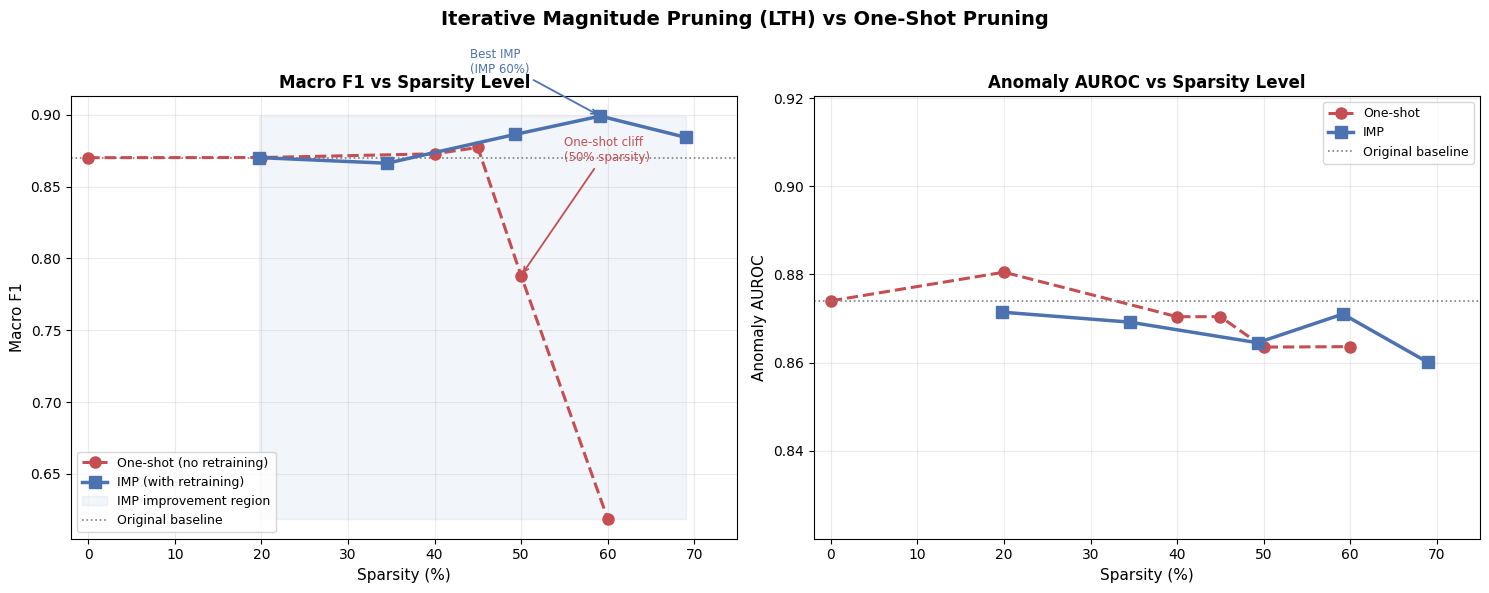


Chart saved -> imp_vs_oneshot.png


In [72]:
# ============================================================
# CELL G2: IMP vs One-Shot Pruning — comparison table + chart
# One-shot results hard-coded from Part F output.
# ============================================================
from sklearn.metrics import classification_report

# ── One-shot results from Part F (your actual values) ────────
one_shot = [
    {'label': 'One-shot  0%',  'sparsity': 0.00, 'macro_f1': 0.8702, 'auroc': 0.8740, 'nonzero': 749270},
    {'label': 'One-shot 20%',  'sparsity': 0.20, 'macro_f1': 0.8703, 'auroc': 0.8805, 'nonzero': 601532},
    {'label': 'One-shot 40%',  'sparsity': 0.40, 'macro_f1': 0.8729, 'auroc': 0.8704, 'nonzero': 453795},
    {'label': 'One-shot 45%',  'sparsity': 0.45, 'macro_f1': 0.8773, 'auroc': 0.8704, 'nonzero': 416860},
    {'label': 'One-shot 50%',  'sparsity': 0.50, 'macro_f1': 0.7881, 'auroc': 0.8635, 'nonzero': 379926},
    {'label': 'One-shot 60%',  'sparsity': 0.60, 'macro_f1': 0.6189, 'auroc': 0.8636, 'nonzero': 306057},
]

# ── Combined table ────────────────────────────────────────────
print('\n' + '=' * 82)
print('  PART I — IMP vs ONE-SHOT PRUNING COMPARISON')
print('=' * 82)
print(f"  {'Method':<20} {'Sparsity':>9} {'Non-zero':>12} {'Macro F1':>10} {'AUROC':>8}")
print('  ' + '-' * 62)

print('  -- One-Shot (no retraining) --')
for r in one_shot:
    cliff = '  <- cliff' if r['sparsity'] == 0.50 else ''
    best  = '  <- best' if r['sparsity'] == 0.45 else ''
    print(f"  {r['label']:<20} {r['sparsity']:>8.0%} {r['nonzero']:>12,}"
          f" {r['macro_f1']:>10.4f} {r['auroc']:>8.4f}{cliff}{best}")

print('  -- IMP (with retraining) --')
for r in imp_results:
    best = '  <- best IMP' if r['label'] == best_imp['label'] else ''
    print(f"  {r['label']:<20} {r['actual_sparsity']:>8.1%} {r['nonzero']:>12,}"
          f" {r['macro_f1']:>10.4f} {r['auroc']:>8.4f}{best}")
print('  ' + '-' * 62)

# Delta: best IMP vs best one-shot
best_oneshot_f1 = max(r['macro_f1'] for r in one_shot)
print(f"\n  Best one-shot Macro F1 : {best_oneshot_f1:.4f}  (45% sparsity)")
print(f"  Best IMP Macro F1      : {best_imp['macro_f1']:.4f}  ({best_imp['label']})")
print(f"  Improvement            : {best_imp['macro_f1'] - best_oneshot_f1:+.4f}")
print('=' * 82)

# ── Per-class report for best IMP model ──────────────────────
# Reload best IMP model for final report
model_imp.load_state_dict(
    torch.load(f"./imp_round{best_imp['round']}_{int(best_imp['target_sparsity']*100)}pct.pt",
               map_location=DEVICE)
)
final_preds, final_labels = _eval_model(model_imp, test_loader_a, DEVICE)
print(f"\n  Per-class report — {best_imp['label']}")
print(classification_report(final_labels, final_preds,
                             target_names=new_class_names, zero_division=0))

# ── Chart ─────────────────────────────────────────────────────
sp_os  = [r['sparsity']  * 100 for r in one_shot]
f1_os  = [r['macro_f1']        for r in one_shot]
au_os  = [r['auroc']           for r in one_shot]

sp_imp = [r['actual_sparsity'] * 100 for r in imp_results]
f1_imp = [r['macro_f1']             for r in imp_results]
au_imp = [r['auroc']                for r in imp_results]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Iterative Magnitude Pruning (LTH) vs One-Shot Pruning',
             fontsize=14, fontweight='bold')

# Panel 1: Macro F1 vs Sparsity
ax = axes[0]
ax.plot(sp_os,  f1_os,  'o--', color='#C44E52', lw=2.2, markersize=8,
        label='One-shot (no retraining)', zorder=3)
ax.plot(sp_imp, f1_imp, 's-',  color='#4C72B0', lw=2.5, markersize=9,
        label='IMP (with retraining)', zorder=4)

# Shade the region where IMP beats one-shot
ax.fill_between(
    [min(sp_imp), max(sp_imp)],
    [min(f1_os)]*2, [max(f1_imp)]*2,
    alpha=0.07, color='#4C72B0', label='IMP improvement region'
)

# Mark one-shot cliff
cliff_x = 50
cliff_y = 0.7881
ax.annotate('One-shot cliff\n(50% sparsity)',
            xy=(cliff_x, cliff_y), xytext=(cliff_x + 5, cliff_y + 0.08),
            fontsize=8.5, color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.3))

# Mark best IMP
ax.annotate(f"Best IMP\n({best_imp['label']})",
            xy=(best_imp['actual_sparsity']*100, best_imp['macro_f1']),
            xytext=(best_imp['actual_sparsity']*100 - 15, best_imp['macro_f1'] + 0.03),
            fontsize=8.5, color='#4C72B0',
            arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.3))

ax.axhline(0.8702, color='grey', linestyle=':', lw=1.2, label='Original baseline')
ax.set_xlabel('Sparsity (%)', fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Macro F1 vs Sparsity Level', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-2, 75)

# Panel 2: AUROC vs Sparsity
ax = axes[1]
ax.plot(sp_os,  au_os,  'o--', color='#C44E52', lw=2.2, markersize=8,
        label='One-shot')
ax.plot(sp_imp, au_imp, 's-',  color='#4C72B0', lw=2.5, markersize=9,
        label='IMP')
ax.axhline(0.8740, color='grey', linestyle=':', lw=1.2, label='Original baseline')
ax.set_xlabel('Sparsity (%)', fontsize=11)
ax.set_ylabel('Anomaly AUROC', fontsize=11)
ax.set_title('Anomaly AUROC vs Sparsity Level', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-2, 75)
ax.set_ylim(max(0, min(au_os+au_imp) - 0.04),
            min(1.0, max(au_os+au_imp) + 0.04))

plt.tight_layout()
plt.savefig('imp_vs_oneshot.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nChart saved -> imp_vs_oneshot.png')


In [86]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


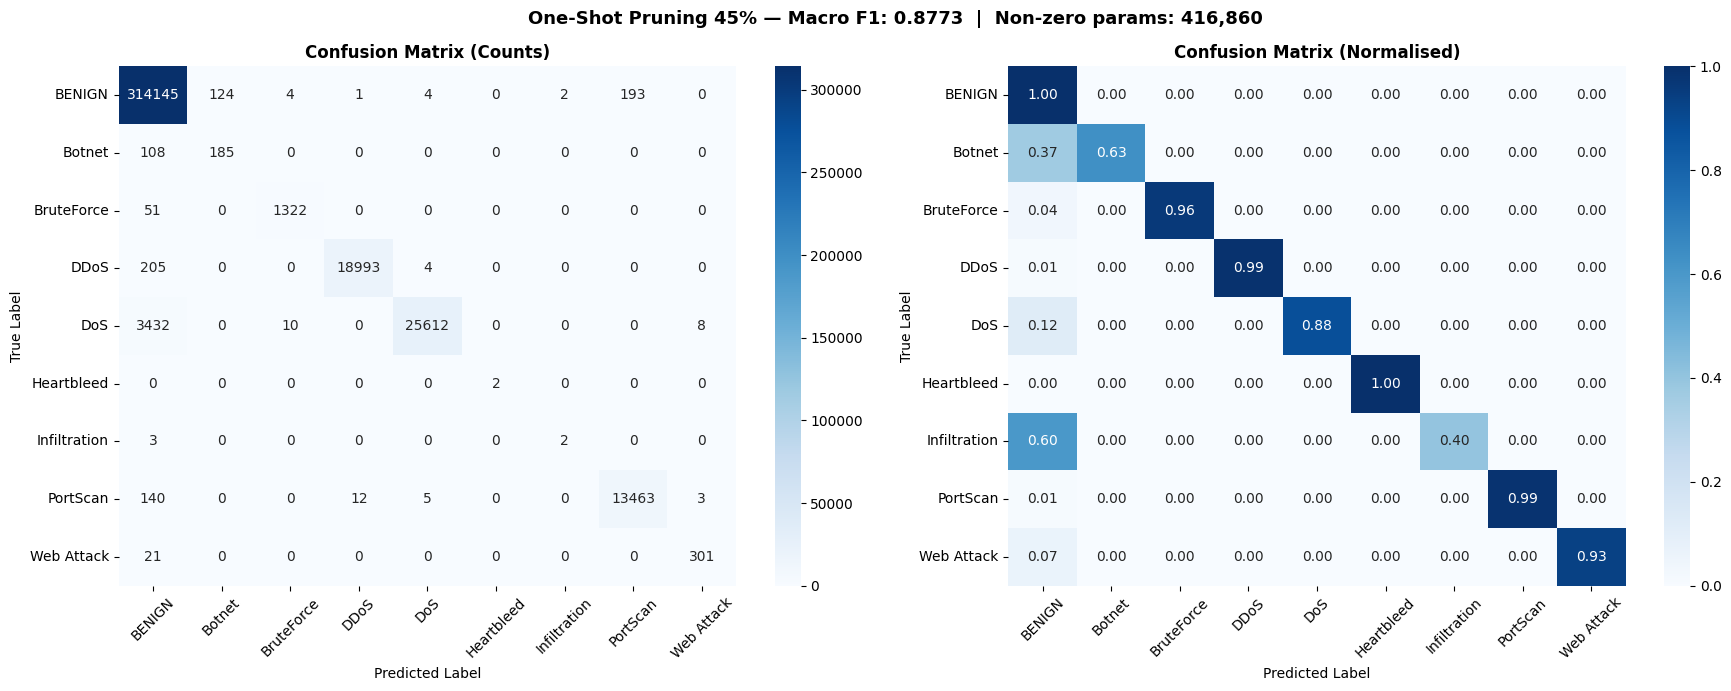

Saved -> confusion_oneshot_45pct.png
One-Shot 45% Macro F1: 0.8773


In [89]:
# ============================================================
# Confusion Matrix — One-Shot Pruning Best Model (45% sparse)
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

# ── Get predictions ───────────────────────────────────────────
best_model_pruned = best_model_pruned.to(DEVICE)
best_model_pruned.eval()
preds_os, labels_os = [], []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, logits, _, _, _ = best_model_pruned(X_b.to(DEVICE))
        preds_os.extend(logits.argmax(1).cpu().numpy())
        labels_os.extend(y_b.numpy())

preds_os  = np.array(preds_os)
labels_os = np.array(labels_os)

macro_os = f1_score(labels_os, preds_os, average='macro', zero_division=0)

# ── Confusion matrices ────────────────────────────────────────
cm_os      = confusion_matrix(labels_os, preds_os)
cm_os_norm = cm_os.astype(float) / cm_os.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'One-Shot Pruning 45% — Macro F1: {macro_os:.4f}  |  Non-zero params: 416,860',
             fontsize=13, fontweight='bold')

sns.heatmap(cm_os, annot=True, fmt='d', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_os_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_oneshot_45pct.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> confusion_oneshot_45pct.png')
print(f'One-Shot 45% Macro F1: {macro_os:.4f}')


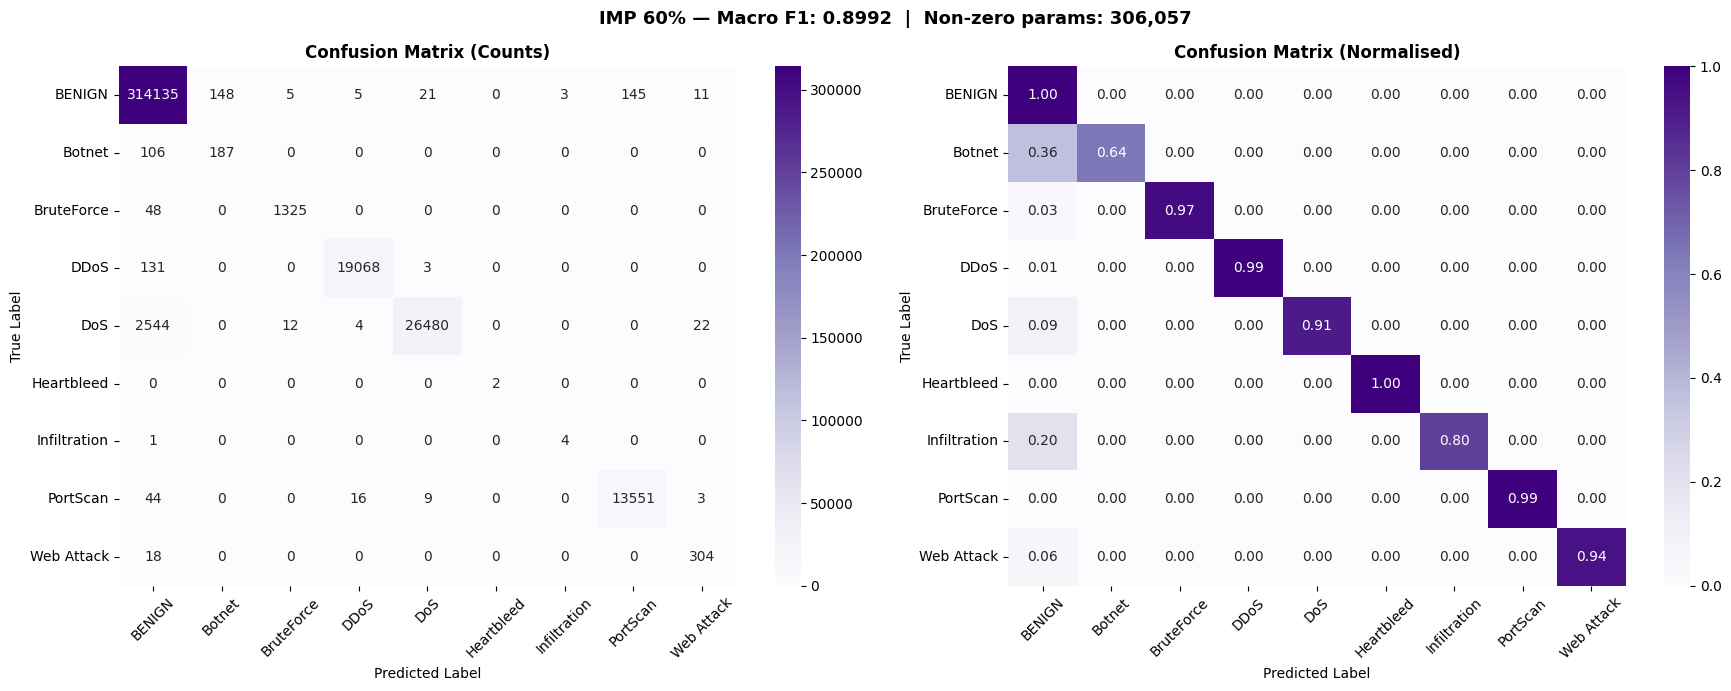

Saved -> confusion_imp_60pct.png
IMP 60% Macro F1: 0.8992


In [90]:
# ============================================================
# Confusion Matrix — IMP Best Model (60% sparse)
# ============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score
import copy

# ── Reload best IMP checkpoint to be safe ────────────────────
model_imp_eval = copy.deepcopy(model_imp)
model_imp_eval.load_state_dict(
    torch.load(
        f"./imp_round{best_imp['round']}_{int(best_imp['target_sparsity']*100)}pct.pt",
        map_location=DEVICE
    )
)
model_imp_eval.eval()

# ── Get predictions ───────────────────────────────────────────
preds_imp, labels_imp = [], []
with torch.no_grad():
    for X_b, y_b, _ in test_loader_a:
        _, logits, _, _, _ = model_imp_eval(X_b.to(DEVICE))
        preds_imp.extend(logits.argmax(1).cpu().numpy())
        labels_imp.extend(y_b.numpy())

preds_imp  = np.array(preds_imp)
labels_imp = np.array(labels_imp)

macro_imp_cm = f1_score(labels_imp, preds_imp, average='macro', zero_division=0)

# ── Confusion matrices ────────────────────────────────────────
cm_imp      = confusion_matrix(labels_imp, preds_imp)
cm_imp_norm = cm_imp.astype(float) / cm_imp.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"IMP 60% — Macro F1: {macro_imp_cm:.4f}  |  Non-zero params: 306,057",
             fontsize=13, fontweight='bold')

sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Purples',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_imp_norm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=new_class_names, yticklabels=new_class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_imp_60pct.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> confusion_imp_60pct.png')
print(f'IMP 60% Macro F1: {macro_imp_cm:.4f}')


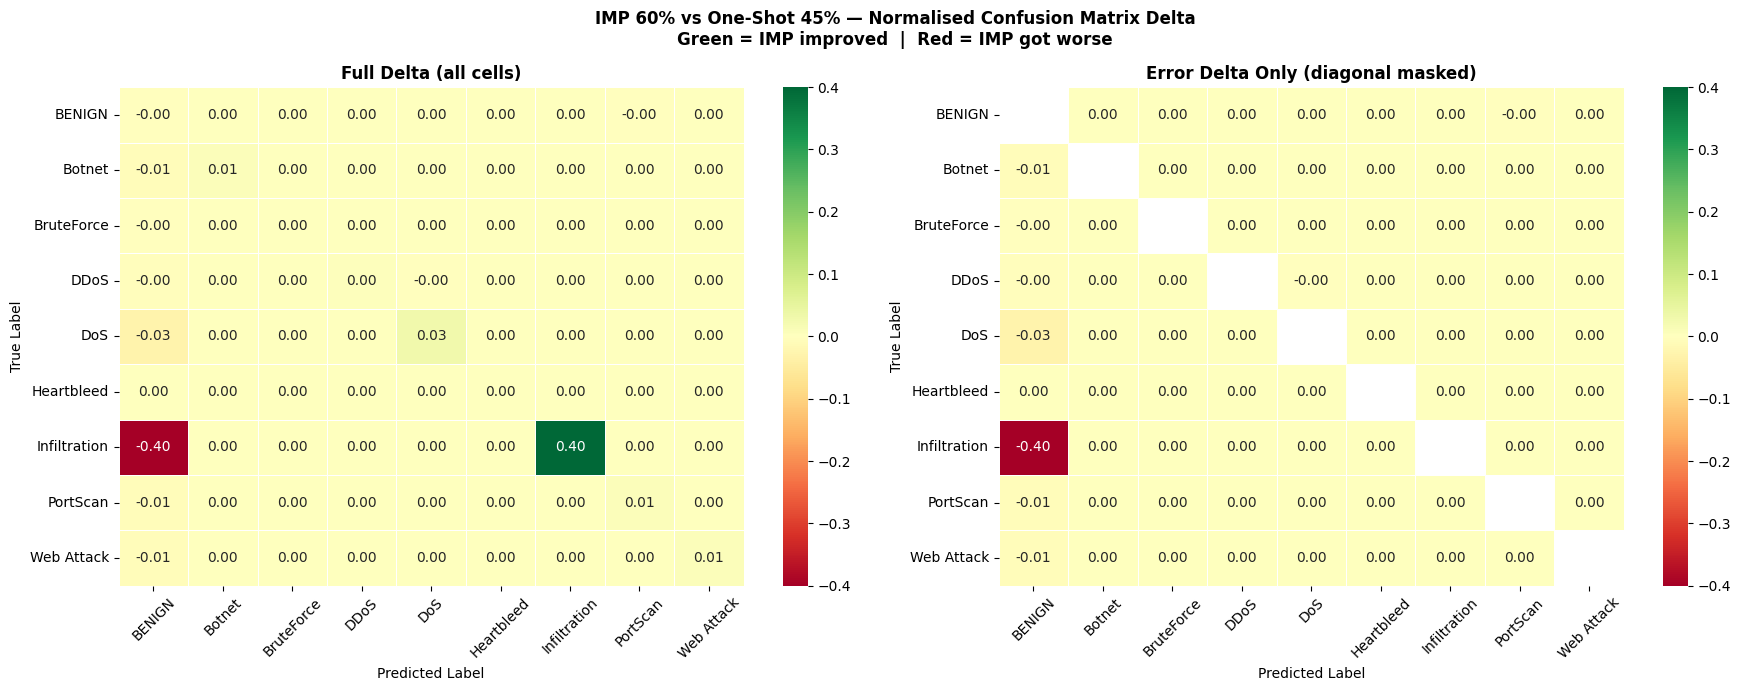

Saved -> confusion_delta_imp_vs_oneshot.png

  Biggest improvements (IMP vs One-Shot, off-diagonal):
    BETTER: True=DoS            Pred=BENIGN         delta=-0.031
    BETTER: True=Infiltration   Pred=BENIGN         delta=-0.400


In [91]:
# ============================================================
# Confusion Matrix Delta: IMP 60% minus One-Shot 45% (normalised)
# Green = IMP better, Red = IMP worse
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

delta = cm_imp_norm - cm_os_norm   # positive = IMP predicted more here

# Mask diagonal for cleaner readout
# (diagonal = correct class — we care most about off-diagonal errors)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('IMP 60% vs One-Shot 45% — Normalised Confusion Matrix Delta\n'
             'Green = IMP improved  |  Red = IMP got worse',
             fontsize=12, fontweight='bold')

# Full delta (including diagonal)
vmax = np.abs(delta).max()
sns.heatmap(delta, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-vmax, vmax=vmax,
            xticklabels=new_class_names, yticklabels=new_class_names,
            ax=axes[0], linewidths=0.4)
axes[0].set_title('Full Delta (all cells)', fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Off-diagonal only (errors) — mask diagonal
delta_offdiag = delta.copy()
np.fill_diagonal(delta_offdiag, np.nan)
vmax_od = np.nanmax(np.abs(delta_offdiag))
sns.heatmap(delta_offdiag, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-vmax_od, vmax=vmax_od,
            xticklabels=new_class_names, yticklabels=new_class_names,
            ax=axes[1], linewidths=0.4,
            mask=np.eye(len(new_class_names), dtype=bool))
axes[1].set_title('Error Delta Only (diagonal masked)', fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_delta_imp_vs_oneshot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> confusion_delta_imp_vs_oneshot.png')

# ── Text summary of biggest changes ──────────────────────────
print('\n  Biggest improvements (IMP vs One-Shot, off-diagonal):')
for i in range(len(new_class_names)):
    for j in range(len(new_class_names)):
        if i != j and abs(delta_offdiag[i, j]) > 0.02:
            direction = 'BETTER' if delta_offdiag[i, j] < 0 else 'WORSE'
            print(f'    {direction}: True={new_class_names[i]:<14} '
                  f'Pred={new_class_names[j]:<14} '
                  f'delta={delta_offdiag[i,j]:+.3f}')
